In [3]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from functools import reduce
import re

Data Source: https://data.unicef.org/topic/nutrition/womens-nutrition/

##Overweight Data

###Opening and pivoting dataset

In [4]:
overweight_df = pd.read_excel(r"/content/UNICEF_Global-database_Womens-Nutrition_August-2025_2.xlsx", sheet_name="overweight", skiprows=6, header=[0,1])

In [5]:
import re
import pandas as pd

def rebuild_headers(df):
    df = df.copy()

    new_columns = []
    current_year = None

    for column in df.columns:

        # MultiIndex columns are tuples; ordinary columns are strings
        parts = column if isinstance(column, tuple) else (column,)

        parts = [
            re.sub(
                r"\s+",
                " ",
                str(part).replace("\xa0", " ").strip()
            )
            for part in parts
            if pd.notna(part)
            and not str(part).startswith("Unnamed:")
        ]

        combined_header = " ".join(parts)

        # Find a four-digit year anywhere in either header level
        year_match = re.search(
            r"\b((?:19|20)\d{2})\b",
            combined_header
        )

        if year_match:
            current_year = year_match.group(1)

        # Find the measure regardless of its position
        measure_match = re.search(
            r"(Point Estimate|Lower Limit|Upper Limit)",
            combined_header,
            flags=re.IGNORECASE
        )

        if measure_match:
            measure_lookup = {
                "point estimate": "Point Estimate",
                "lower limit": "Lower Limit",
                "upper limit": "Upper Limit"
            }

            measure = measure_lookup[
                measure_match.group(1).lower()
            ]

            if current_year is None:
                raise ValueError(
                    f"No year could be identified for header: {column}"
                )

            new_columns.append(f"{current_year}_{measure}")

        else:
            # Retain identifying columns such as Country and Region
            new_columns.append("_".join(parts))

    df.columns = new_columns

    return df

def pivot_table(df):
  df = rebuild_headers(df)

  df = df[1:]
  id_cols = ["Countries and areas", "UNICEF Regions", "UN Regions", "World Bank Income Groups"]
  df = (
      df.melt(
          id_vars=id_cols,
          var_name="year_measure",
          value_name="value"
      )
      .assign(
          year=lambda x: x["year_measure"].str.extract(r"^(\d{4})")[0].astype(float),
          measure=lambda x: x["year_measure"].str.extract(
              r"^\d{4}_(Point Estimate|Lower Limit|Upper Limit)$"
          )[0]
      )
      .dropna(subset=["measure"])
      .pivot(
          index=id_cols + ["year"],
          columns="measure",
          values="value"
      )
      .reset_index()
      .rename_axis(columns=None)
  )
  df.year = df.year.astype(int)
  df['Point Estimate'] = df['Point Estimate'].astype(float)
  df['Lower Limit'] = df['Lower Limit'].astype(float)
  df['Upper Limit'] = df['Upper Limit'].astype(float)
  df = df.rename(columns={"Countries and areas":"Country"})
  return df


In [6]:
pd.set_option('display.max_columns', None)
overweight_df.head()

Unnamed: 0_level_0                ISO Countries and areas  \
  Unnamed: 0_level_1 Unnamed: 1_level_1  Unnamed: 2_level_1   
0   UNICEF_Survey_ID           ISO3Code         CountryName   
1                NaN                AFG         Afghanistan   
2                NaN                ALB             Albania   
3                NaN                DZA             Algeria   
4                NaN                AND             Andorra   

                UNICEF Regions         UN Regions World Bank Income Groups  \
            Unnamed: 3_level_1 Unnamed: 4_level_1       Unnamed: 5_level_1   
0  UNICEF_Reporting_Sub_Region           UNRegion                WB_Latest   
1                           SA               Asia               Low Income   
2                         EECA             Europe      Upper Middle Income   
3                         MENA             Africa      Upper Middle Income   
4                           WE             Europe              High Income   

            2000                                     2001              \
  Point Estimate  Lower Limit  Upper Limit Point Estimate Lower Limit   
0     National_r  National_ll  National_ul         male_r     male_ll   
1           15.2         11.2         19.8           16.2        12.2   
2           48.4         44.1         52.6             49          45   
3           47.5         43.2         51.9           48.3        44.3   
4           41.8         36.9         46.7             42        37.3   

                        2002                                   2003  \
  Upper Limit Point Estimate Lower Limit Upper Limit Point Estimate   
0     male_ul       female_r   female_ll   female_ul        urban_r   
1        20.7           17.3        13.3        21.8           18.4   
2        53.1           49.8        45.9        53.6           50.5   
3        52.4           49.1        45.2          53           49.9   
4        46.9             42        37.3        46.8             42   

                    Rural           2004 Wealth Quintile 1              \
  Lower Limit Upper Limit Point Estimate       Lower Limit Upper Limit   
0    urban_ll    urban_ul        rural_r          rural_ll    rural_ul   
1        14.5        22.9           19.6              15.7          24   
2        46.8        54.2           51.3              47.8        54.7   
3        46.2        53.6           50.6              47.1        54.2   
4        37.3        46.7           41.9              37.4        46.6   

            2005                                       2006                 \
  Point Estimate   Lower Limit   Upper Limit Point Estimate    Lower Limit   
0    month_0_5_r  month_0_5_ll  month_0_5_ul   month_6_11_r  month_6_11_ll   
1           20.8            17          25.1           22.1           18.3   
2             52          48.6          55.3           52.8           49.5   
3           51.4          48.1          54.8           52.2           48.9   
4             42          37.4          46.6           42.1           37.4   

                           2007                 Wealth Quintile 5  \
     Upper Limit Point Estimate     Lower Limit       Upper Limit   
0  month_6_11_ul  month_12_23_r  month_12_23_ll    month_12_23_ul   
1           26.2           23.5            19.7              27.5   
2           55.9           53.5            50.4              56.5   
3           55.4             53            49.8              56.1   
4           46.9           42.2            37.4              47.2   

            2008     Bottom 60%                          2009                  \
  Point Estimate    Lower Limit    Upper Limit Point Estimate     Lower Limit   
0   month_0_23_r  month_0_23_ll  month_0_23_ul  month_24_35_r  month_24_35_ll   
1           24.9           21.2           28.7           26.3            22.8   
2           54.3           51.3           57.2           55.1            52.2   
3           53.7           50.7           56.8  

In [7]:
long_overweight_df = pivot_table(overweight_df)

In [8]:
print(long_overweight_df.shape)
long_overweight_df.head()

(4462, 8)


,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
0,Afghanistan,SA,Asia,Low Income,2000,11.2,15.2,19.8
1,Afghanistan,SA,Asia,Low Income,2001,12.2,16.2,20.7
2,Afghanistan,SA,Asia,Low Income,2002,13.3,17.3,21.8
3,Afghanistan,SA,Asia,Low Income,2003,14.5,18.4,22.9
4,Afghanistan,SA,Asia,Low Income,2004,15.7,19.6,24.0


In [9]:
long_overweight_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   4462 non-null   object 
 1   UNICEF Regions            4416 non-null   object 
 2   UN Regions                4462 non-null   object 
 3   World Bank Income Groups  4462 non-null   object 
 4   year                      4462 non-null   int64  
 5   Lower Limit               4462 non-null   float64
 6   Point Estimate            4462 non-null   float64
 7   Upper Limit               4462 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 279.0+ KB


In [10]:
long_overweight_df.Country.nunique()

194

In [11]:
long_overweight_df['UNICEF Regions'].unique()

array(['SA', 'EECA', 'MENA', 'WE', 'ESA', 'LAC', 'EAP', 'WCA', nan],
      dtype=object)

In [12]:
long_overweight_df['UN Regions'].unique()

array(['Asia', 'Europe', 'Africa', 'Latin America and the Caribbean',
       'Oceania', 'Northern America'], dtype=object)

In [13]:
subsahran_africa_countries = long_overweight_df[long_overweight_df['UNICEF Regions'].isin(["WCA","ESA"])][["Country"]].drop_duplicates(keep='first')
print(subsahran_africa_countries)
subsahran_africa_countries.to_csv("subsahran_africa_countries.csv")

                               Country
92                              Angola
414                              Benin
506                           Botswana
598                       Burkina Faso
621                            Burundi
644                         Cabo Verde
690                           Cameroon
736           Central African Republic
759                               Chad
851                            Comoros
874                              Congo
1035                     Côte d'Ivoire
1081  Democratic Republic of the Congo
1127                          Djibouti
1265                 Equatorial Guinea
1288                           Eritrea
1334                          Eswatini
1357                          Ethiopia
1449                             Gabon
1472                            Gambia
1541                             Ghana
1633                            Guinea
1656                     Guinea-Bissau
2047                             Kenya
2208                     

Note some values are missing from the upper and lower limit percentage estimate

###Exploration

In [14]:
most_recent_year = long_overweight_df.year.max()

In [15]:
#highest current Overweight percentage
long_overweight_df[long_overweight_df.year == most_recent_year].sort_values(by="Point Estimate", ascending=False).head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
4024,Tonga,EAP,Oceania,Upper Middle Income,2022,90.8,93.4,95.5
3403,Samoa,EAP,Oceania,Lower Middle Income,2022,87.7,91.7,94.8
4001,Tokelau,EAP,Oceania,Not Classified,2022,86.0,91.3,95.2
919,Cook Islands,EAP,Oceania,Not Classified,2022,85.6,90.3,94.2
2897,Niue,EAP,Oceania,Not Classified,2022,83.6,89.3,93.7
4116,Tuvalu,EAP,Oceania,Upper Middle Income,2022,84.0,88.4,92.3
2736,Nauru,EAP,Oceania,High Income,2022,83.7,88.2,92.0
2092,Kiribati,EAP,Oceania,Lower Middle Income,2022,78.3,83.4,88.0
3334,Saint Kitts and Nevis,LAC,Latin America and the Caribbean,High Income,2022,74.2,82.8,90.2
275,Bahamas,LAC,Latin America and the Caribbean,High Income,2022,77.8,81.8,85.4


In [16]:
#lowest current Overweight percentage
long_overweight_df[long_overweight_df.year == most_recent_year].sort_values(by="Point Estimate").head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
643,Burundi,ESA,Africa,Low Income,2022,8.9,11.7,14.8
1379,Ethiopia,ESA,Africa,Low Income,2022,11.1,13.7,16.6
3955,Timor-Leste,EAP,Asia,Lower Middle Income,2022,12.7,16.1,20.0
2345,Madagascar,ESA,Africa,Low Income,2022,13.6,16.3,19.2
781,Chad,WCA,Africa,Low Income,2022,14.1,18.3,23.0
1310,Eritrea,ESA,Africa,Low Income,2022,12.9,18.4,24.9
4392,Viet Nam,EAP,Asia,Lower Middle Income,2022,16.2,18.7,21.4
2000,Japan,EAP,Asia,High Income,2022,17.4,19.7,22.1
2851,Niger,WCA,Africa,Low Income,2022,17.9,20.7,23.9
620,Burkina Faso,WCA,Africa,Low Income,2022,22.6,25.1,27.8


####Improving Countries

In [17]:
#countries that have shown the most improvement (lowering of overweight women population percentage) and years the improvement took place
def most_improved(df):
    df = (
        df
        .dropna(subset=["Country", "year", "Point Estimate"])
        .sort_values(["Country", "year"])
        .reset_index(drop=True)
    )

    # Highest estimate observed up to each year
    df["Previous Peak"] = (
        df.groupby("Country")["Point Estimate"].cummax()
    )

    # Year associated with that peak
    df["Peak Year"] = (
        df["year"]
        .where(df["Point Estimate"].eq(df["Previous Peak"]))
        .groupby(df["Country"])
        .ffill()
    )

    # Improvement from the earlier peak
    df["Estimate Decrease"] = (
        df["Previous Peak"] - df["Point Estimate"]
    )

    df["Percent Decrease"] = (
        df["Estimate Decrease"]
        .div(df["Previous Peak"])
        .mul(100)
    )

    # Keep each country's largest decrease
    largest_improvements = (
        df.loc[
            df.groupby("Country")["Estimate Decrease"].idxmax()
        ]
        .rename(columns={
            "Previous Peak": "Estimate High",
            "Point Estimate": "Estimate Low",
            "year": "Low Year"
        })
        .sort_values("Estimate Decrease", ascending=False)
        .reset_index(drop=True)
    )

    largest_improvements = largest_improvements[
        [
            "Country",
            "Peak Year",
            "Low Year",
            "Estimate High",
            "Estimate Low",
            "Estimate Decrease",
            "Percent Decrease"
        ]
    ]
    return largest_improvements

In [18]:
overweight_improved = most_improved(long_overweight_df)
overweight_improved.head(10)

,Country,Peak Year,Low Year,Estimate High,Estimate Low,Estimate Decrease,Percent Decrease
0,France,2003.0,2022,39.8,32.5,7.3,18.341709
1,Spain,2005.0,2022,52.9,48.2,4.7,8.884688
2,United Arab Emirates,2005.0,2009,62.1,58.7,3.4,5.475040
3,Switzerland,2001.0,2022,35.4,32.9,2.5,7.062147
4,Republic of Moldova,2021.0,2022,62.0,60.5,1.5,2.419355
5,Nauru,2000.0,2009,89.4,88.1,1.3,1.454139
6,Netherlands (Kingdom of the),2010.0,2022,47.0,45.7,1.3,2.765957
7,Malta,2011.0,2021,63.0,61.7,1.3,2.063492
8,Israel,2010.0,2022,51.9,50.6,1.3,2.504817
9,Austria,2005.0,2018,40.1,38.9,1.2,2.992519


#### Stagnating or Worsening Countries

In [19]:
def least_improved(df):
  meaningful_change = 0.5

  country_change = (
      df
      .sort_values(["Country", "year"])
      .groupby("Country", as_index=False)
      .agg(
          Start_Year=("year", "first"),
          End_Year=("year", "last"),
          Starting_Estimate=("Point Estimate", "first"),
          Ending_Estimate=("Point Estimate", "last")
      ).rename(columns={
          "Start_Year": "Starting Year",
          "End_Year": "Ending Year",
          "Starting_Estimate": "Starting Estimate",
          "Ending_Estimate": "Ending Estimate"
      })
  )

  # Positive values indicate worsening
  country_change["Percentage Point Change"] = (
      country_change["Ending Estimate"]
      - country_change["Starting Estimate"]
  )

  # Data-relative definition of poor initial performance
  poor_performance_cutoff = (
      country_change["Starting Estimate"].quantile(0.75)
  )

  country_change["Initially High"] = (
      country_change["Starting Estimate"]
      >= poor_performance_cutoff
  )

  country_change["Condition"] = np.select(
      [
          country_change["Percentage Point Change"] > meaningful_change,

          (
              country_change["Initially High"] & (country_change["Percentage Point Change"] >= -meaningful_change)
          )
      ],
      [
          "Worsened",
          "High starting level; failed to improve"
      ],
      default="Not flagged"
  )

  countries_of_concern = (
    country_change
    .assign(
        Condition_Order=lambda x:
            x["Condition"].map({
                "Worsened": 2,
                "High starting level; failed to improve": 1,
                "Not flagged": 0
            })
    ).rename(columns={"Condition_Order": "Condition Order"})
    .sort_values(
        [
            "Condition Order",
            "Percentage Point Change",
            "Ending Estimate"
        ],
        ascending=[False, False, False]
    )
    #.drop(columns="Condition_Order")
    .reset_index(drop=True)
  )
  countries_of_concern['Percentile'] = countries_of_concern["Ending Estimate"].rank(pct=True)
  countries_of_concern["Score"] = countries_of_concern["Condition Order"] + countries_of_concern["Percentile"]
  return countries_of_concern

In [20]:
overweight_not_improved = least_improved(long_overweight_df)
display(overweight_not_improved.head(10))
display(overweight_not_improved[overweight_not_improved['Initially High'] == True].head(15))

,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
0,Afghanistan,2000,2022,15.2,49.4,34.2,False,Worsened,2,0.337629,2.337629
1,Brunei Darussalam,2000,2022,39.5,71.1,31.6,False,Worsened,2,0.814433,2.814433
2,Maldives,2000,2022,28.9,60.4,31.5,False,Worsened,2,0.536082,2.536082
3,Bhutan,2000,2022,22.3,52.8,30.5,False,Worsened,2,0.414948,2.414948
4,Indonesia,2000,2022,19.3,48.6,29.3,False,Worsened,2,0.329897,2.329897
5,Pakistan,2000,2022,25.7,54.4,28.7,False,Worsened,2,0.438144,2.438144
6,Uzbekistan,2000,2022,35.2,63.3,28.1,False,Worsened,2,0.618557,2.618557
7,Bangladesh,2000,2022,6.4,33.7,27.3,False,Worsened,2,0.154639,2.154639
8,Sri Lanka,2000,2022,19.3,46.3,27.0,False,Worsened,2,0.309278,2.309278
9,Cabo Verde,2000,2022,27.8,54.5,26.7,False,Worsened,2,0.443299,2.443299


,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
24,Chile,2000,2022,57.5,80.1,22.6,True,Worsened,2,0.938144,2.938144
26,Saint Lucia,2000,2022,54.6,76.7,22.1,True,Worsened,2,0.912371,2.912371
29,Saint Vincent and the Grenadines,2000,2022,54.4,76.2,21.8,True,Worsened,2,0.907216,2.907216
31,Jamaica,2000,2022,53.6,75.2,21.6,True,Worsened,2,0.878866,2.878866
41,Bahamas,2000,2022,61.2,81.8,20.6,True,Worsened,2,0.953608,2.953608
57,Saint Kitts and Nevis,2000,2022,64.2,82.8,18.6,True,Worsened,2,0.958763,2.958763
63,Belize,2000,2022,60.8,79.1,18.3,True,Worsened,2,0.927835,2.927835
69,Dominica,2000,2022,57.6,75.6,18.0,True,Worsened,2,0.891753,2.891753
70,Mexico,2000,2022,57.7,75.5,17.8,True,Worsened,2,0.886598,2.886598
73,Iraq,2000,2022,58.1,75.2,17.1,True,Worsened,2,0.878866,2.878866


#### Visualization

In [21]:
def cloropleth_viz(df, title):
  map_df = df.copy()

  map_df["year"] = pd.to_numeric(map_df["year"], errors="coerce")
  map_df["Point Estimate"] = pd.to_numeric(map_df["Point Estimate"], errors="coerce")

  map_df = (
      map_df
      .dropna(subset=["Country", "year", "Point Estimate"])
      .sort_values(["year", "Country"])
  )

  # Treat years as discrete slider values
  map_df["year"] = map_df["year"].astype(int).astype(str)

  fig = px.choropleth(
      map_df,
      locations="Country",
      locationmode="country names",
      color="Point Estimate",
      animation_frame="year",
      hover_name="Country",
      hover_data={
          "year": True,
          "Point Estimate": ":,.0f",
          "Lower Limit": ":,.0f",
          "Upper Limit": ":,.0f"
      },
      color_continuous_scale="Viridis",
      range_color=(
          map_df["Point Estimate"].min(),
          map_df["Point Estimate"].max()
      ),
      labels={
          "Point Estimate": "Estimated Percentage",
          "Lower Limit": "Lower limit",
          "Upper Limit": "Upper limit"
      },
      projection="natural earth"
  )

  fig.update_geos(
      showcoastlines=True,
      showframe=False
  )

  fig.update_layout(
      title=title,
      margin={"l": 0, "r": 0, "t": 60, "b": 0}
  )

  fig.show()

In [22]:
cloropleth_viz(long_overweight_df, "Estimated Percentage Overweight Women's Population by Country and Year")

In [23]:
def lineplot_viz(df, ind):
    regions = df["UNICEF Regions"].dropna().unique()

    n_cols = 3
    n_rows = math.ceil(len(regions) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(20, 6 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
        layout="constrained"
    )

    for i, region in enumerate(regions):
        row, col = divmod(i, n_cols)
        region_df = df[df["UNICEF Regions"] == region]

        sns.lineplot(
            data=region_df,
            x="year",
            y="Point Estimate",
            hue="Country",
            ax=axes[row, col]
        )

        axes[row, col].set_title(
            f"{region}: {ind} Population Percentage Over Time"
        )
        axes[row, col].set_xlabel("Year")
        axes[row, col].set_ylabel("Population (%)")
        axes[row, col].tick_params(axis="x", rotation=45)

        # Move legend outside the subplot
        axes[row, col].legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0
        )

    # Remove unused subplots
    for i in range(len(regions), n_rows * n_cols):
        row, col = divmod(i, n_cols)
        fig.delaxes(axes[row, col])
    plt.show()

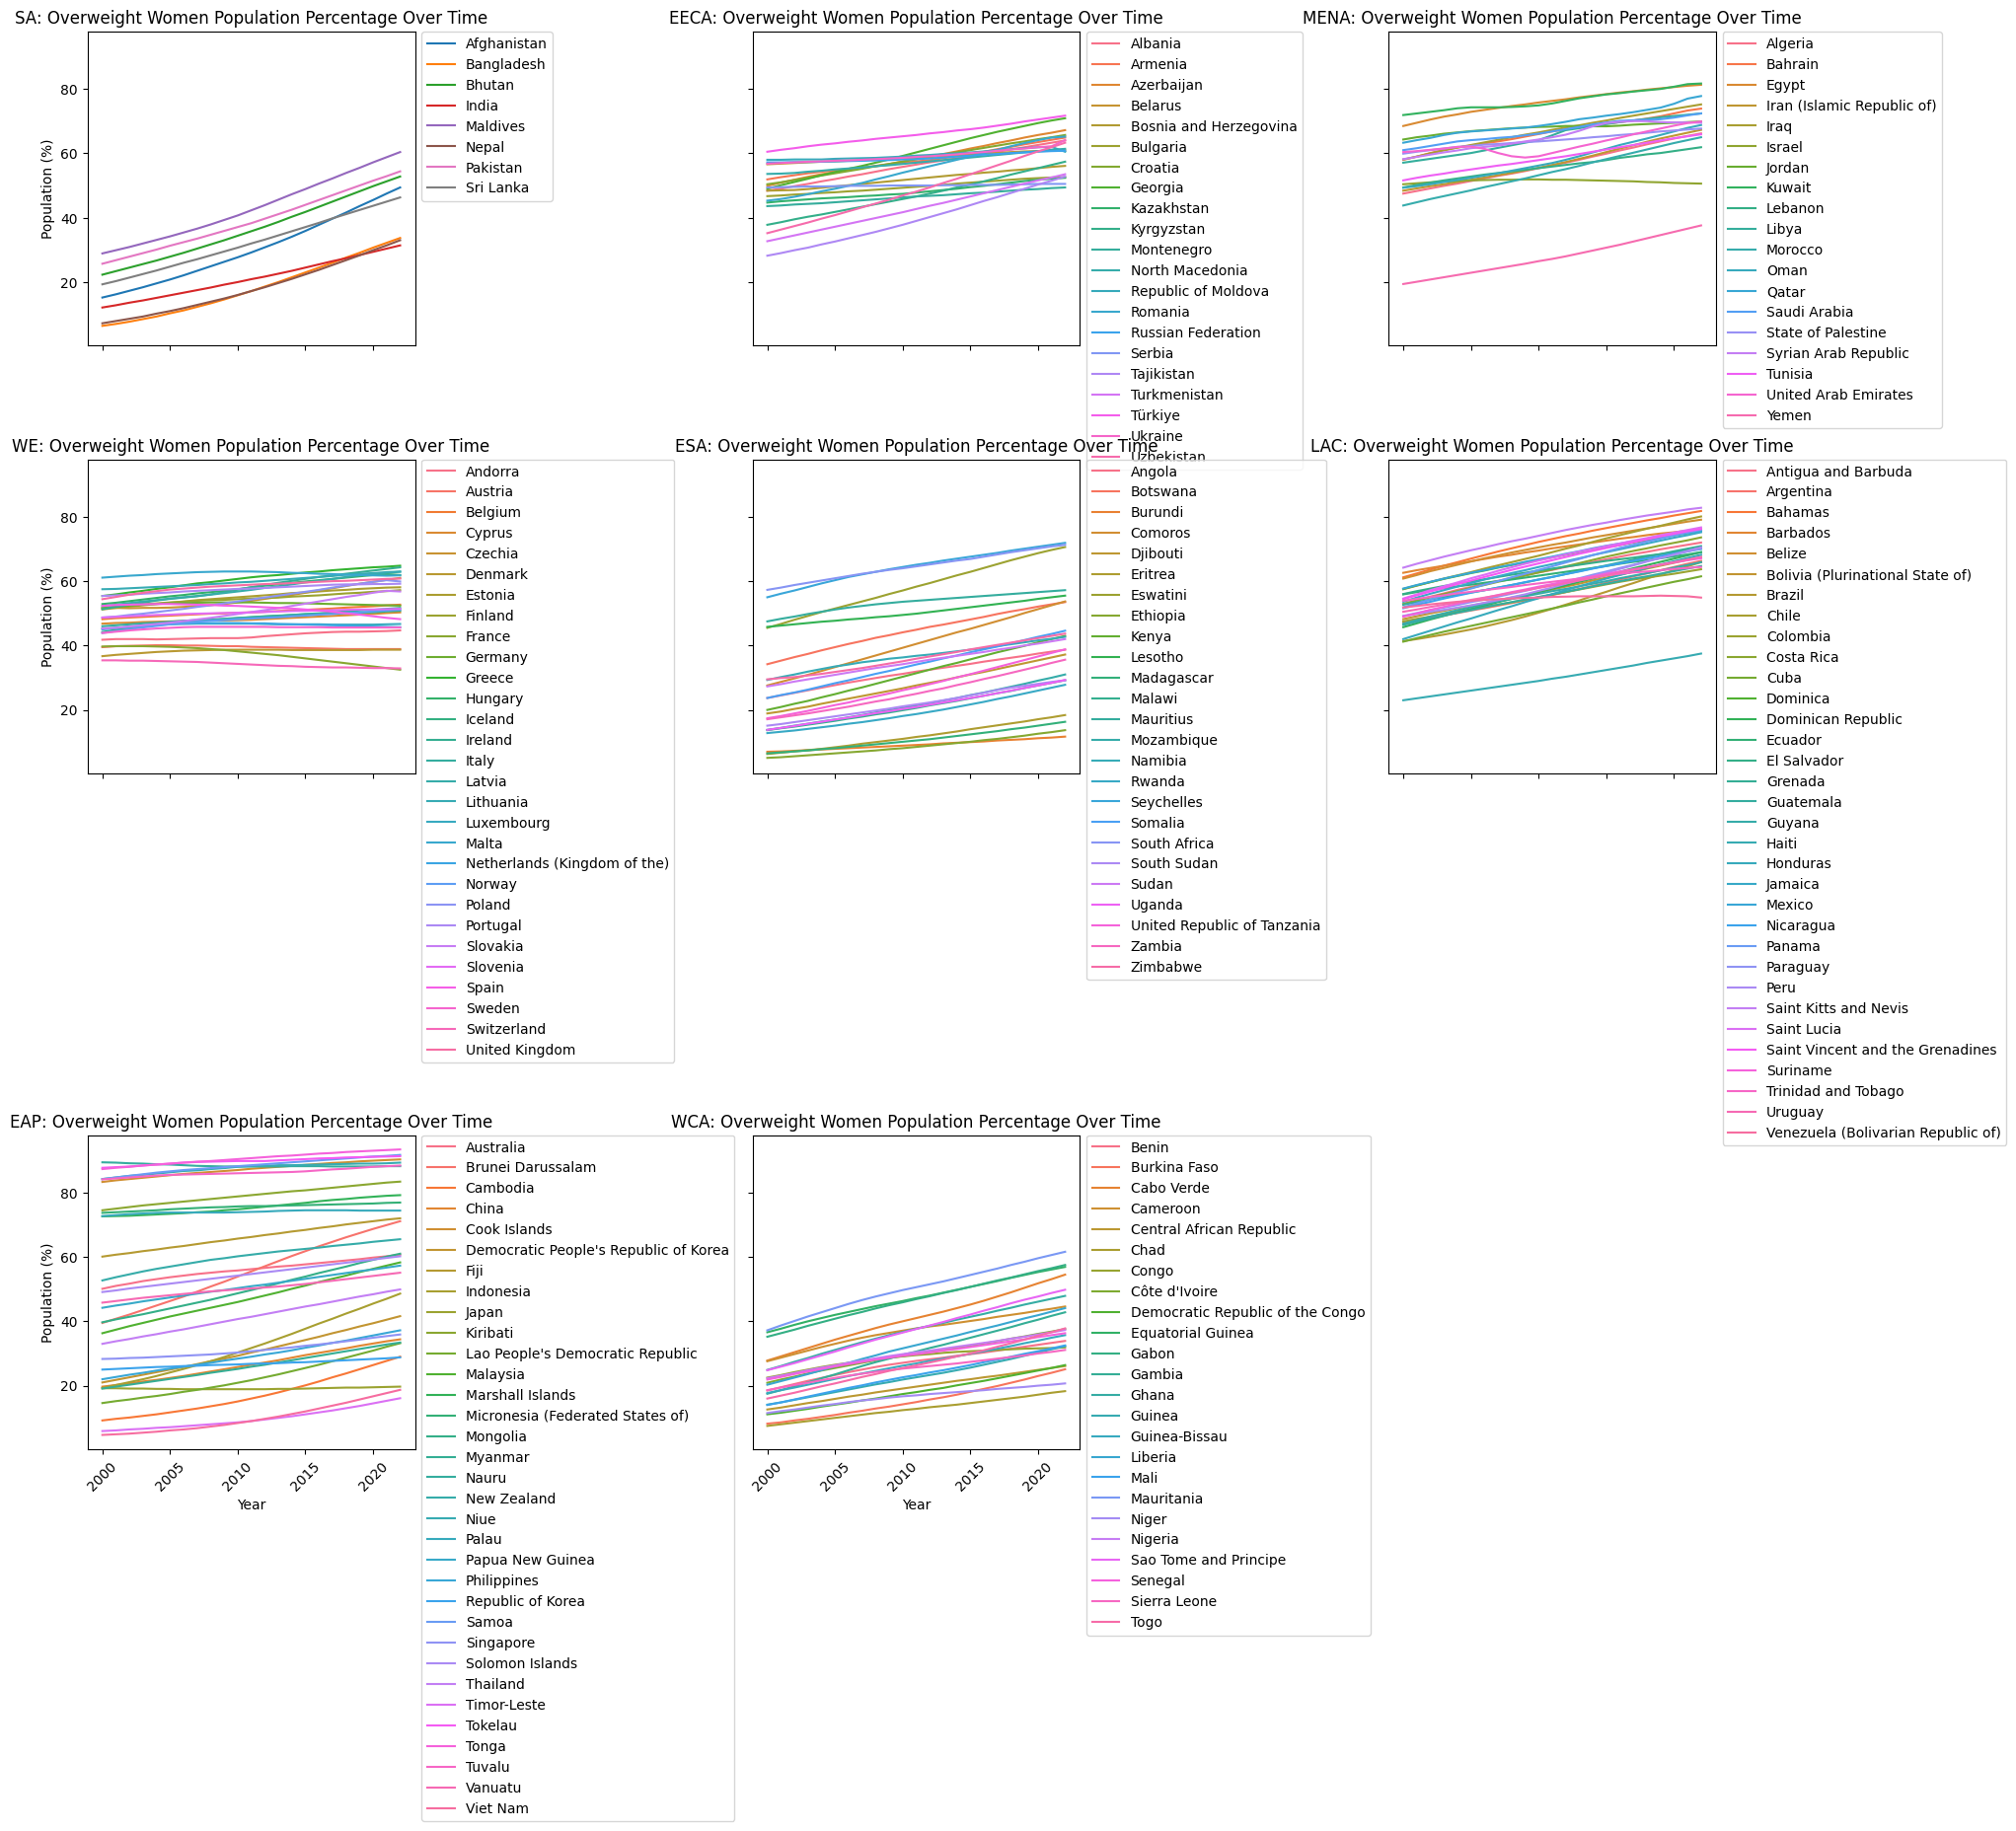

In [24]:
lineplot_viz(long_overweight_df, "Overweight Women")

##Underweight

###Opening and Pivoting Dataset

In [25]:
underweight_df = pd.read_excel(r"/content/UNICEF_Global-database_Womens-Nutrition_August-2025_2.xlsx", sheet_name="underweight", skiprows=6, header=[0,1])

In [26]:
long_underweight_df = pivot_table(underweight_df)

In [27]:
print(long_underweight_df.shape)
long_underweight_df.head()

(4462, 8)


,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
0,Afghanistan,SA,Asia,Low Income,2000,14.2,20.8,28.0
1,Afghanistan,SA,Asia,Low Income,2001,13.8,20.0,27.0
2,Afghanistan,SA,Asia,Low Income,2002,13.3,19.2,25.9
3,Afghanistan,SA,Asia,Low Income,2003,12.9,18.5,24.7
4,Afghanistan,SA,Asia,Low Income,2004,12.5,17.7,23.5


###Exploration

In [28]:
#highest current Underweight percentage
long_underweight_df[long_underweight_df.year == most_recent_year].sort_values(by="Point Estimate", ascending=False).head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
1310,Eritrea,ESA,Africa,Low Income,2022,25.0,34.3,43.7
3955,Timor-Leste,EAP,Asia,Lower Middle Income,2022,19.4,25.0,30.8
1379,Ethiopia,ESA,Africa,Low Income,2022,16.4,21.0,25.8
758,Central African Republic,WCA,Africa,Low Income,2022,12.3,20.2,29.0
2345,Madagascar,ESA,Africa,Low Income,2022,15.3,19.4,23.9
3702,South Sudan,ESA,Africa,Low Income,2022,9.8,18.9,29.7
2851,Niger,WCA,Africa,Low Income,2022,14.9,18.8,22.8
643,Burundi,ESA,Africa,Low Income,2022,12.8,18.0,23.8
3472,Senegal,WCA,Africa,Lower Middle Income,2022,13.1,17.9,23.3
781,Chad,WCA,Africa,Low Income,2022,10.8,16.1,22.1


In [29]:
#lowest current Underweight percentage
long_underweight_df[long_underweight_df.year == most_recent_year].sort_values(by="Point Estimate").head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
4024,Tonga,EAP,Oceania,Upper Middle Income,2022,0.0,0.3,0.8
919,Cook Islands,EAP,Oceania,Not Classified,2022,0.1,0.5,1.5
3403,Samoa,EAP,Oceania,Lower Middle Income,2022,0.1,0.5,1.3
2736,Nauru,EAP,Oceania,High Income,2022,0.1,0.5,1.3
4001,Tokelau,EAP,Oceania,Not Classified,2022,0.0,0.5,1.8
1241,Egypt,MENA,Africa,Lower Middle Income,2022,0.5,0.9,1.5
2092,Kiribati,EAP,Oceania,Lower Middle Income,2022,0.3,1.0,2.2
804,Chile,LAC,Latin America and the Caribbean,High Income,2022,0.5,1.0,1.7
4116,Tuvalu,EAP,Oceania,Upper Middle Income,2022,0.2,1.0,2.5
2897,Niue,EAP,Oceania,Not Classified,2022,0.2,1.0,2.7


In [30]:
cloropleth_viz(long_underweight_df, "Estimated Percentage Underweight Women's Population by Country and Year")

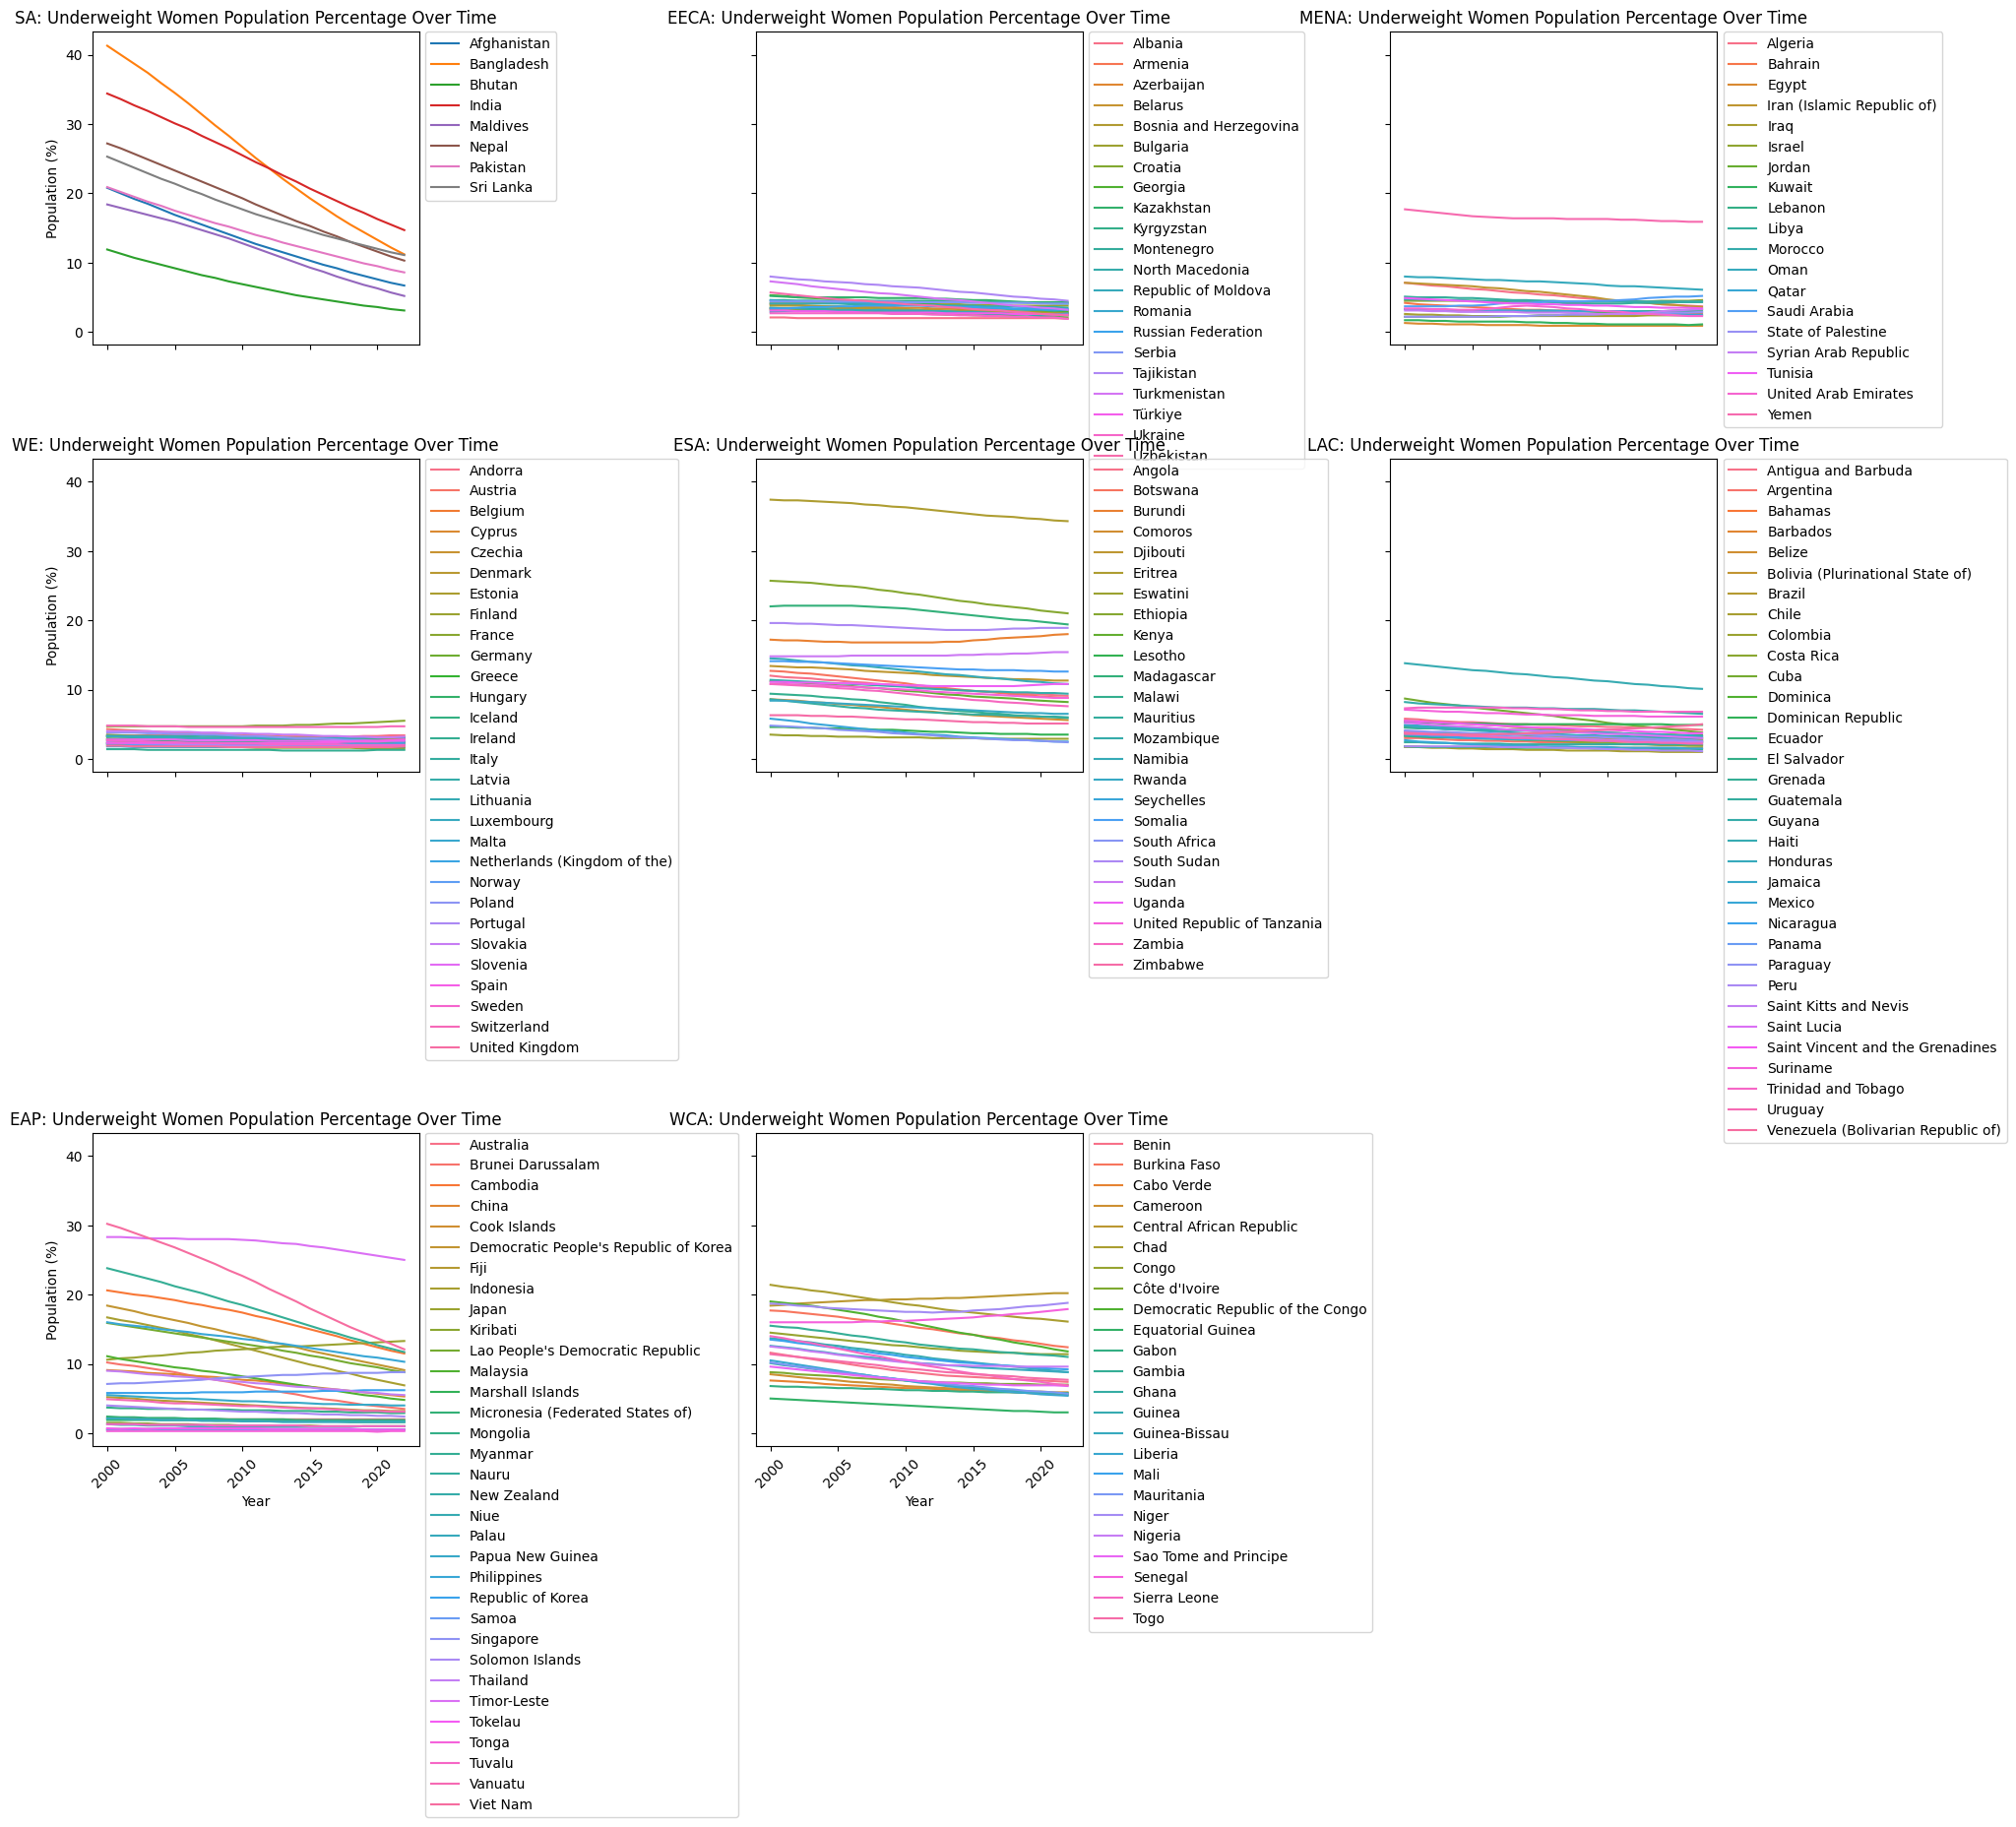

In [31]:
lineplot_viz(long_underweight_df, "Underweight Women")

In [32]:
#countries that have shown the most improvement (lowering of underweight women population percentage) and years the improvement took place
underweight_improved = most_improved(long_underweight_df)
underweight_improved.head(10)

,Country,Peak Year,Low Year,Estimate High,Estimate Low,Estimate Decrease,Percent Decrease
0,Bangladesh,2000.0,2022,41.3,11.2,30.1,72.881356
1,India,2000.0,2022,34.4,14.7,19.7,57.267442
2,Viet Nam,2000.0,2022,30.2,12.1,18.1,59.933775
3,Nepal,2000.0,2022,27.2,10.3,16.9,62.132353
4,Sri Lanka,2000.0,2022,25.3,11.1,14.2,56.126482
5,Afghanistan,2000.0,2022,20.8,6.7,14.1,67.788462
6,Maldives,2000.0,2022,18.4,5.2,13.2,71.739130
7,Pakistan,2000.0,2022,20.9,8.6,12.3,58.851675
8,Myanmar,2000.0,2022,23.8,11.7,12.1,50.840336
9,Indonesia,2000.0,2022,16.7,6.9,9.8,58.682635


In [33]:
underweight_not_improved = least_improved(long_underweight_df)
display(underweight_not_improved.head(10))
display(underweight_not_improved[underweight_not_improved['Initially High'] == True].head(10))

,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
0,Japan,2000,2022,10.6,13.3,2.7,False,Worsened,2,0.932990,2.932990
1,Senegal,2000,2022,16.0,17.9,1.9,True,Worsened,2,0.958763,2.958763
2,Central African Republic,2000,2022,18.4,20.2,1.8,True,Worsened,2,0.984536,2.984536
3,Singapore,2000,2022,7.1,8.8,1.7,False,Worsened,2,0.806701,2.806701
4,Saudi Arabia,2000,2022,3.7,5.2,1.5,False,Worsened,2,0.641753,2.641753
5,Venezuela (Bolivarian Republic of),2000,2022,3.6,5.0,1.4,False,Worsened,2,0.628866,2.628866
6,Jordan,2000,2022,2.2,3.3,1.1,False,Worsened,2,0.497423,2.497423
7,Burundi,2000,2022,17.2,18.0,0.8,True,Worsened,2,0.963918,2.963918
8,France,2000,2022,4.7,5.5,0.8,False,Worsened,2,0.664948,2.664948
9,State of Palestine,2000,2022,2.2,2.9,0.7,False,Worsened,2,0.394330,2.394330


,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
1,Senegal,2000,2022,16.0,17.9,1.9,True,Worsened,2,0.958763,2.958763
2,Central African Republic,2000,2022,18.4,20.2,1.8,True,Worsened,2,0.984536,2.984536
7,Burundi,2000,2022,17.2,18.0,0.8,True,Worsened,2,0.963918,2.963918
10,Sudan,2000,2022,14.8,15.4,0.6,True,Worsened,2,0.943299,2.943299
11,Niger,2000,2022,18.7,18.8,0.1,True,High starting level; failed to improve,1,0.969072,1.969072
12,Uganda,2000,2022,11.1,10.8,-0.3,True,High starting level; failed to improve,1,0.868557,1.868557
76,South Sudan,2000,2022,19.6,18.9,-0.7,True,Not flagged,0,0.974227,0.974227
109,Somalia,2000,2022,14.1,12.6,-1.5,True,Not flagged,0,0.927835,0.927835
121,Yemen,2000,2022,17.7,15.9,-1.8,True,Not flagged,0,0.948454,0.948454
128,Mozambique,2000,2022,11.4,9.4,-2.0,True,Not flagged,0,0.840206,0.840206


##Anemia for Women of Child Bearing Age

###Opening and Pivoting Dataset

In [34]:
anemia_WRA_df = pd.read_excel(r"/content/UNICEF_Global-database_Womens-Nutrition_August-2025_2.xlsx", sheet_name="anaemia_WRA", skiprows=6, header=[0,1])

In [35]:
long_anemia_WRA_df = pivot_table(anemia_WRA_df)

In [36]:
print(long_anemia_WRA_df.shape)
long_anemia_WRA_df.head()

(4656, 8)


,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
0,Afghanistan,SA,Asia,Low Income,2000,19.7,31.6,46.0
1,Afghanistan,SA,Asia,Low Income,2001,20.4,31.5,44.7
2,Afghanistan,SA,Asia,Low Income,2002,21.2,31.4,43.9
3,Afghanistan,SA,Asia,Low Income,2003,22.0,31.6,43.5
4,Afghanistan,SA,Asia,Low Income,2004,22.6,31.9,43.3


###Exploration

In [37]:
most_recent_year = long_anemia_WRA_df.year.max()

In [38]:
#highest current Anemia percentage for child bearing age women(15-49)
long_anemia_WRA_df[long_anemia_WRA_df.year == most_recent_year].sort_values(by="Point Estimate", ascending=False).head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
1535,Gabon,WCA,Africa,Upper Middle Income,2023,42.5,59.9,72.2
2543,Mali,WCA,Africa,Low Income,2023,39.4,56.5,72.1
2615,Mauritania,WCA,Africa,Lower Middle Income,2023,36.7,54.5,68.5
1895,India,SA,Asia,Lower Middle Income,2023,38.8,53.7,66.3
1103,Côte d'Ivoire,WCA,Africa,Lower Middle Income,2023,37.8,51.4,64.3
455,Benin,WCA,Africa,Lower Middle Income,2023,33.9,50.0,66.5
2975,Niger,WCA,Africa,Low Income,2023,29.0,47.1,67.6
2807,Mozambique,ESA,Africa,Low Income,2023,32.6,47.0,60.7
935,Congo,WCA,Africa,Lower Middle Income,2023,29.2,46.7,64.3
815,Chad,WCA,Africa,Low Income,2023,24.2,46.5,71.5


In [39]:
#lowest current Anemia percentage for child bearing age women(15-49)
long_anemia_WRA_df[long_anemia_WRA_df.year == most_recent_year].sort_values(by="Point Estimate").head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
1703,Guatemala,LAC,Latin America and the Caribbean,Upper Middle Income,2023,5.6,10.5,18.4
215,Australia,EAP,Oceania,High Income,2023,4.2,11.1,22.6
3263,Philippines,EAP,Asia,Lower Middle Income,2023,8.2,12.0,16.9
2951,New Zealand,EAP,Oceania,High Income,2023,5.3,12.4,21.2
1511,France,WE,Europe,High Income,2023,4.2,13.1,26.8
2663,Mexico,LAC,Latin America and the Caribbean,Upper Middle Income,2023,8.3,13.2,20.0
4415,United Kingdom,WE,Europe,High Income,2023,7.6,13.6,21.0
1487,Finland,WE,Europe,High Income,2023,5.1,13.6,25.9
983,Costa Rica,LAC,Latin America and the Caribbean,Upper Middle Income,2023,5.3,13.7,28.8
1991,Ireland,WE,Europe,High Income,2023,4.4,14.0,30.6


In [40]:
improved_anemia_WRA_women = most_improved(long_anemia_WRA_df)
improved_anemia_WRA_women.head(10)

,Country,Peak Year,Low Year,Estimate High,Estimate Low,Estimate Decrease,Percent Decrease
0,Uzbekistan,2000.0,2019,45.2,29.6,15.6,34.513274
1,Democratic Republic of the Congo,2000.0,2020,54.1,39.6,14.5,26.802218
2,Philippines,2000.0,2023,26.5,12.0,14.5,54.716981
3,Gambia,2000.0,2023,60.6,46.1,14.5,23.927393
4,Senegal,2000.0,2022,57.4,43.1,14.3,24.912892
5,Guatemala,2000.0,2014,21.9,8.3,13.6,62.100457
6,Liberia,2000.0,2016,52.8,39.8,13.0,24.621212
7,Colombia,2000.0,2013,30.7,17.8,12.9,42.019544
8,Nigeria,2000.0,2023,50.3,37.9,12.4,24.652087
9,Burkina Faso,2000.0,2021,55.8,43.6,12.2,21.863799


In [41]:
anemia_WRA_not_improved = least_improved(long_anemia_WRA_df)
display(anemia_WRA_not_improved.head(10))
display(anemia_WRA_not_improved[anemia_WRA_not_improved['Initially High'] == True].head(10))

,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
0,Mauritius,2000,2023,18.4,32.8,14.4,False,Worsened,2,0.721649,2.721649
1,Afghanistan,2000,2023,31.6,45.4,13.8,False,Worsened,2,0.917526,2.917526
2,Pakistan,2000,2023,35.7,46.5,10.8,True,Worsened,2,0.951031,2.951031
3,Ukraine,2000,2023,11.6,19.4,7.8,False,Worsened,2,0.244845,2.244845
4,United States,2000,2023,7.8,15.0,7.2,False,Worsened,2,0.087629,2.087629
5,Jordan,2000,2023,25.9,33.0,7.1,False,Worsened,2,0.731959,2.731959
6,North Macedonia,2000,2023,14.8,21.5,6.7,False,Worsened,2,0.322165,2.322165
7,Chile,2000,2023,9.0,15.7,6.7,False,Worsened,2,0.126289,2.126289
8,Lebanon,2000,2023,27.6,34.0,6.4,False,Worsened,2,0.750000,2.750000
9,Burundi,2000,2023,32.9,39.0,6.1,False,Worsened,2,0.845361,2.845361


,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
2,Pakistan,2000,2023,35.7,46.5,10.8,True,Worsened,2,0.951031,2.951031
35,India,2000,2023,50.2,53.7,3.5,True,Worsened,2,0.984536,2.984536
72,Somalia,2000,2023,44.9,46.2,1.3,True,Worsened,2,0.943299,2.943299
73,Bangladesh,2000,2023,36.5,37.6,1.1,True,Worsened,2,0.814433,2.814433
78,Madagascar,2000,2023,36.6,37.2,0.6,True,Worsened,2,0.798969,2.798969
97,Eritrea,2000,2023,37.3,35.6,-1.7,True,Not flagged,0,0.780928,0.780928
104,Tajikistan,2000,2023,39.1,37.3,-1.8,True,Not flagged,0,0.804124,0.804124
107,Azerbaijan,2000,2023,37.6,35.6,-2.0,True,Not flagged,0,0.780928,0.780928
114,Mauritania,2000,2023,57.3,54.5,-2.8,True,Not flagged,0,0.989691,0.989691
116,Mozambique,2000,2023,49.9,47.0,-2.9,True,Not flagged,0,0.963918,0.963918


In [42]:
cloropleth_viz(long_anemia_WRA_df, "Estimated Anemia Percentage of Women of Childbearing Age(15-49) by Country and Year")

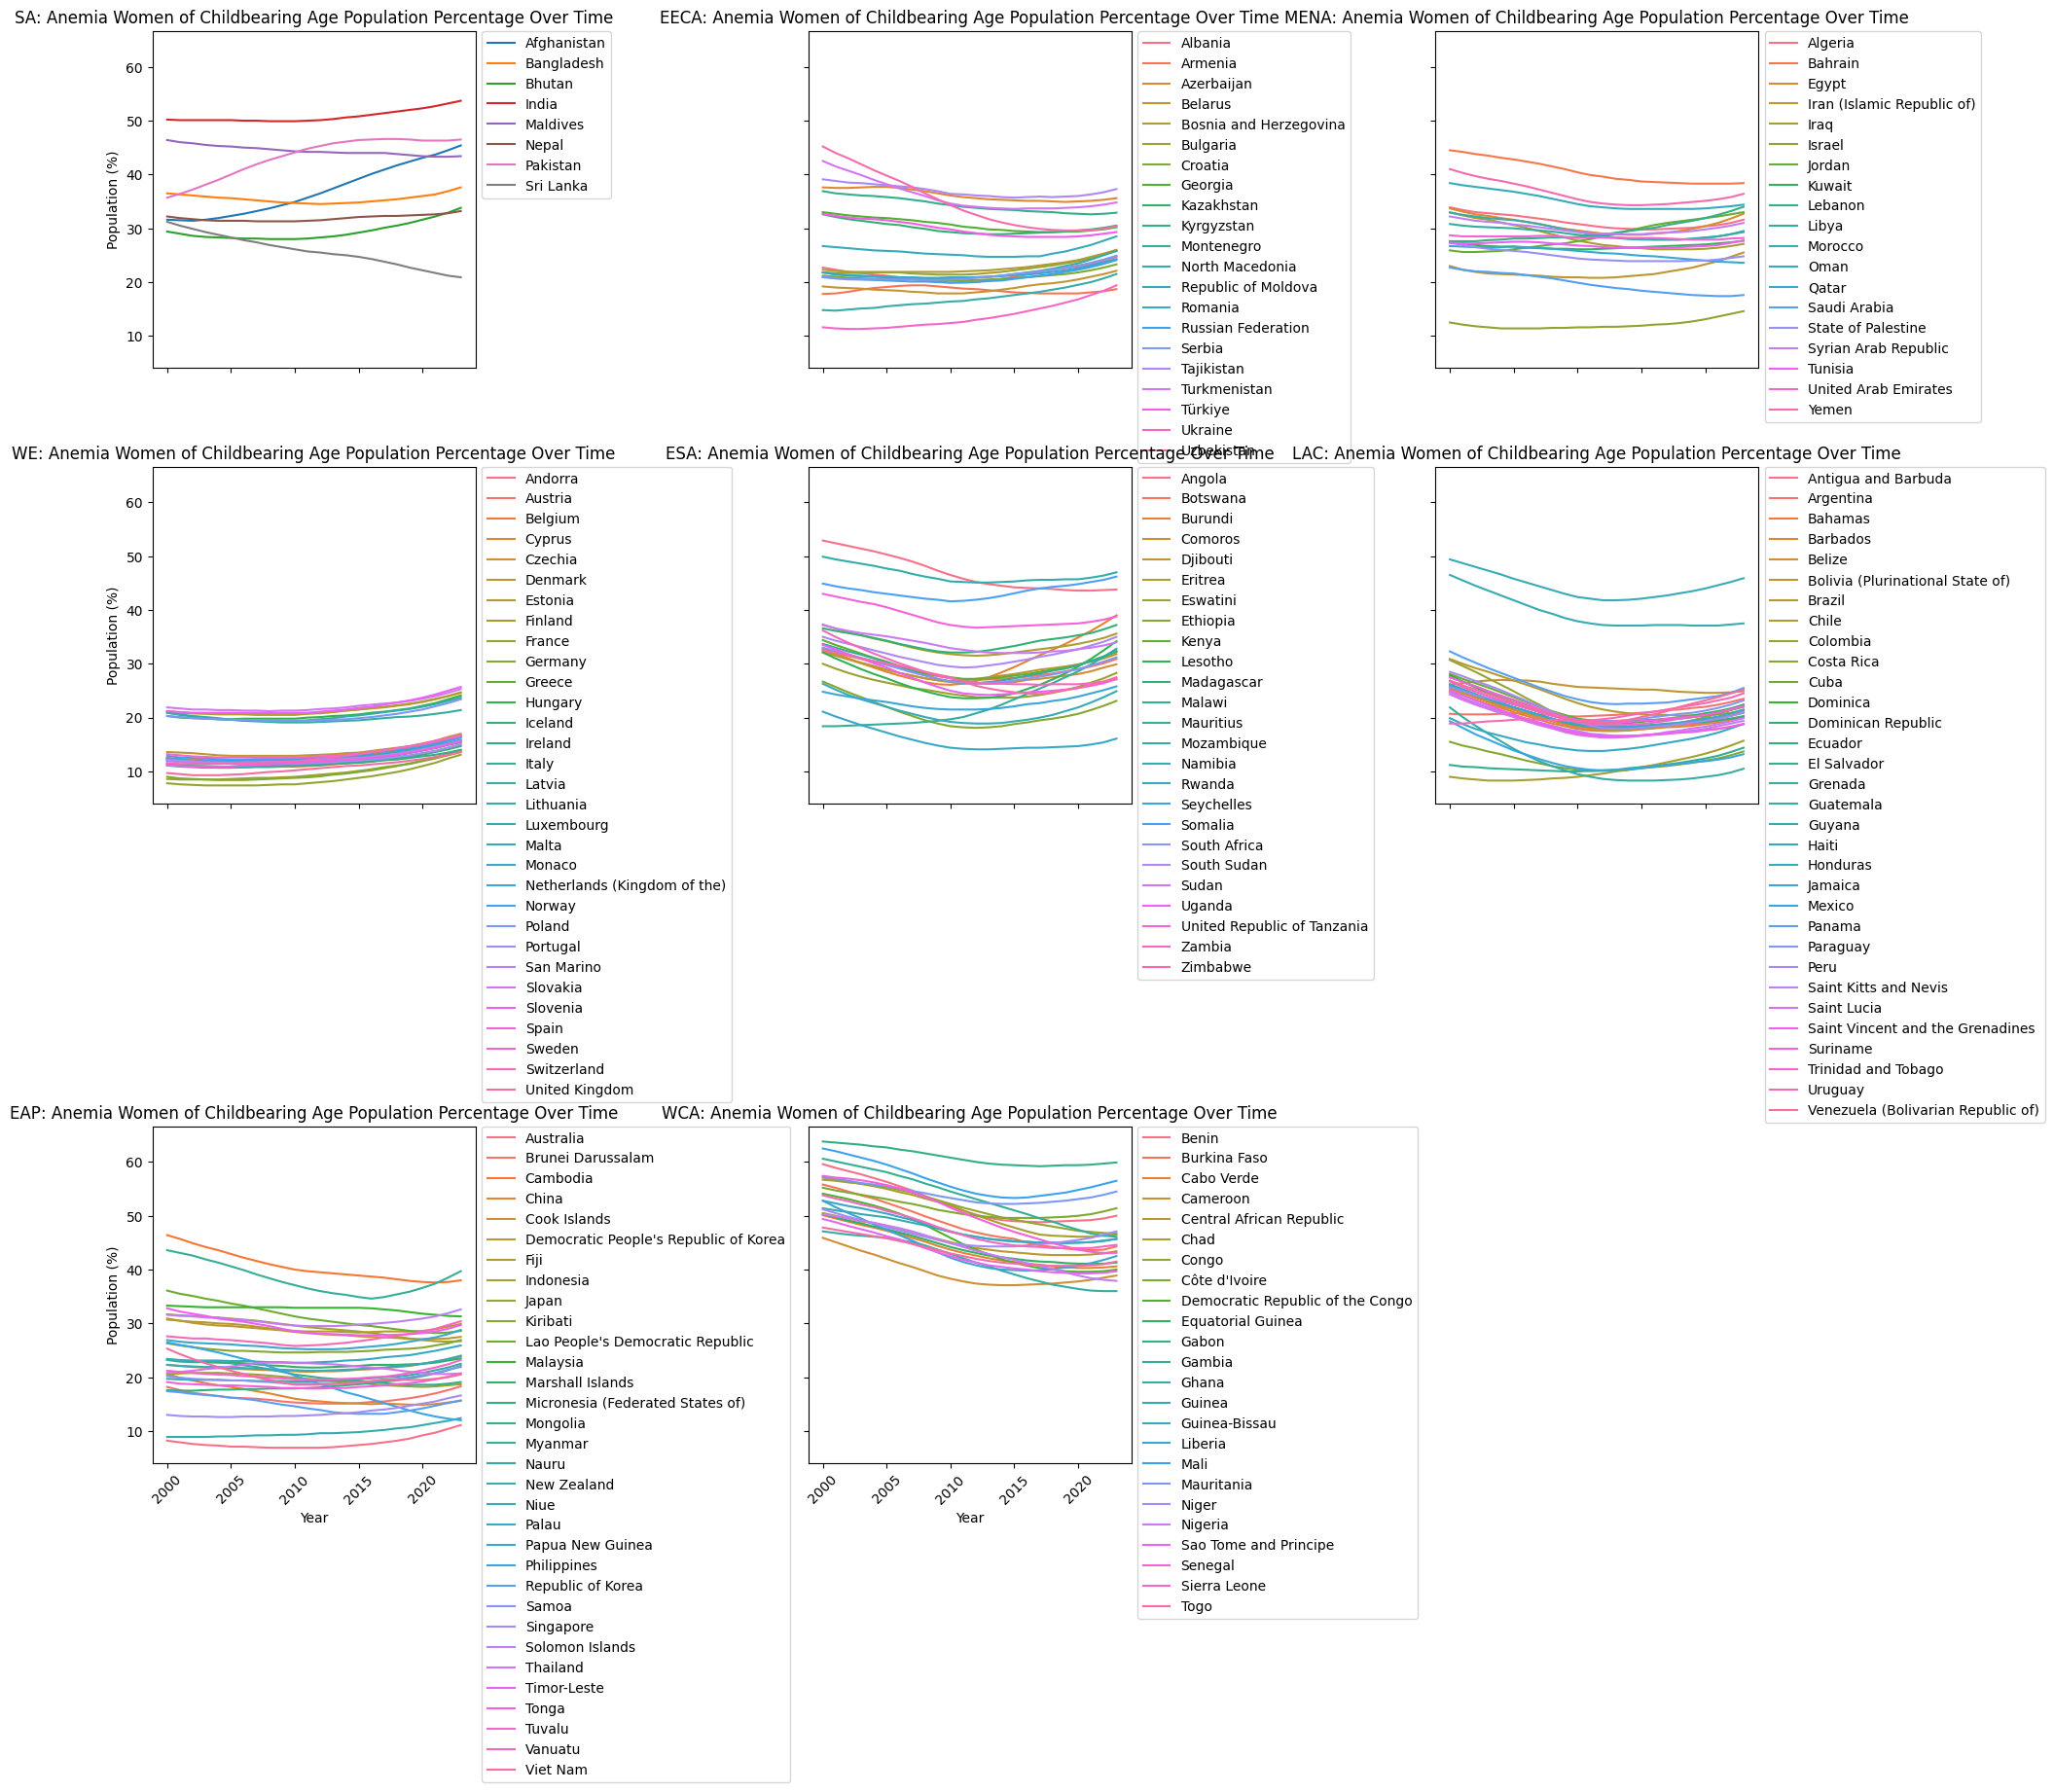

In [43]:
lineplot_viz(long_anemia_WRA_df, "Anemia Women of Childbearing Age")

Probably not important for our research question but why has anemia for pregnant women in the US almost doubled between 2000 and 2023?

##Anemia for Pregnant Women

###Opening and Pivoting Dataset

In [44]:
anemia_pregnant_women_df = pd.read_excel(r"/content/UNICEF_Global-database_Womens-Nutrition_August-2025_2.xlsx", sheet_name="anaemia_pregnant_women", skiprows=6, header=[0,1])

In [45]:
long_anemia_pregnant_women_df = pivot_table(anemia_pregnant_women_df)

In [46]:
print(long_anemia_pregnant_women_df.shape)
long_anemia_pregnant_women_df.head()

(4656, 8)


,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
0,Afghanistan,SA,Asia,Low Income,2000,24.8,38.6,53.0
1,Afghanistan,SA,Asia,Low Income,2001,25.0,38.2,52.1
2,Afghanistan,SA,Asia,Low Income,2002,24.9,37.8,51.1
3,Afghanistan,SA,Asia,Low Income,2003,24.8,37.4,50.1
4,Afghanistan,SA,Asia,Low Income,2004,24.8,37.0,49.4


###Exploration

In [47]:
#highest current Anemia percentage for pregnant women
long_anemia_pregnant_women_df[long_anemia_pregnant_women_df.year == most_recent_year].sort_values(by="Point Estimate", ascending=False).head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
2543,Mali,WCA,Africa,Low Income,2023,48.8,62.1,73.9
455,Benin,WCA,Africa,Lower Middle Income,2023,45.1,60.2,72.2
1103,Côte d'Ivoire,WCA,Africa,Lower Middle Income,2023,45.3,57.3,67.6
2975,Niger,WCA,Africa,Low Income,2023,40.6,55.9,71.0
1535,Gabon,WCA,Africa,Upper Middle Income,2023,40.7,54.8,67.0
2807,Mozambique,ESA,Africa,Low Income,2023,41.5,54.6,65.7
1559,Gambia,WCA,Africa,Low Income,2023,42.8,54.1,65.6
2615,Mauritania,WCA,Africa,Lower Middle Income,2023,39.7,53.9,67.3
3719,Sierra Leone,WCA,Africa,Low Income,2023,41.9,53.7,66.5
3839,Somalia,ESA,Africa,Low Income,2023,36.1,52.8,67.1


In [48]:
improved_anemia_pregnant_women = most_improved(long_anemia_pregnant_women_df)
improved_anemia_pregnant_women.head(10)

,Country,Peak Year,Low Year,Estimate High,Estimate Low,Estimate Decrease,Percent Decrease
0,Philippines,2000.0,2023,42.3,24.0,18.3,43.262411
1,Cambodia,2000.0,2023,56.6,41.0,15.6,27.561837
2,Lao People's Democratic Republic,2000.0,2023,45.1,30.0,15.1,33.481153
3,China,2000.0,2023,28.7,14.2,14.5,50.522648
4,Myanmar,2000.0,2016,55.5,42.4,13.1,23.603604
5,Gambia,2000.0,2023,66.7,54.1,12.6,18.890555
6,Viet Nam,2000.0,2023,37.7,25.3,12.4,32.891247
7,Maldives,2000.0,2023,53.3,41.3,12.0,22.514071
8,Senegal,2001.0,2023,62.7,50.9,11.8,18.819777
9,Indonesia,2000.0,2023,38.6,27.1,11.5,29.792746


In [49]:
anemia_pregnant_women_not_improved = least_improved(long_anemia_pregnant_women_df)
display(anemia_pregnant_women_not_improved.head(10))
display(anemia_pregnant_women_not_improved[anemia_pregnant_women_not_improved['Initially High'] == True].head(10))

,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
0,Kyrgyzstan,2000,2023,37.4,42.5,5.1,False,Worsened,2,0.840206,2.840206
1,Egypt,2000,2023,32.9,36.3,3.4,False,Worsened,2,0.757732,2.757732
2,Mozambique,2000,2023,52.4,54.6,2.2,True,Worsened,2,0.974227,2.974227
3,Jordan,2000,2023,31.1,33.3,2.2,False,Worsened,2,0.685567,2.685567
4,Lebanon,2000,2023,31.5,33.6,2.1,False,Worsened,2,0.690722,2.690722
5,Somalia,2000,2023,50.8,52.8,2.0,True,Worsened,2,0.953608,2.953608
6,Burundi,2000,2023,42.7,44.7,2.0,True,Worsened,2,0.865979,2.865979
7,Lesotho,2000,2023,34.8,35.8,1.0,False,Worsened,2,0.747423,2.747423
8,Syrian Arab Republic,2000,2023,35.4,35.2,-0.2,False,Not flagged,0,0.721649,0.721649
9,Tajikistan,2000,2023,39.9,39.6,-0.3,False,Not flagged,0,0.798969,0.798969


,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
2,Mozambique,2000,2023,52.4,54.6,2.2,True,Worsened,2,0.974227,2.974227
5,Somalia,2000,2023,50.8,52.8,2.0,True,Worsened,2,0.953608,2.953608
6,Burundi,2000,2023,42.7,44.7,2.0,True,Worsened,2,0.865979,2.865979
10,Côte d'Ivoire,2000,2023,57.9,57.3,-0.6,True,Not flagged,0,0.989691,0.989691
17,South Sudan,2000,2023,43.3,42.2,-1.1,True,Not flagged,0,0.835052,0.835052
23,Yemen,2000,2023,42.7,41.2,-1.5,True,Not flagged,0,0.819588,0.819588
29,Niger,2000,2023,57.9,55.9,-2.0,True,Not flagged,0,0.984536,0.984536
33,Sierra Leone,2000,2023,56.3,53.7,-2.6,True,Not flagged,0,0.958763,0.958763
34,Madagascar,2000,2023,41.9,39.3,-2.6,True,Not flagged,0,0.793814,0.793814
35,Eritrea,2000,2023,44.2,41.5,-2.7,True,Not flagged,0,0.829897,0.829897


In [50]:
cloropleth_viz(long_anemia_pregnant_women_df, "Estimated Anemia Percentage of Pregnant Women by Country and Year")

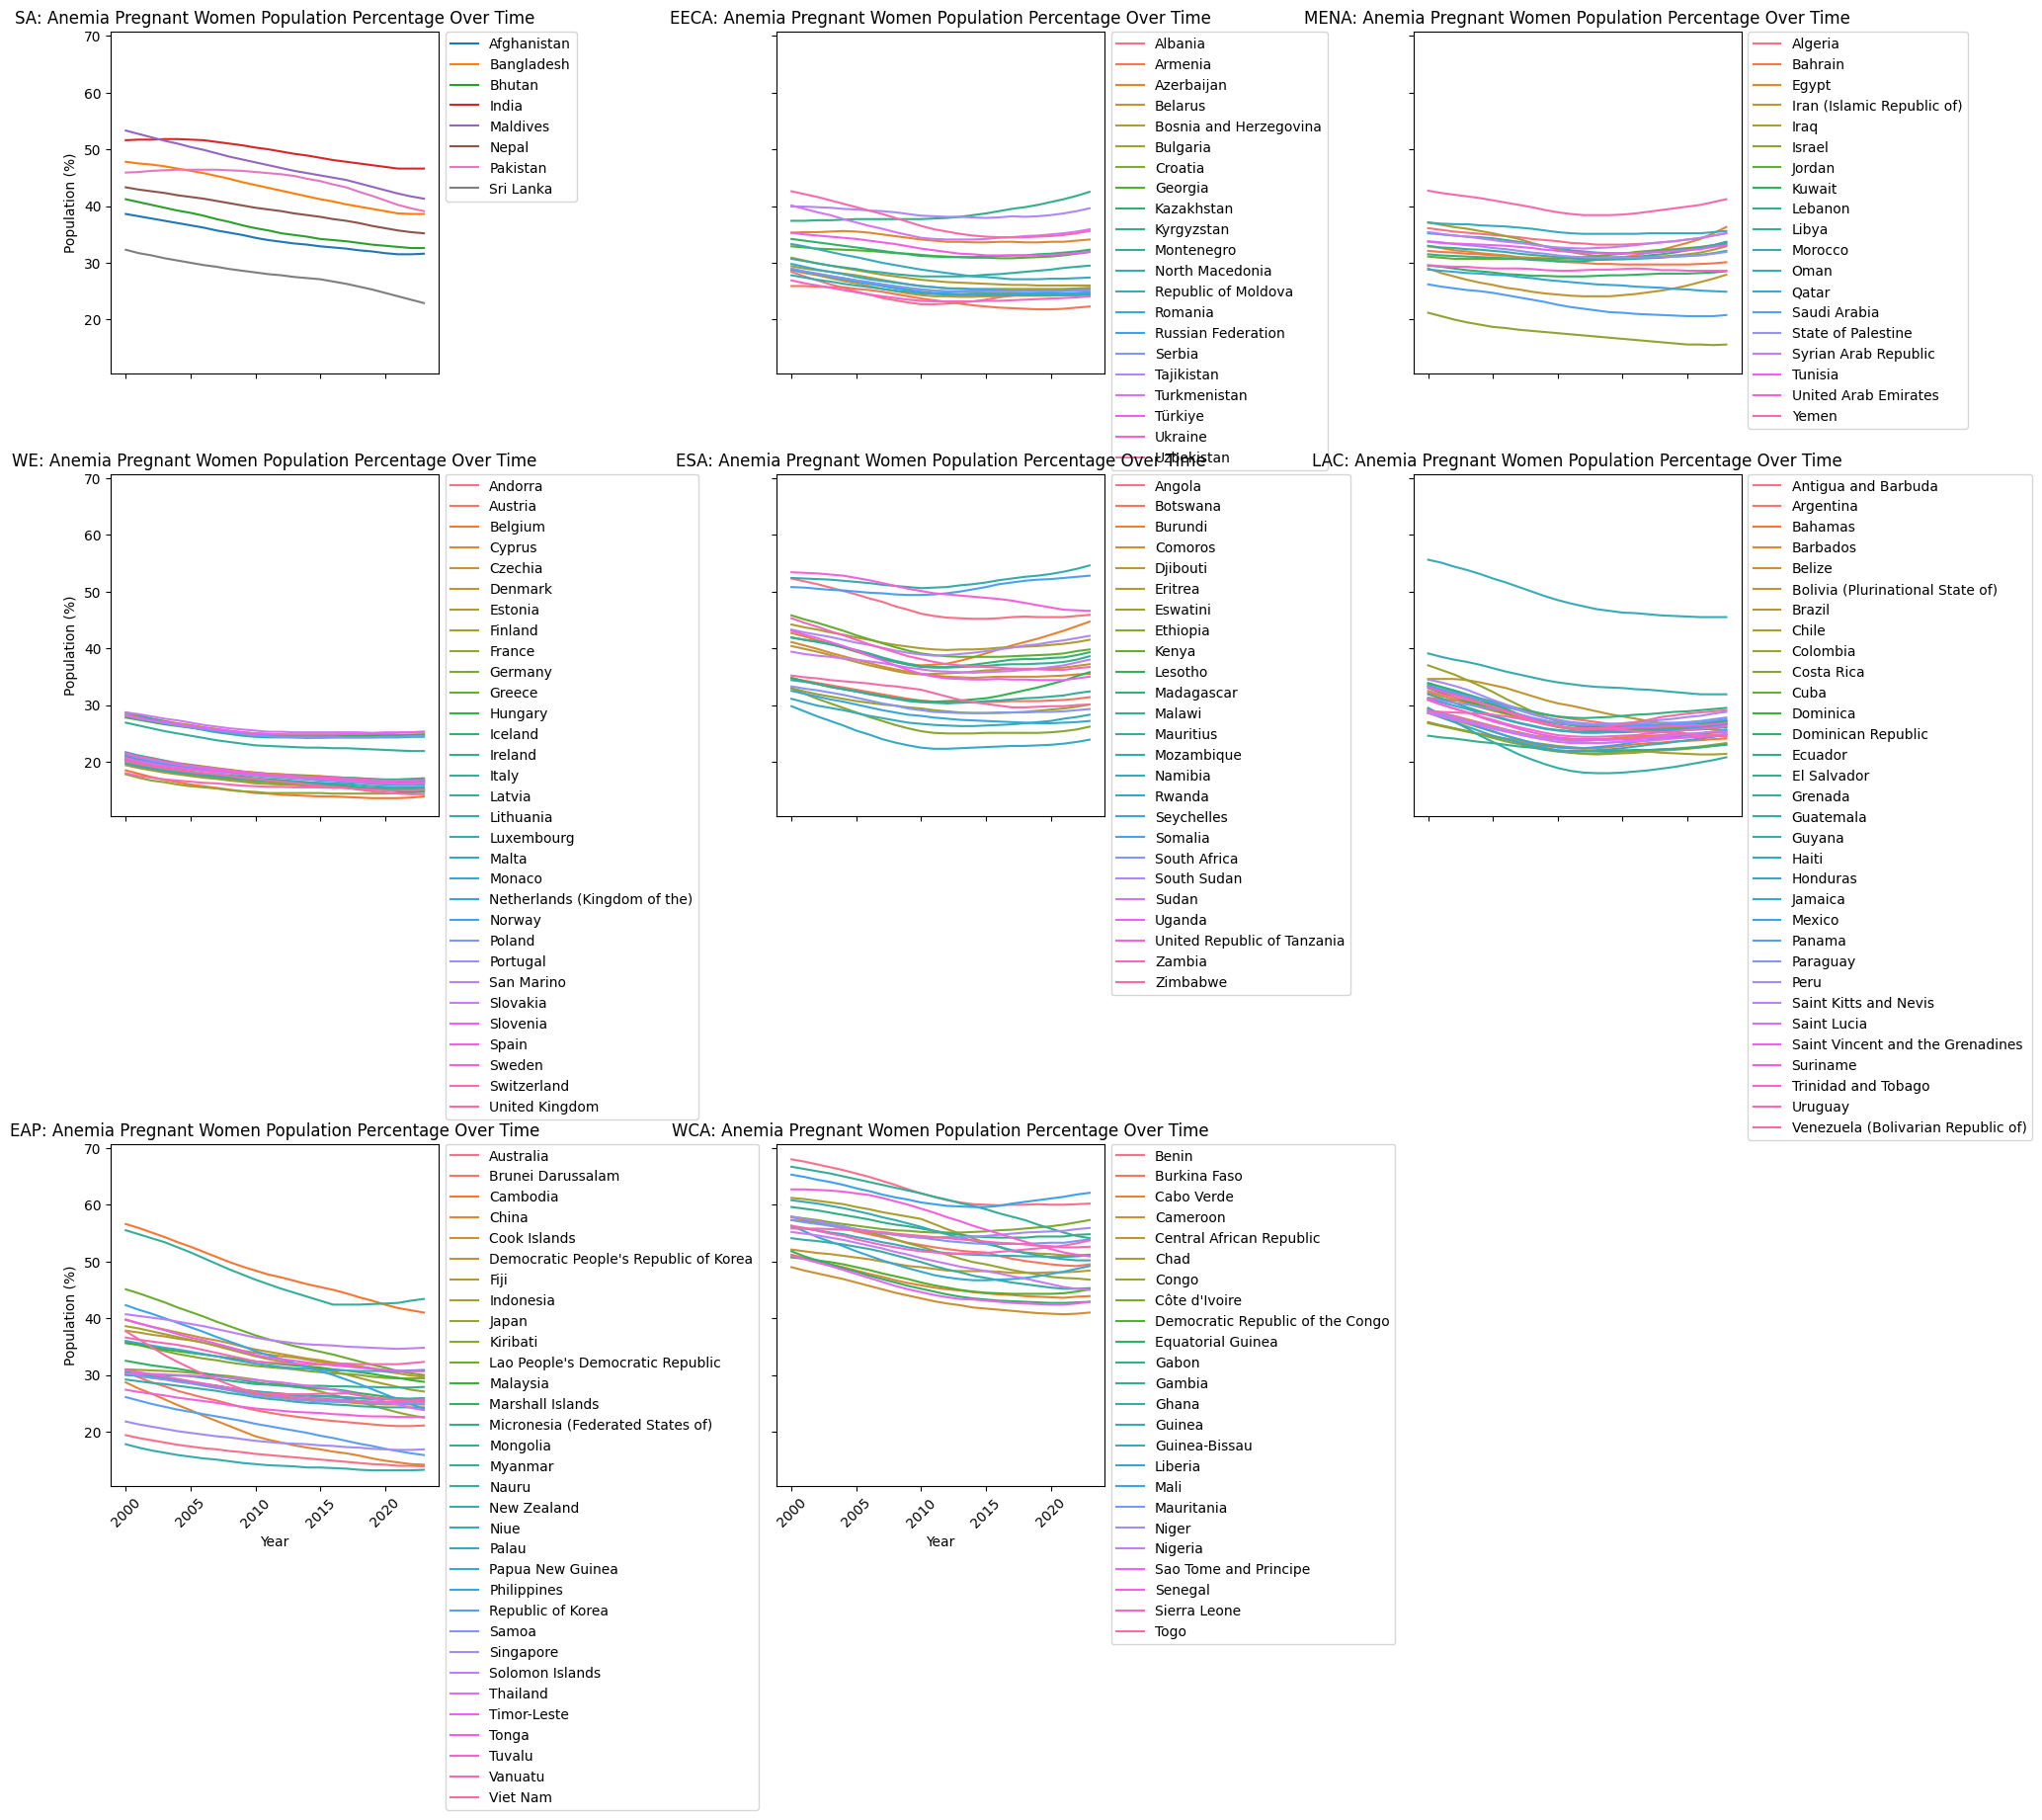

In [51]:
lineplot_viz(long_anemia_pregnant_women_df, "Anemia Pregnant Women")

##Anemia for Non-Pregnant Women

###Opening and Pivoting Dataset

In [52]:
anaemia_nonpregnant_women_df = pd.read_excel(r"/content/UNICEF_Global-database_Womens-Nutrition_August-2025_2.xlsx", sheet_name="anaemia_nonpregnant_women", skiprows=6, header=[0,1])

In [53]:
long_anaemia_nonpregnant_women_df = pivot_table(anaemia_nonpregnant_women_df)

In [54]:
print(long_anaemia_nonpregnant_women_df.shape)
long_anaemia_nonpregnant_women_df.head()

(4656, 8)


,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
0,Afghanistan,SA,Asia,Low Income,2000,17.8,30.3,45.7
1,Afghanistan,SA,Asia,Low Income,2001,18.7,30.3,44.4
2,Afghanistan,SA,Asia,Low Income,2002,19.7,30.4,43.7
3,Afghanistan,SA,Asia,Low Income,2003,20.5,30.6,43.3
4,Afghanistan,SA,Asia,Low Income,2004,21.4,31.1,43.0


###Exploration

In [55]:
#highest current Anemia percentage for non-pregnant women
long_anaemia_nonpregnant_women_df[long_anaemia_nonpregnant_women_df.year == most_recent_year].sort_values(by="Point Estimate", ascending=False).head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
1535,Gabon,WCA,Africa,Upper Middle Income,2023,42.2,60.3,73.1
2543,Mali,WCA,Africa,Low Income,2023,37.7,55.8,72.2
2615,Mauritania,WCA,Africa,Lower Middle Income,2023,35.9,54.5,69.1
1895,India,SA,Asia,Lower Middle Income,2023,38.7,54.0,66.8
1103,Côte d'Ivoire,WCA,Africa,Lower Middle Income,2023,36.7,50.8,64.2
455,Benin,WCA,Africa,Lower Middle Income,2023,32.2,49.0,66.1
3119,Pakistan,SA,Asia,Lower Middle Income,2023,32.3,47.1,61.8
23,Afghanistan,SA,Asia,Low Income,2023,25.7,46.9,68.5
935,Congo,WCA,Africa,Lower Middle Income,2023,28.2,46.7,65.3
2807,Mozambique,ESA,Africa,Low Income,2023,31.3,46.1,60.7


In [56]:
#lowest current Anemia percentage for non-pregnant women
long_anaemia_nonpregnant_women_df[long_anaemia_nonpregnant_women_df.year == most_recent_year].sort_values(by="Point Estimate").head(10)

,Country,UNICEF Regions,UN Regions,World Bank Income Groups,year,Lower Limit,Point Estimate,Upper Limit
1703,Guatemala,LAC,Latin America and the Caribbean,Upper Middle Income,2023,5.2,10.0,17.9
215,Australia,EAP,Oceania,High Income,2023,4.0,11.0,22.6
3263,Philippines,EAP,Asia,Lower Middle Income,2023,7.7,11.6,16.6
2951,New Zealand,EAP,Oceania,High Income,2023,5.1,12.3,21.3
2663,Mexico,LAC,Latin America and the Caribbean,Upper Middle Income,2023,7.8,12.7,19.6
1511,France,WE,Europe,High Income,2023,4.0,13.0,26.9
1487,Finland,WE,Europe,High Income,2023,4.9,13.5,25.9
983,Costa Rica,LAC,Latin America and the Caribbean,Upper Middle Income,2023,5.0,13.5,28.7
4415,United Kingdom,WE,Europe,High Income,2023,7.5,13.5,21.0
1607,Germany,WE,Europe,High Income,2023,5.0,13.9,26.7


In [57]:
improved_anemia_nonpregnant_women = most_improved(long_anaemia_nonpregnant_women_df)
improved_anemia_nonpregnant_women.head(10)

,Country,Peak Year,Low Year,Estimate High,Estimate Low,Estimate Decrease,Percent Decrease
0,Uzbekistan,2000.0,2020,45.3,29.2,16.1,35.540839
1,Democratic Republic of the Congo,2000.0,2020,54.6,38.9,15.7,28.754579
2,Senegal,2000.0,2023,56.8,42.4,14.4,25.352113
3,Gambia,2000.0,2023,59.8,45.4,14.4,24.080268
4,Philippines,2000.0,2023,25.2,11.6,13.6,53.968254
5,Guatemala,2000.0,2014,21.1,7.6,13.5,63.981043
6,Liberia,2000.0,2015,52.3,39.2,13.1,25.047801
7,Colombia,2000.0,2013,30.4,17.5,12.9,42.434211
8,Burkina Faso,2000.0,2020,55.6,43.1,12.5,22.482014
9,Nigeria,2000.0,2023,49.6,37.2,12.4,25.000000


In [58]:
anaemia_nonpregnant_women_not_improved = least_improved(long_anaemia_nonpregnant_women_df)
display(anaemia_nonpregnant_women_not_improved.head(10))
display(anaemia_nonpregnant_women_not_improved[anaemia_nonpregnant_women_not_improved['Initially High'] == True].head(10))

,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
0,Afghanistan,2000,2023,30.3,46.9,16.6,False,Worsened,2,0.963918,2.963918
1,Mauritius,2000,2023,17.7,32.8,15.1,False,Worsened,2,0.726804,2.726804
2,Pakistan,2000,2023,34.5,47.1,12.6,True,Worsened,2,0.969072,2.969072
3,Ukraine,2000,2023,11.3,19.3,8.0,False,Worsened,2,0.244845,2.244845
4,Jordan,2000,2023,25.5,33.0,7.5,False,Worsened,2,0.731959,2.731959
5,United States,2000,2023,7.7,15.1,7.4,False,Worsened,2,0.090206,2.090206
6,Chile,2000,2023,8.3,15.6,7.3,False,Worsened,2,0.115979,2.115979
7,North Macedonia,2000,2023,14.3,21.4,7.1,False,Worsened,2,0.319588,2.319588
8,Burundi,2000,2023,31.6,38.4,6.8,False,Worsened,2,0.835052,2.835052
9,Lebanon,2000,2023,27.4,34.0,6.6,False,Worsened,2,0.752577,2.752577


,Country,Starting Year,Ending Year,Starting Estimate,Ending Estimate,Percentage Point Change,Initially High,Condition,Condition Order,Percentile,Score
2,Pakistan,2000,2023,34.5,47.1,12.6,True,Worsened,2,0.969072,2.969072
33,India,2000,2023,50.1,54.0,3.9,True,Worsened,2,0.984536,2.984536
73,Bangladesh,2000,2023,35.6,37.5,1.9,True,Worsened,2,0.814433,2.814433
75,Somalia,2000,2023,43.9,45.2,1.3,True,Worsened,2,0.917526,2.917526
78,Madagascar,2000,2023,35.9,37.0,1.1,True,Worsened,2,0.798969,2.798969
96,Eritrea,2000,2023,36.5,35.2,-1.3,True,Not flagged,0,0.778351,0.778351
107,Tajikistan,2000,2023,39.0,37.1,-1.9,True,Not flagged,0,0.804124,0.804124
108,Azerbaijan,2000,2023,37.6,35.6,-2.0,True,Not flagged,0,0.788660,0.788660
115,Maldives,2000,2023,46.0,43.5,-2.5,True,Not flagged,0,0.896907,0.896907
116,Mauritania,2000,2023,57.3,54.5,-2.8,True,Not flagged,0,0.989691,0.989691


In [59]:
cloropleth_viz(long_anaemia_nonpregnant_women_df, "Estimated Anemia Percentage of Non-Pregnant Women by Country and Year")

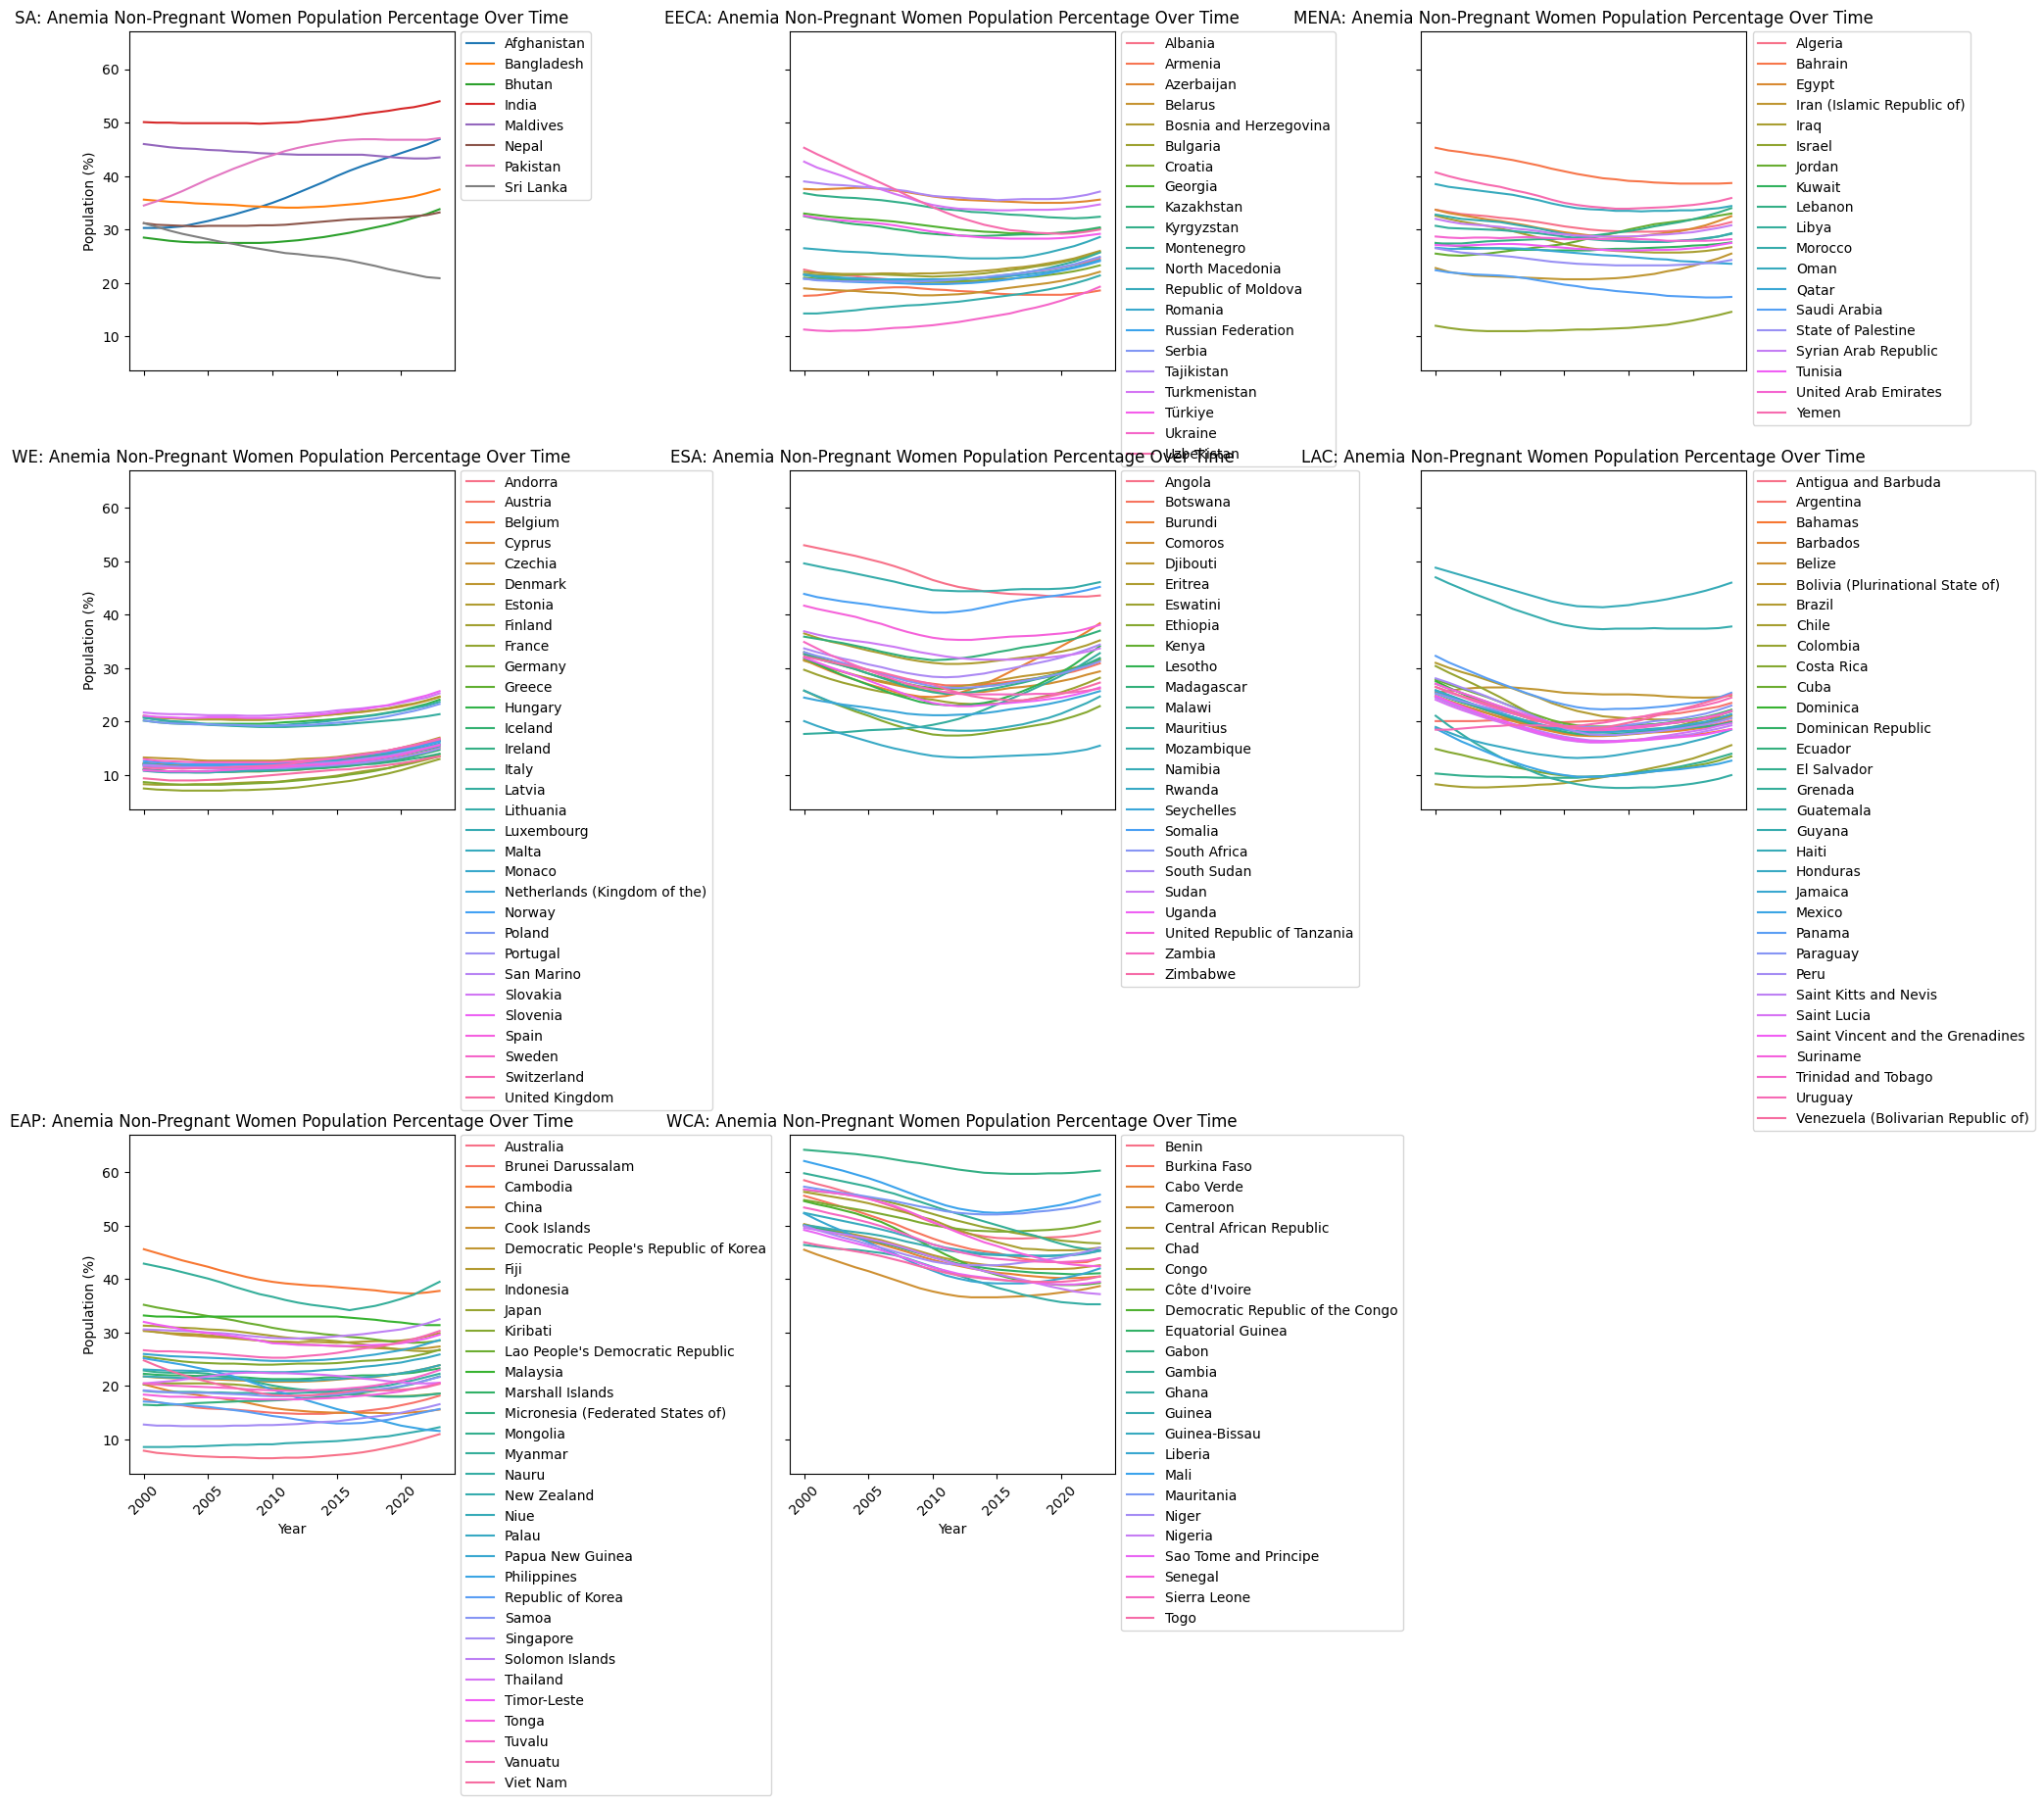

In [60]:
lineplot_viz(long_anaemia_nonpregnant_women_df, "Anemia Non-Pregnant Women")

## Countries of Highest Concern

Finding Countries of most concern:

**Indicator Score:**

For each indicator countries were flagged based on
whether or not they were in the 25% highest countries for that indicator and if the indicator failed to improve over time. Countries that improved were assigned 0 while countries that started high or worsened were assigned 1 and 2 respectively. The country's percentile was then added to calculate the country's score for that indicator.

My reasoning is that a country that is improving, even if it is the worst at that indicator in the dataset, is in less need of correction than a country who is worsening or failing to improve.

**Overall Concern Score:**

The overall concern score was found by taking a weighted average of four indicator scores; percent pregnant women anemia, percent childbearing age women anemia, percent women underweight, percent women overweight. (seen in 'show work' below)

Based on this Score the five worst countries are Burundi, Jordan, Somalia, Lesotho and Lebanon.

For each country I've ploted these four indicators overtime. I then checked the country's World Bank Income Group, UN Region, and UNICEF Region to find better performing countries whose policies we may be able to investigate to find recommendations for the countries who are struggling.

##### Show Work

In [61]:
data = {"Pregnant Anemia":anemia_pregnant_women_not_improved, "Childbearing Anemia":anemia_WRA_not_improved, "Underweight":underweight_not_improved, "Overweight":overweight_not_improved}

#rename columns
for tag, df in data.items():
  df.rename(columns={
      "Ending Estimate":f"{tag} Ending Estimate",
      "Percentage Point Change":f"{tag} Percentage Point Change",
      "Initially High":f"{tag} Initially High",
      "Condition": f"{tag} Condition",
      "Score":f"{tag} Score"
      }, inplace=True)
  data[tag] = df[["Country", f"{tag} Ending Estimate",f"{tag} Percentage Point Change",f"{tag} Initially High",f"{tag} Condition",f"{tag} Score"]]

country_info = long_overweight_df[["Country", "UNICEF Regions", "UN Regions", "World Bank Income Groups"]].drop_duplicates()

overall_concern_df = reduce(lambda left, right: pd.merge(left, right, on=["Country"], how="outer"),data.values())
overall_concern_df = pd.merge(overall_concern_df, country_info, how="left", on="Country")

overall_concern_df.head()

,Country,Pregnant Anemia Ending Estimate,Pregnant Anemia Percentage Point Change,Pregnant Anemia Initially High,Pregnant Anemia Condition,Pregnant Anemia Score,Childbearing Anemia Ending Estimate,Childbearing Anemia Percentage Point Change,Childbearing Anemia Initially High,Childbearing Anemia Condition,Childbearing Anemia Score,Underweight Ending Estimate,Underweight Percentage Point Change,Underweight Initially High,Underweight Condition,Underweight Score,Overweight Ending Estimate,Overweight Percentage Point Change,Overweight Initially High,Overweight Condition,Overweight Score,UNICEF Regions,UN Regions,World Bank Income Groups
0,Afghanistan,31.6,-7.0,False,Not flagged,0.623711,45.4,13.8,False,Worsened,2.917526,6.7,-14.1,True,Not flagged,0.737113,49.4,34.2,False,Worsened,2.337629,SA,Asia,Low Income
1,Albania,25.5,-2.9,False,Not flagged,0.396907,24.7,2.0,False,Worsened,2.466495,1.9,-0.2,False,Not flagged,0.139175,64.0,15.6,False,Worsened,2.628866,EECA,Europe,Upper Middle Income
2,Algeria,35.2,-0.9,False,Not flagged,0.721649,31.6,-2.3,False,Not flagged,0.690722,3.7,-3.4,False,Not flagged,0.548969,66.2,18.7,False,Worsened,2.701031,MENA,Africa,Upper Middle Income
3,Andorra,16.3,-4.7,False,Not flagged,0.105670,16.4,3.9,False,Worsened,2.159794,3.4,0.0,False,Not flagged,0.515464,44.7,2.9,False,Worsened,2.293814,WE,Europe,High Income
4,Angola,45.9,-6.4,True,Not flagged,0.891753,43.8,-9.1,True,Not flagged,0.902062,9.1,-2.9,True,Not flagged,0.827320,38.7,15.0,False,Worsened,2.229381,ESA,Africa,Lower Middle Income


In [62]:
weights = {
    "Pregnant Anemia Score": 4,
    "Childbearing Anemia Score": 3,
    "Underweight Score": 2,
    "Overweight Score": 1
}

weighted_total = pd.Series(0.0, index=overall_concern_df.index)
available_weight = pd.Series(0.0, index=overall_concern_df.index)
indicators_available = pd.Series(0, index=overall_concern_df.index)
flags_triggered = pd.Series(0, index=overall_concern_df.index)

for indicator, weight in weights.items():


    available = overall_concern_df[indicator].notna()

    weighted_total += (
        overall_concern_df[indicator].fillna(0) * weight
    )

    # Maximum indicator-concern score is 3
    available_weight += available.astype(int) * weight * 3
    indicators_available += available.astype(int)


overall_concern_df["Overall Concern Score"] = (
    weighted_total
    .div(available_weight)
    .mul(100)
)

overall_concern_df["Indicators Available"] = indicators_available

overall_concern_df = overall_concern_df.sort_values(
    "Overall Concern Score", ascending=False
)

overall_concern_df.head()

,Country,Pregnant Anemia Ending Estimate,Pregnant Anemia Percentage Point Change,Pregnant Anemia Initially High,Pregnant Anemia Condition,Pregnant Anemia Score,Childbearing Anemia Ending Estimate,Childbearing Anemia Percentage Point Change,Childbearing Anemia Initially High,Childbearing Anemia Condition,Childbearing Anemia Score,Underweight Ending Estimate,Underweight Percentage Point Change,Underweight Initially High,Underweight Condition,Underweight Score,Overweight Ending Estimate,Overweight Percentage Point Change,Overweight Initially High,Overweight Condition,Overweight Score,UNICEF Regions,UN Regions,World Bank Income Groups,Overall Concern Score,Indicators Available
27,Burundi,44.7,2.0,True,Worsened,2.865979,39.0,6.1,False,Worsened,2.845361,18.0,0.8,True,Worsened,2.963918,11.7,4.7,False,Worsened,2.005155,ESA,Africa,Low Income,93.109966,4
87,Jordan,33.3,2.2,False,Worsened,2.685567,33.0,7.1,False,Worsened,2.731959,3.3,1.1,False,Worsened,2.497423,69.9,5.6,True,Worsened,2.770619,MENA,Asia,Lower Middle Income,89.012027,4
160,Somalia,52.8,2.0,True,Worsened,2.953608,46.2,1.3,True,Worsened,2.943299,12.6,-1.5,True,Not flagged,0.927835,44.6,20.9,False,Worsened,2.286082,ESA,Africa,Low Income,82.620275,4
96,Lesotho,35.8,1.0,False,Worsened,2.747423,34.2,2.1,False,Worsened,2.757732,3.5,-1.1,False,Not flagged,0.530928,55.5,9.7,False,Worsened,2.458763,ESA,Africa,Lower Middle Income,75.945017,4
95,Lebanon,33.6,2.1,False,Worsened,2.690722,34.0,6.4,False,Worsened,2.750000,3.0,-0.3,False,Not flagged,0.422680,61.9,12.5,False,Worsened,2.600515,MENA,Asia,Lower Middle Income,74.862543,4


##### Country Overview Definition

In [63]:
def country_overview(country):
  country_concern_df = overall_concern_df[overall_concern_df["Country"] == country]
  summary_cols = ["Country"] + list(weights.keys()) + ["Overall Concern Score"]
  df = country_concern_df[summary_cols]
  display(df)

  key_indicators = {"Pregnant Anemia":long_anemia_pregnant_women_df, "Childbearing Anemia":long_anemia_WRA_df, "Underweight":long_underweight_df, "Overweight":long_overweight_df}
  ending_estimate_cols = [
    f"{indicator} Ending Estimate"
    for indicator in key_indicators.keys()
  ]
  percent_change_cols = [
    f"{indicator} Percentage Point Change"
    for indicator in key_indicators.keys()
  ]

  comparison_cols = ["Country"] + ending_estimate_cols + percent_change_cols + ["Overall Concern Score"]

  #ploting the four indicators over time
  fig, axes = plt.subplots(
      2, 2,
      figsize=(15, 10),
      sharex=True,
      sharey=True
  )

  for ax, (indicator, df) in zip(axes.flat, key_indicators.items()):

      country_df = (
          df.loc[df["Country"].eq(country)]
            .sort_values("year")
      )

      ax.plot(
          country_df["year"],
          country_df["Point Estimate"],
          color="darkblue",
          linewidth=2,
          label="Point Estimate"
      )

      ax.fill_between(
          country_df["year"],
          country_df["Lower Limit"],
          country_df["Upper Limit"],
          color="steelblue",
          alpha=0.25,
          label="Lower–Upper Estimate Range"
      )

      ax.set(
          title=indicator,
          xlabel="Year",
          ylabel="Percentage (%)",
          ylim=(0, 100)
      )

      ax.grid(alpha=0.3)
      ax.legend()

  fig.suptitle(
      f"Key Nutrition Indicators for {country} Over Time",
      fontsize=16,
      fontweight="bold"
  )

  plt.tight_layout(rect=[0, 0, 1, 0.95])
  plt.show()

  #showing ending percent values to compair against better performing countries in the same group
  display(country_concern_df[comparison_cols])

  #top 2 countries in the same World Bank Income Groups
  print("Better Performing Similar World Bank Income Group Countries")
  country_wb = country_df["World Bank Income Groups"].values[0]
  #print(country_wb)
  similar_world_bank = overall_concern_df[overall_concern_df["World Bank Income Groups"] == country_wb].sort_values("Overall Concern Score")[comparison_cols].head(2)
  display(similar_world_bank)
  #top 2 countries in the same UN Regions
  print("Better Performing Similar UN Regions Countries")
  country_un = country_df["UN Regions"].values[0]
  #print(country_un)
  similar_un = overall_concern_df[overall_concern_df["UN Regions"] == country_un].sort_values("Overall Concern Score")[comparison_cols].head(2)
  display(similar_un)

  #top 2 countries in the same UNICEF Regions
  print("Better Performing Similar UNICEF Regions Countries")
  country_unicef = country_df["UNICEF Regions"].values[0]
  #print(country_unicef)
  similar_unicef = overall_concern_df[overall_concern_df["UNICEF Regions"] == country_unicef].sort_values("Overall Concern Score")[comparison_cols].head(2)
  display(similar_unicef)

  #countries to investigate
  print()
  print()
  print("Countries to Investigate")
  investigate_countries = pd.concat([similar_world_bank, similar_un, similar_unicef]).drop_duplicates(keep="first")["Country"].tolist()
  print(investigate_countries)
  print()
  print()
  print()

  #ploting key indicators for each of the above countries over time
  for i_country in investigate_countries:
     fig, axes = plt.subplots(
      2, 2,
      figsize=(15, 10),
      sharex=True,
      sharey=True
      )

     for ax, (indicator, df) in zip(axes.flat, key_indicators.items()):

          i_country_df = (
              df.loc[df["Country"].eq(i_country)]
                .sort_values("year")
          )

          ax.plot(
              i_country_df["year"],
              i_country_df["Point Estimate"],
              color="darkblue",
              linewidth=2,
              label="Point Estimate"
          )

          ax.fill_between(
              i_country_df["year"],
              i_country_df["Lower Limit"],
              i_country_df["Upper Limit"],
              color="steelblue",
              alpha=0.25,
              label="Lower–Upper Estimate Range"
          )

          ax.set(
              title=indicator,
              xlabel="Year",
              ylabel="Percentage (%)",
              ylim=(0, 100)
          )

          ax.grid(alpha=0.3)
          ax.legend()


     fig.suptitle(
          f"Key Nutrition Indicators for {i_country} Over Time",
          fontsize=16,
          fontweight="bold"
      )

     plt.tight_layout(rect=[0, 0, 1, 0.95])
     plt.show()

## Country 1: Burundi

,Country,Pregnant Anemia Score,Childbearing Anemia Score,Underweight Score,Overweight Score,Overall Concern Score
27,Burundi,2.865979,2.845361,2.963918,2.005155,93.109966


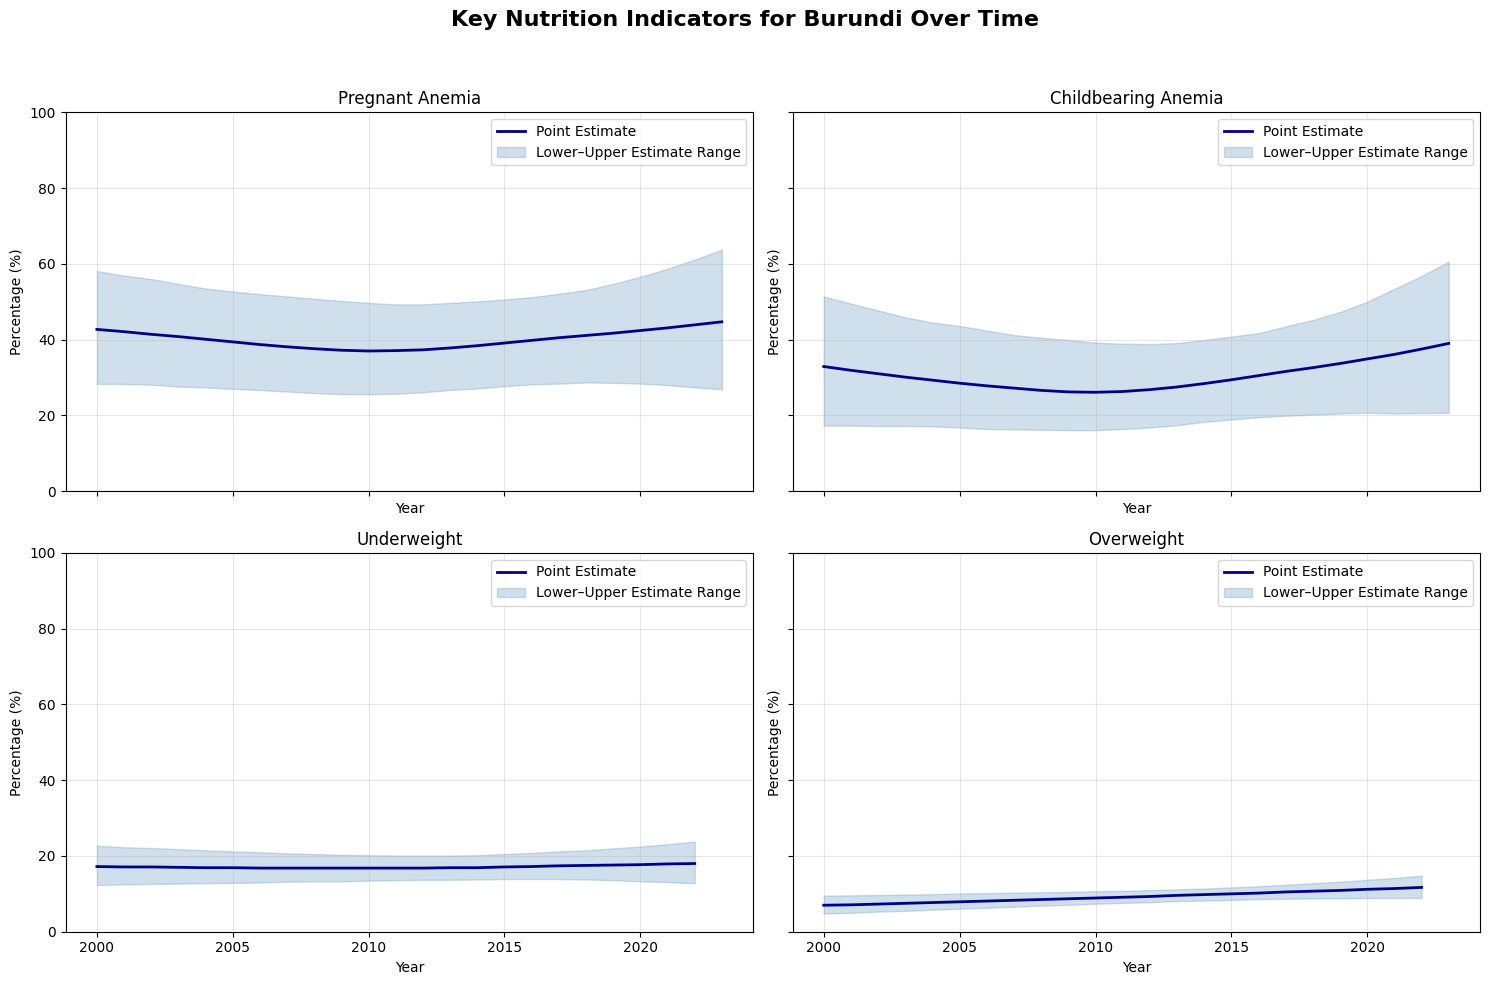

,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
27,Burundi,44.7,39.0,18.0,11.7,2.0,6.1,0.8,4.7,93.109966


Better Performing Similar World Bank Income Group Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
144,Rwanda,23.9,16.1,6.5,27.8,-5.9,-5.0,-1.9,15.0,16.288660
59,Ethiopia,26.2,23.1,21.0,13.7,-6.7,-3.6,-4.7,8.6,23.024055


Better Performing Similar UN Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
144,Rwanda,23.9,16.1,6.5,27.8,-5.9,-5.0,-1.9,15.0,16.288660
59,Ethiopia,26.2,23.1,21.0,13.7,-6.7,-3.6,-4.7,8.6,23.024055


Better Performing Similar UNICEF Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
144,Rwanda,23.9,16.1,6.5,27.8,-5.9,-5.0,-1.9,15.0,16.288660
59,Ethiopia,26.2,23.1,21.0,13.7,-6.7,-3.6,-4.7,8.6,23.024055




Countries to Investigate
['Rwanda', 'Ethiopia']





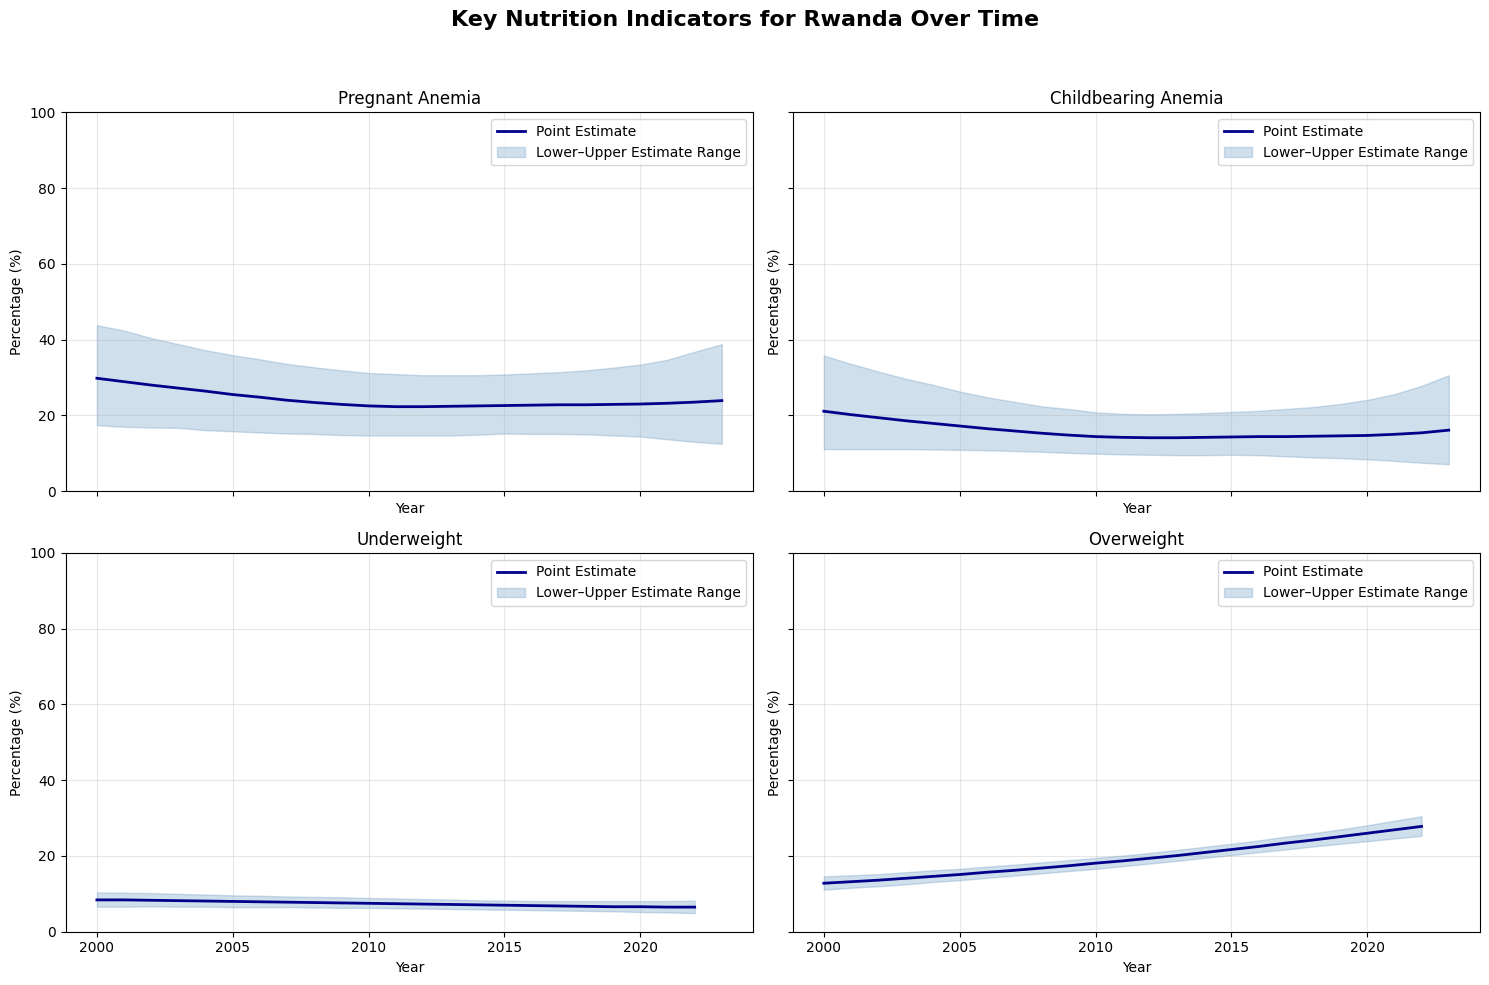

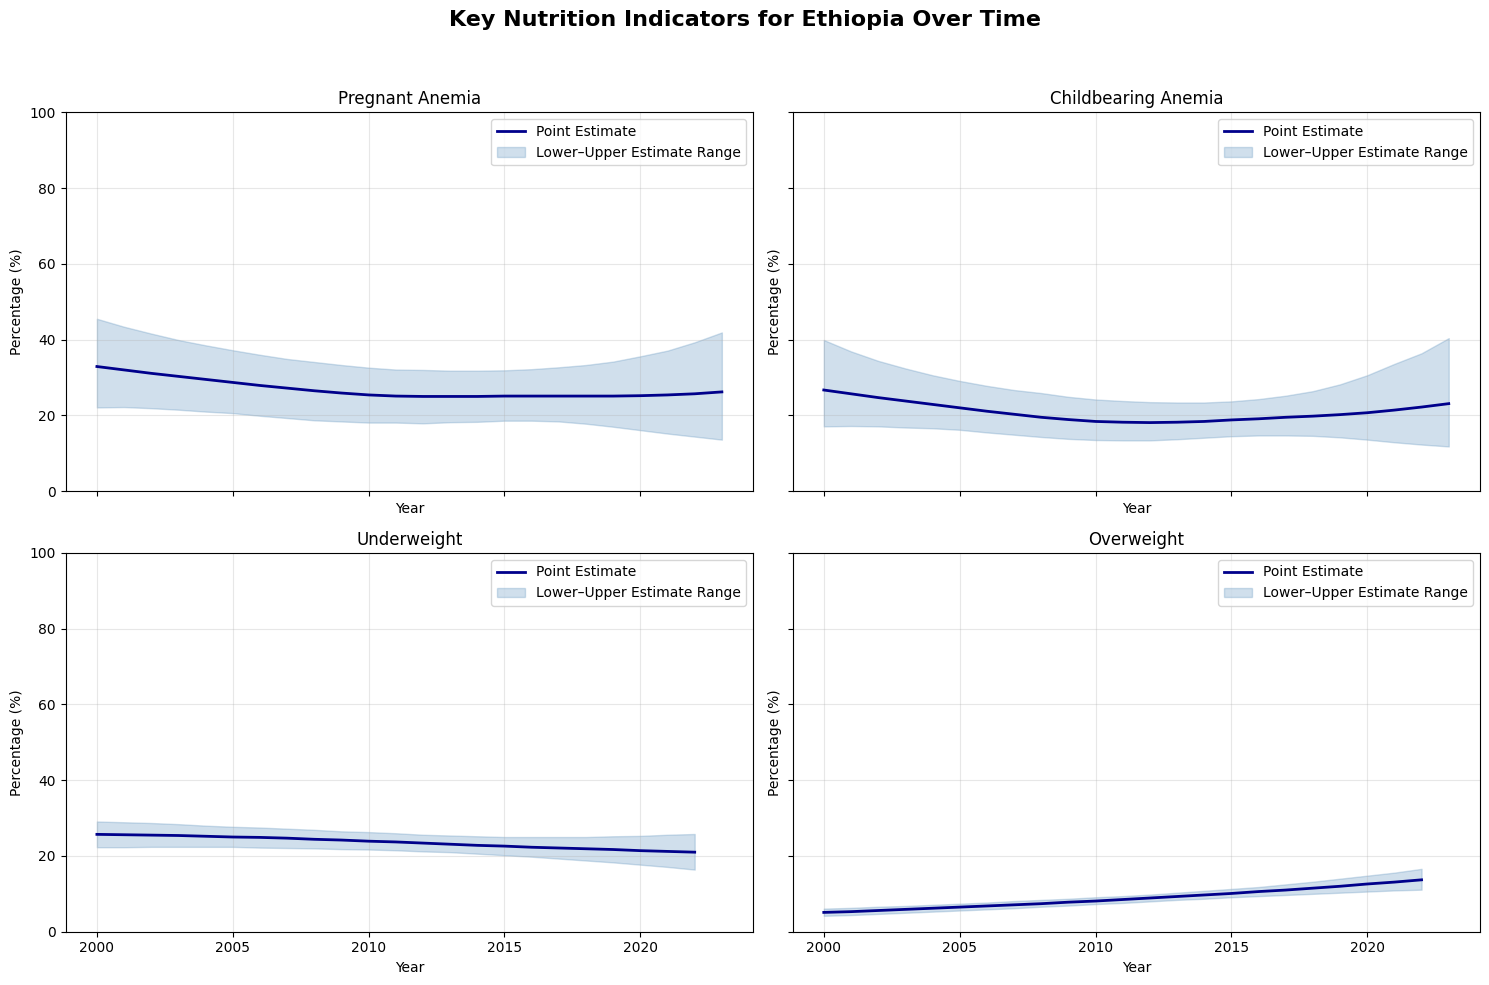

In [64]:
country_overview("Burundi")

## Country 2: Jordan

,Country,Pregnant Anemia Score,Childbearing Anemia Score,Underweight Score,Overweight Score,Overall Concern Score
87,Jordan,2.685567,2.731959,2.497423,2.770619,89.012027


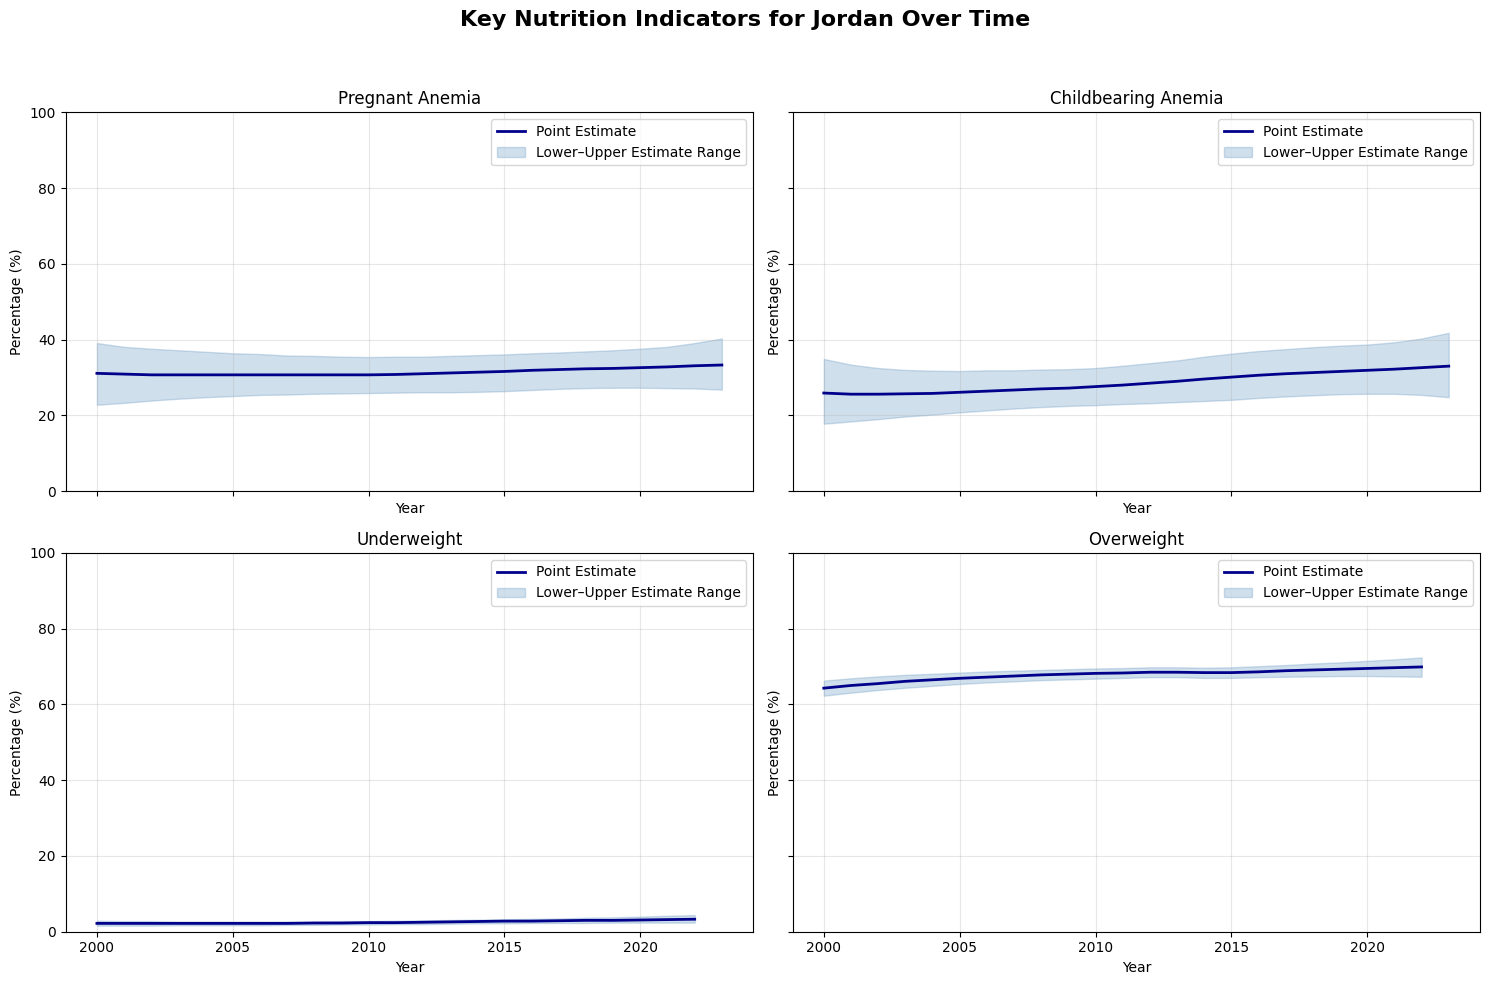

,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
87,Jordan,33.3,33.0,3.3,69.9,2.2,7.1,1.1,5.6,89.012027


Better Performing Similar World Bank Income Group Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
136,Philippines,24.0,12.0,10.3,37.2,-18.3,-14.5,-5.7,15.2,16.348797
75,Honduras,24.8,18.8,3.0,68.2,-3.9,-1.1,-1.8,26.2,18.384880


Better Performing Similar UN Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
35,China,14.2,15.6,5.3,34.4,-14.5,-5.0,-3.8,14.7,12.972509
140,Republic of Korea,15.9,15.7,6.2,28.8,-10.2,-1.7,0.4,3.8,14.115120


Better Performing Similar UNICEF Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
139,Qatar,24.9,23.6,2.5,77.8,-3.9,-3.1,-0.8,14.5,20.257732
91,Kuwait,28.5,27.7,1.1,81.7,-1.0,0.1,-0.6,9.8,23.152921




Countries to Investigate
['Philippines', 'Honduras', 'China', 'Republic of Korea', 'Qatar', 'Kuwait']





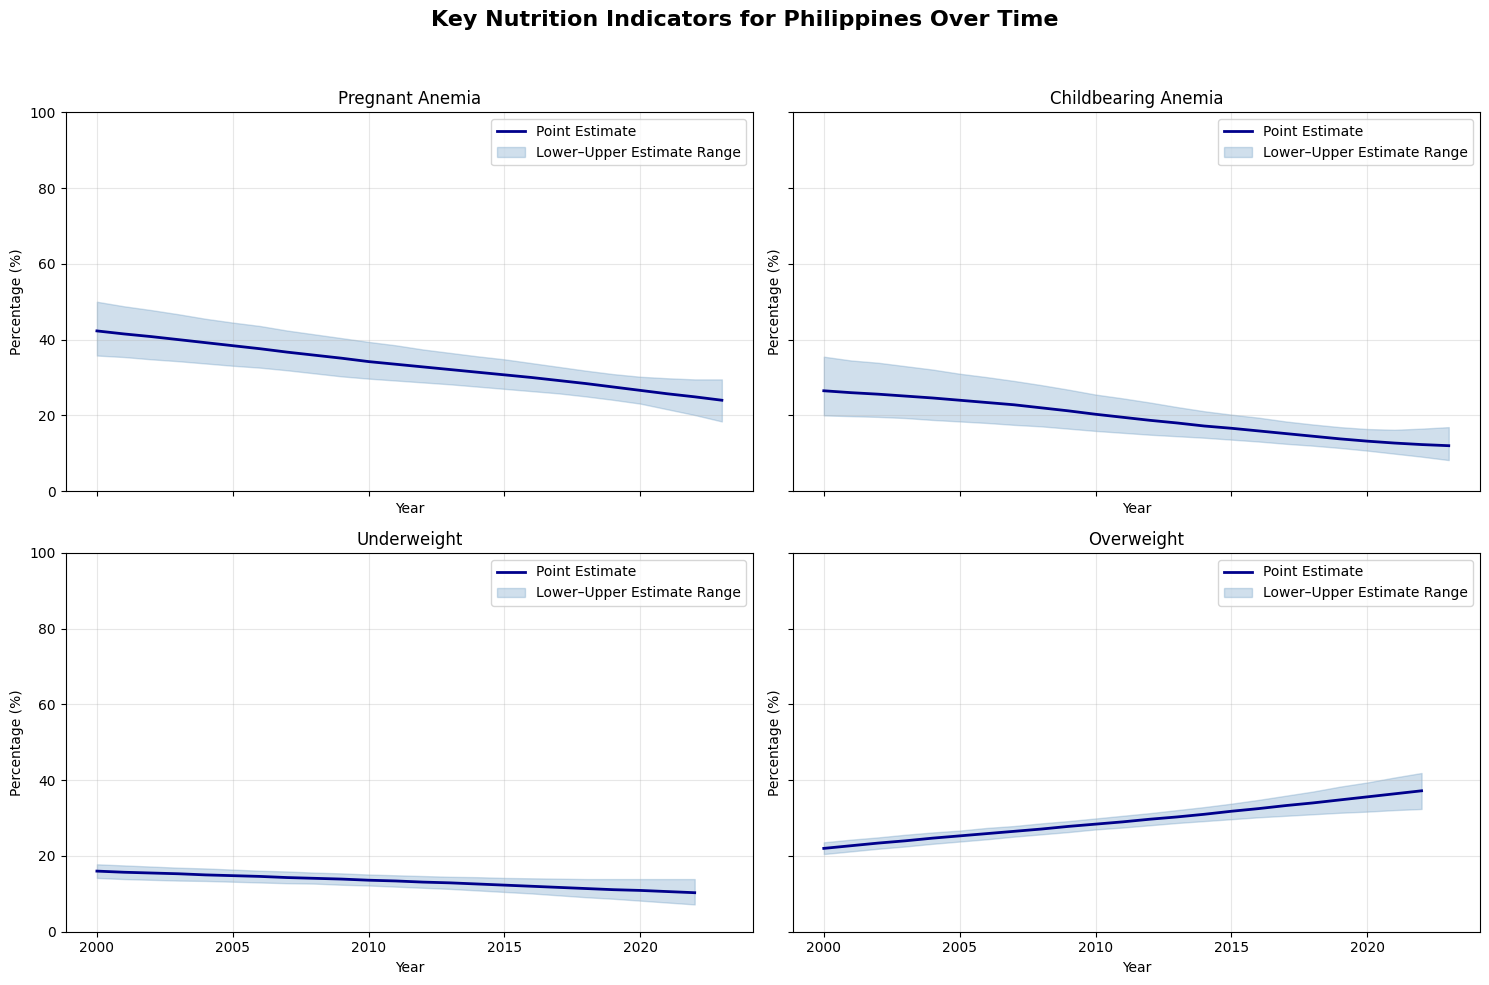

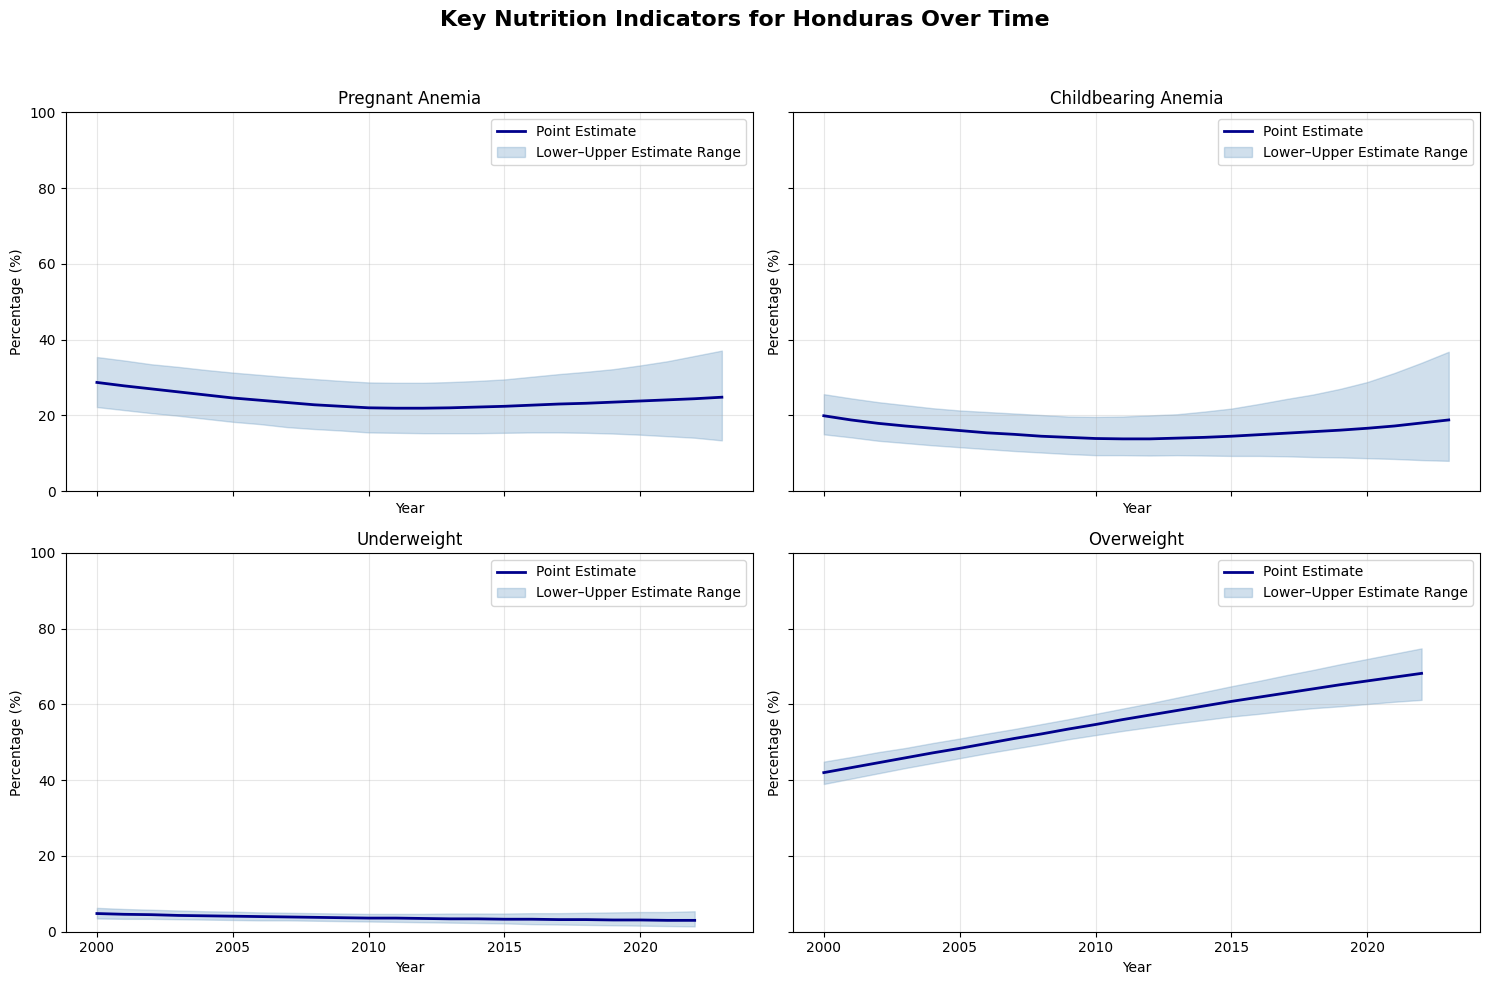

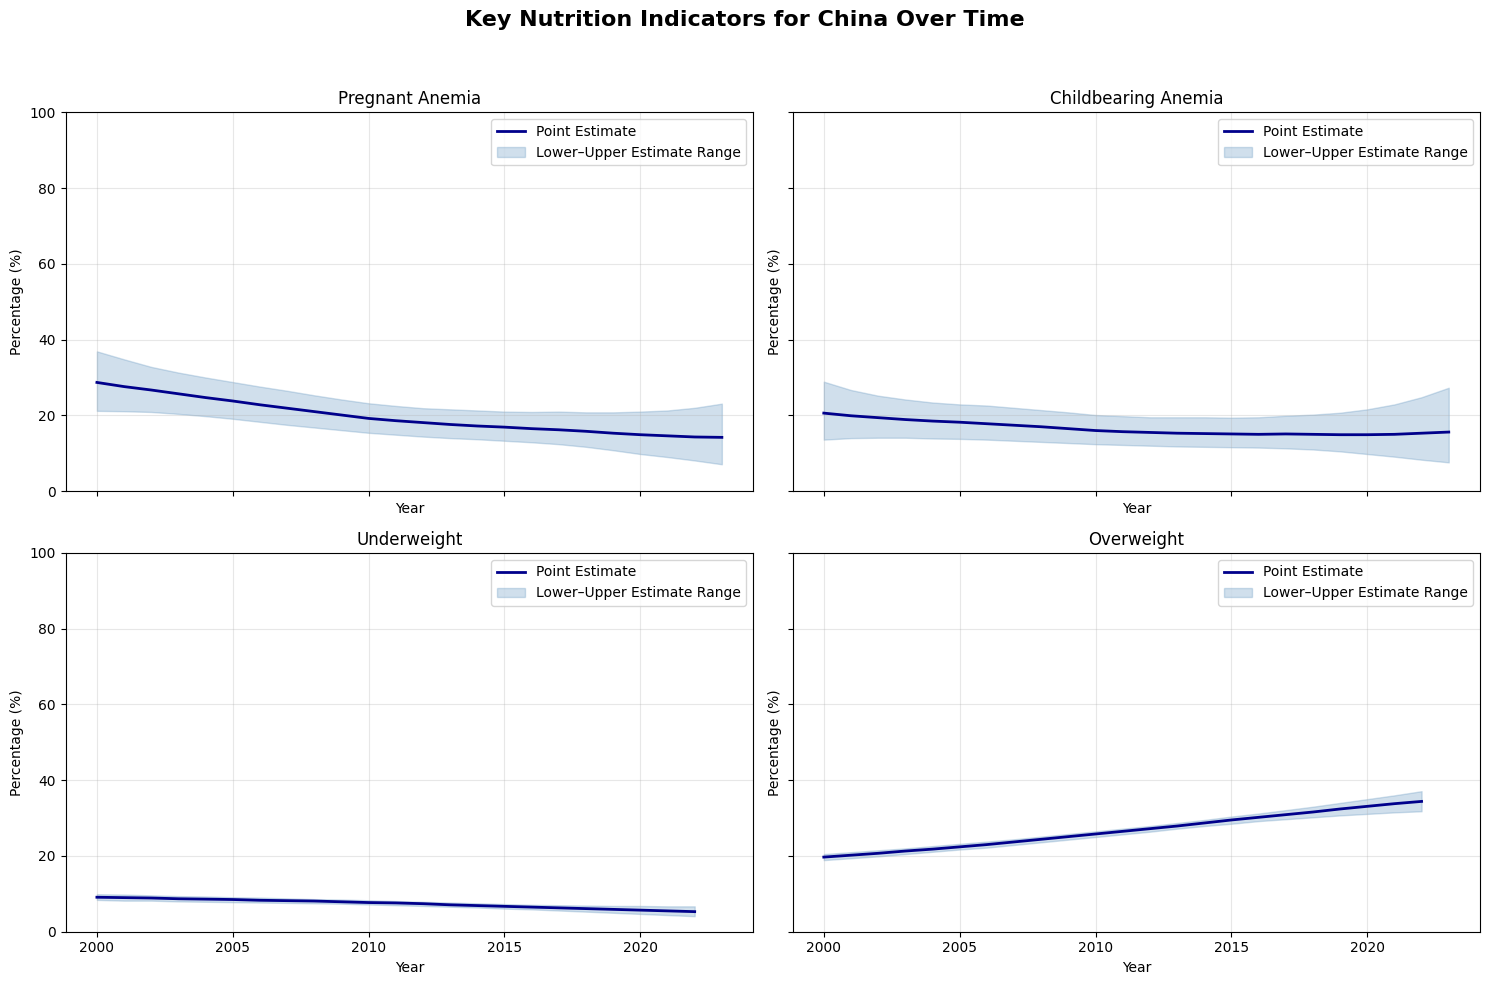

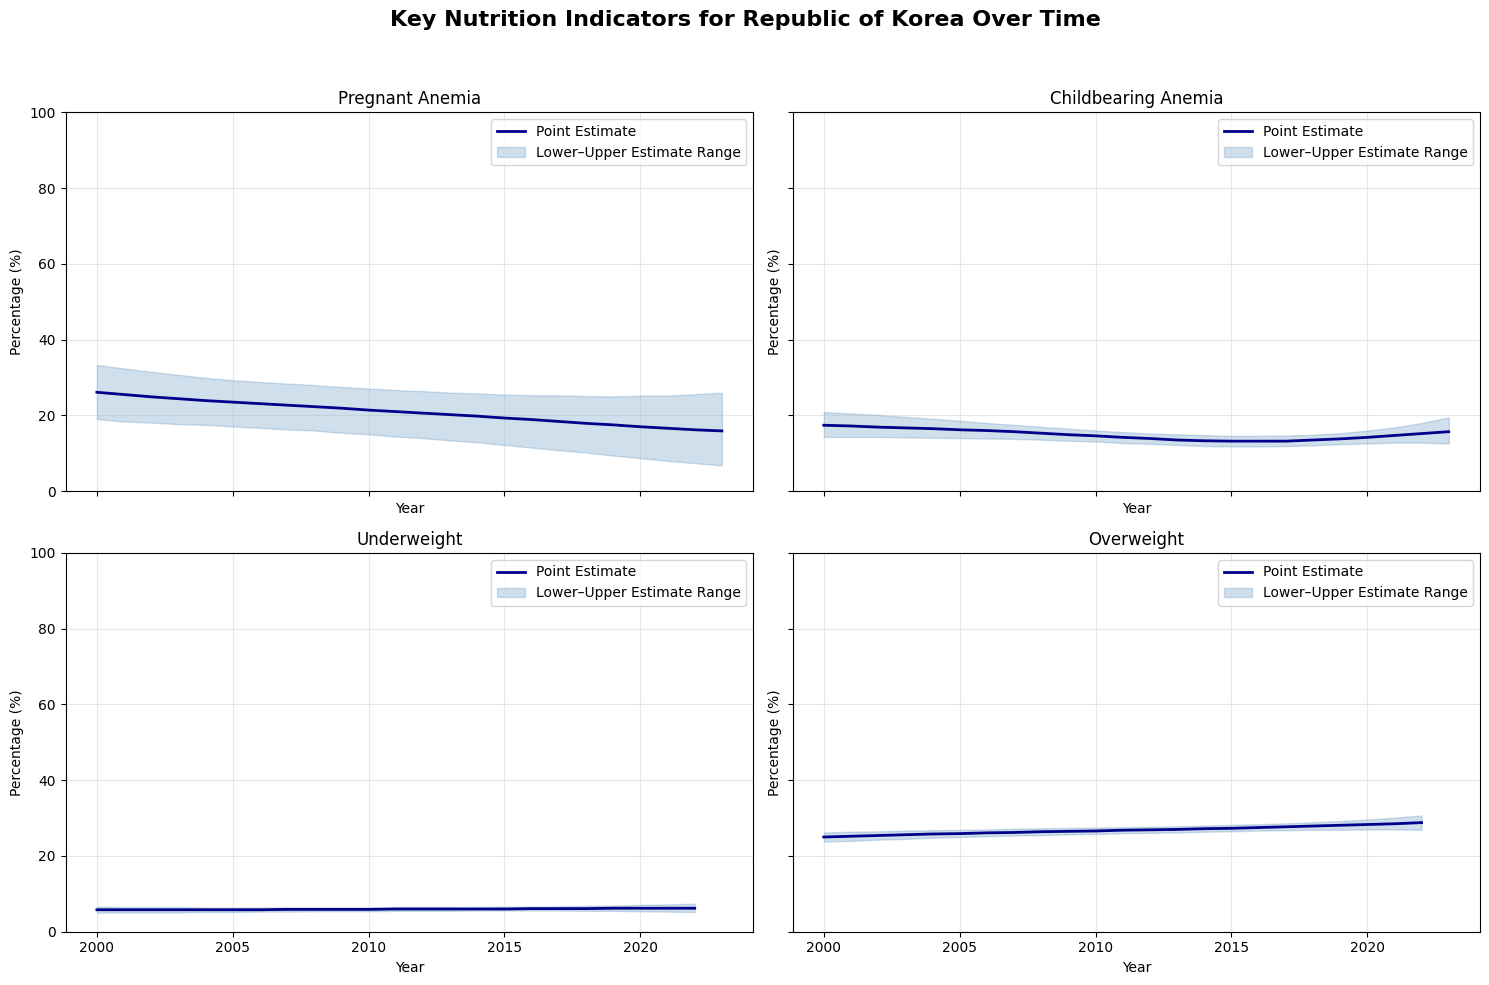

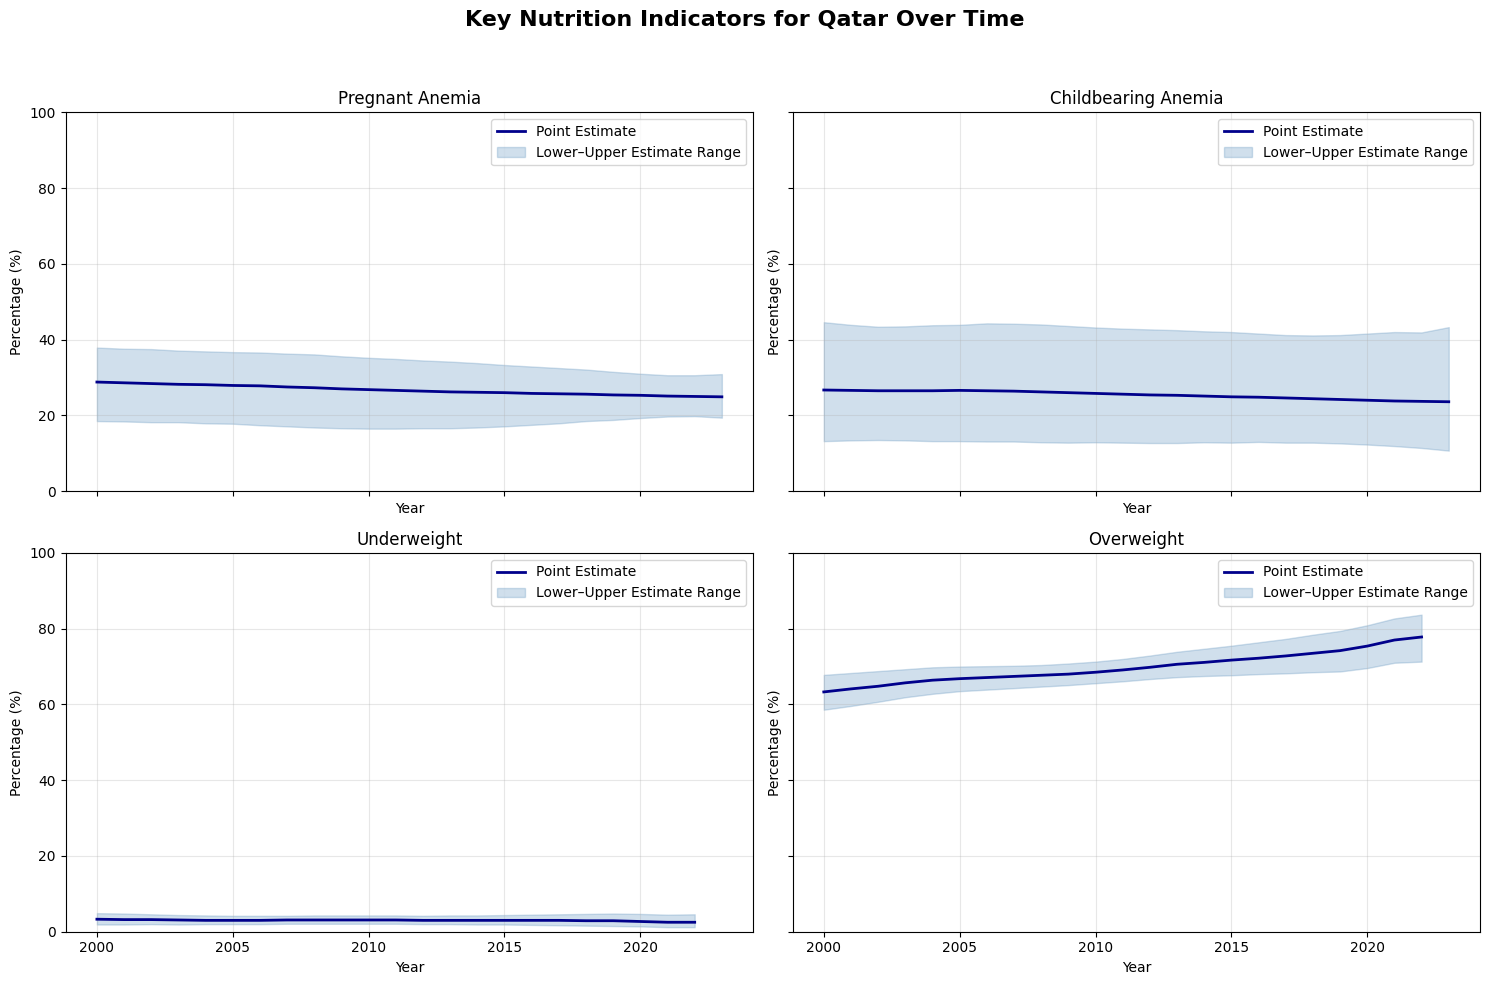

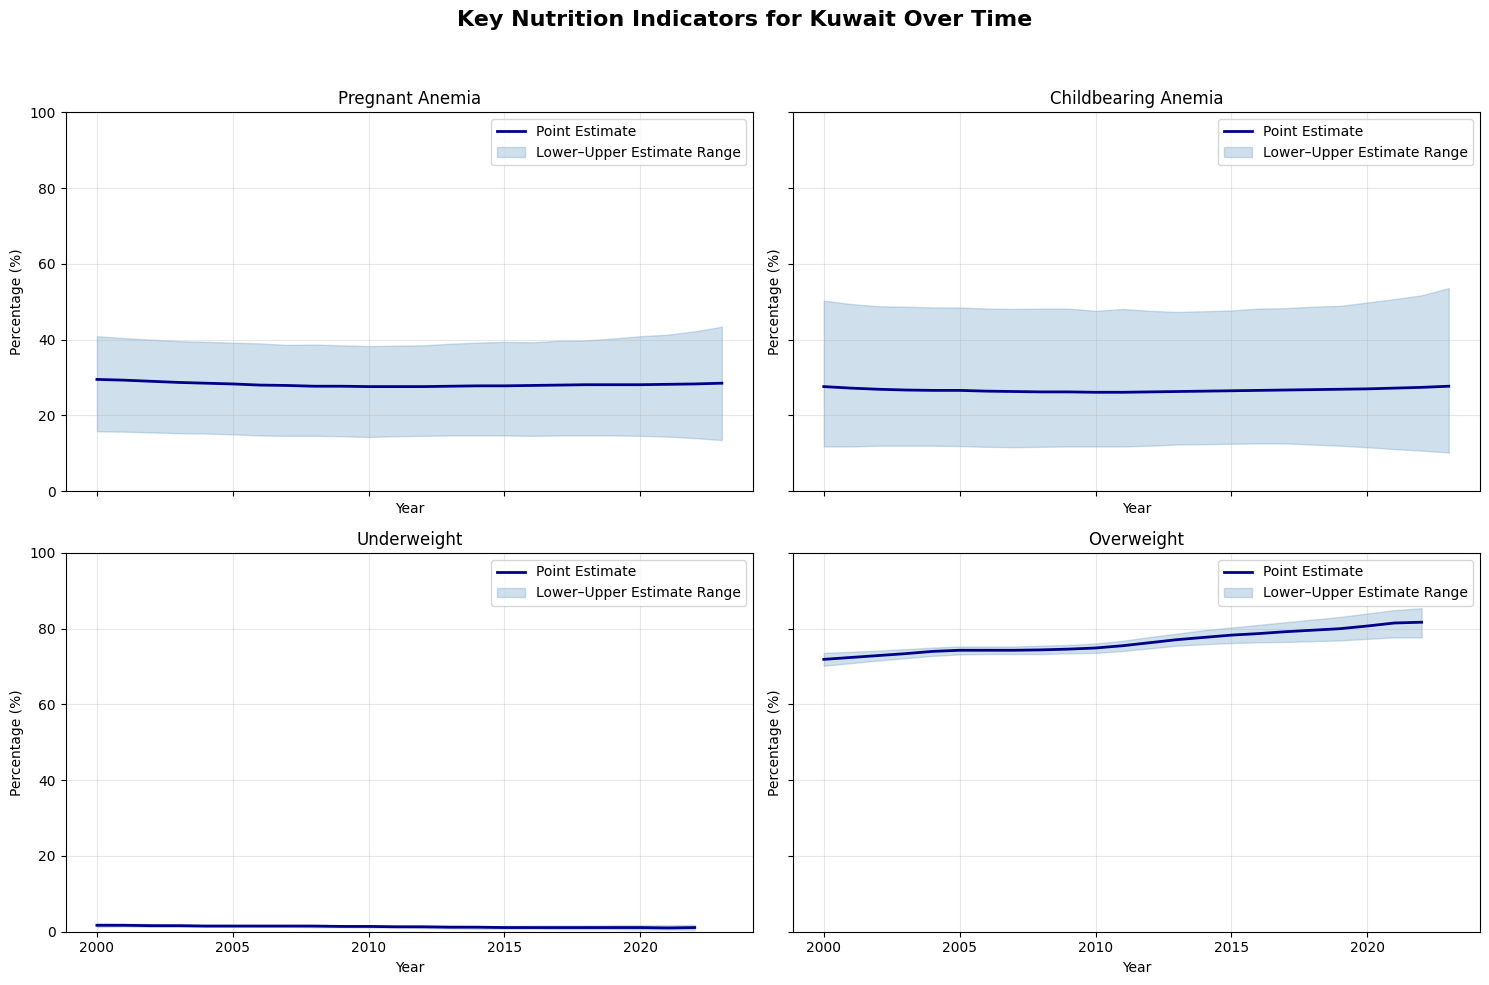

In [65]:
country_overview("Jordan")

## Country 3: Somalia

,Country,Pregnant Anemia Score,Childbearing Anemia Score,Underweight Score,Overweight Score,Overall Concern Score
160,Somalia,2.953608,2.943299,0.927835,2.286082,82.620275


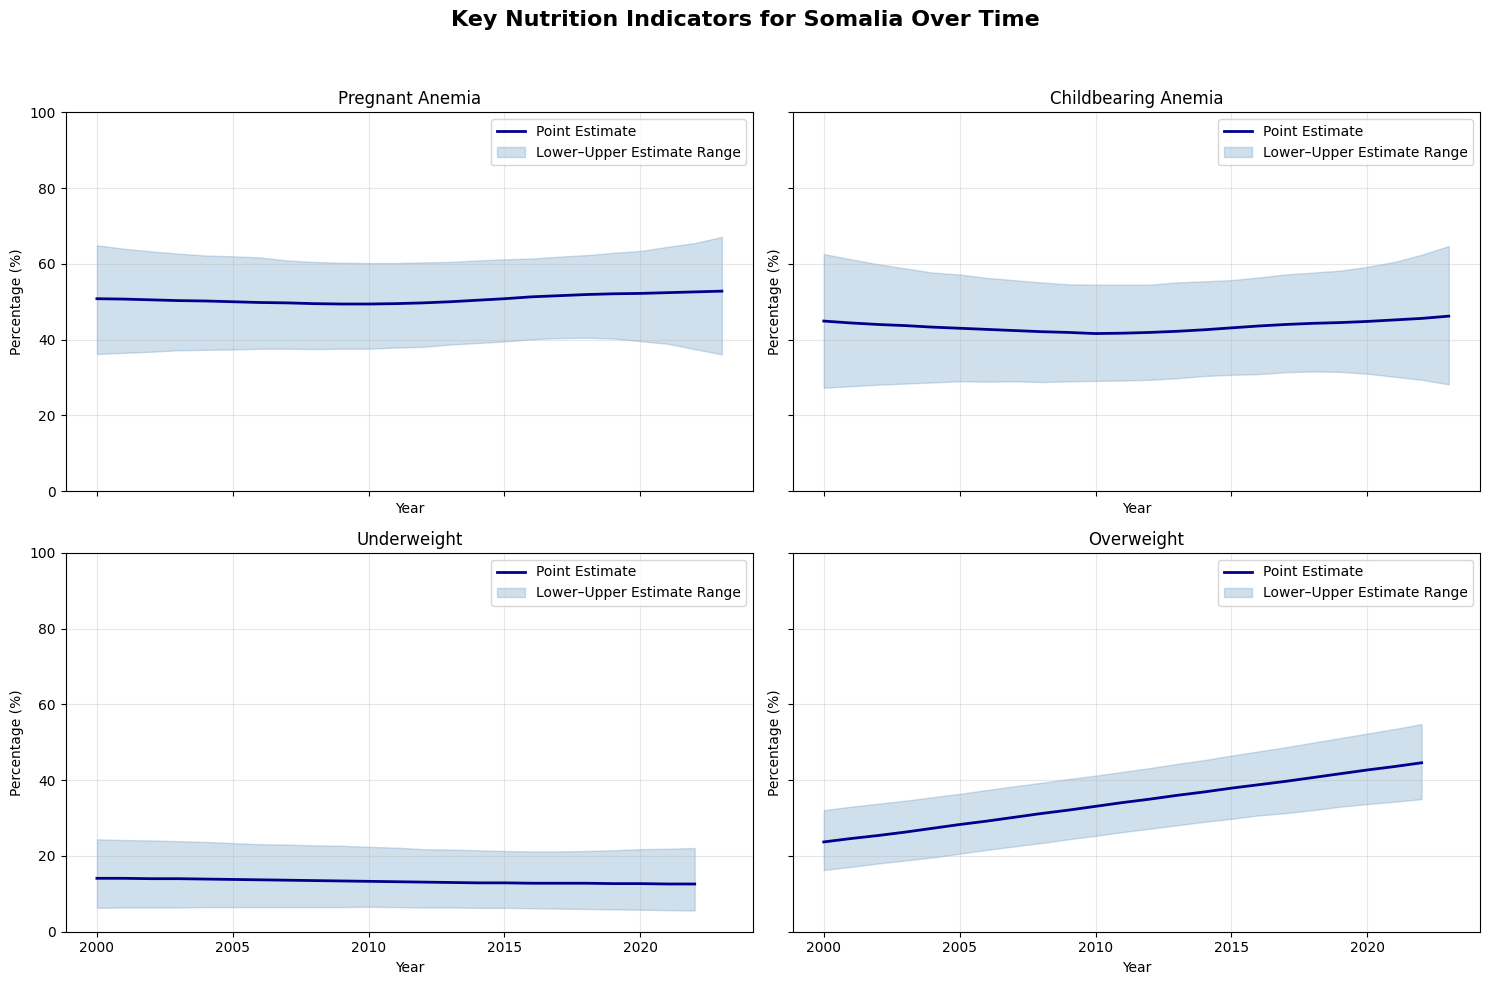

,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
160,Somalia,52.8,46.2,12.6,44.6,2.0,1.3,-1.5,20.9,82.620275


Better Performing Similar World Bank Income Group Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
144,Rwanda,23.9,16.1,6.5,27.8,-5.9,-5.0,-1.9,15.0,16.288660
59,Ethiopia,26.2,23.1,21.0,13.7,-6.7,-3.6,-4.7,8.6,23.024055


Better Performing Similar UN Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
144,Rwanda,23.9,16.1,6.5,27.8,-5.9,-5.0,-1.9,15.0,16.288660
59,Ethiopia,26.2,23.1,21.0,13.7,-6.7,-3.6,-4.7,8.6,23.024055


Better Performing Similar UNICEF Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
144,Rwanda,23.9,16.1,6.5,27.8,-5.9,-5.0,-1.9,15.0,16.288660
59,Ethiopia,26.2,23.1,21.0,13.7,-6.7,-3.6,-4.7,8.6,23.024055




Countries to Investigate
['Rwanda', 'Ethiopia']





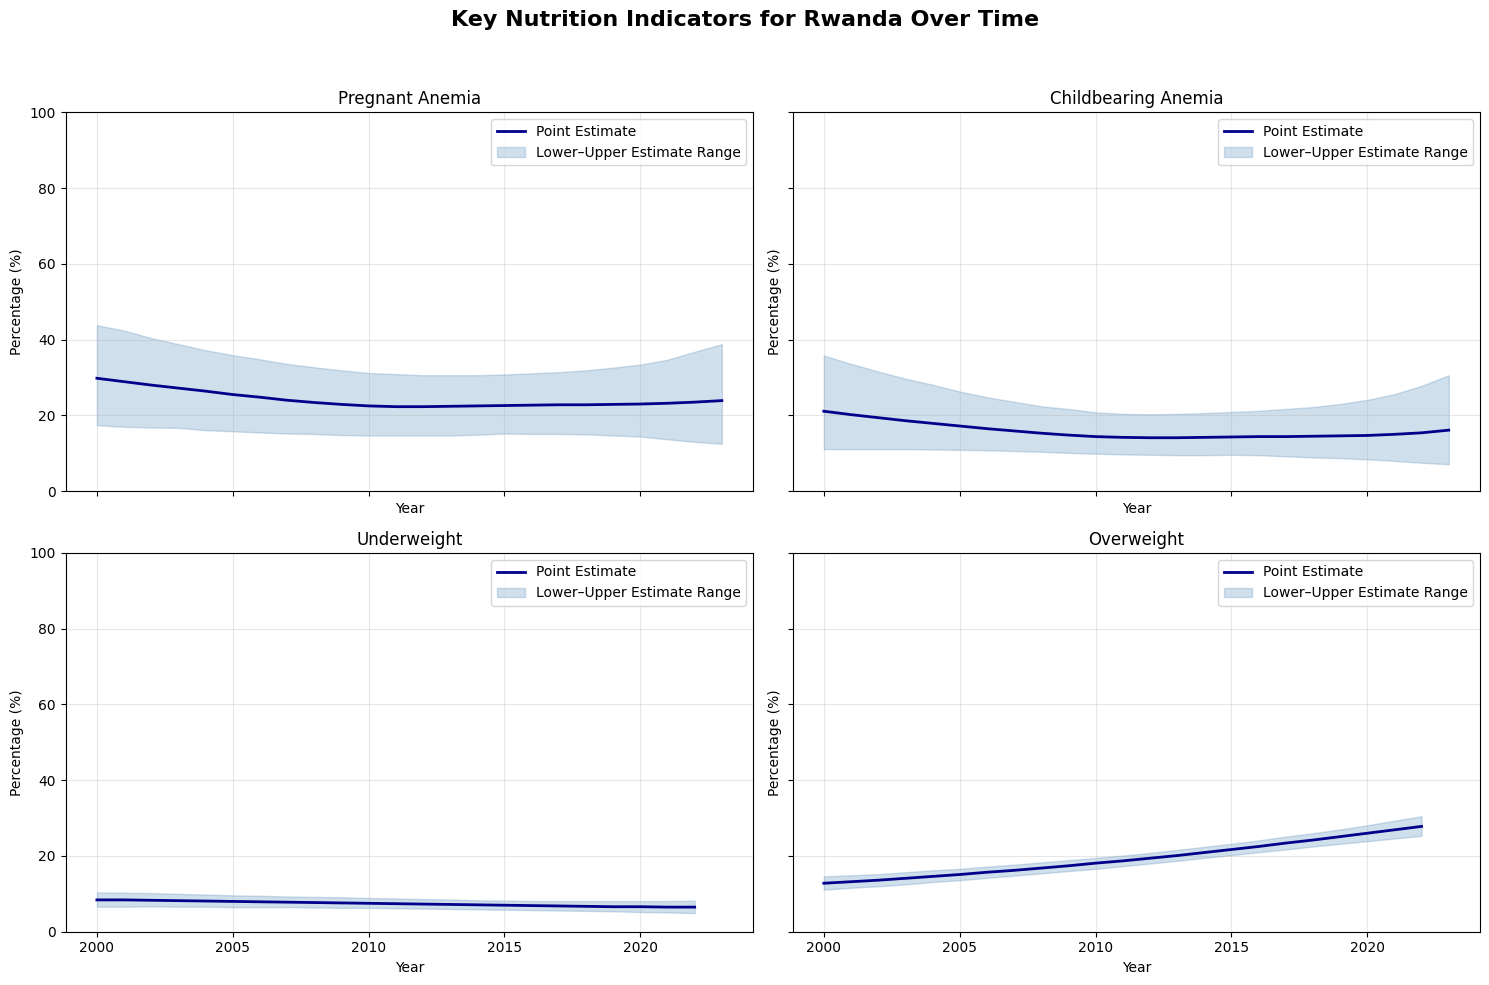

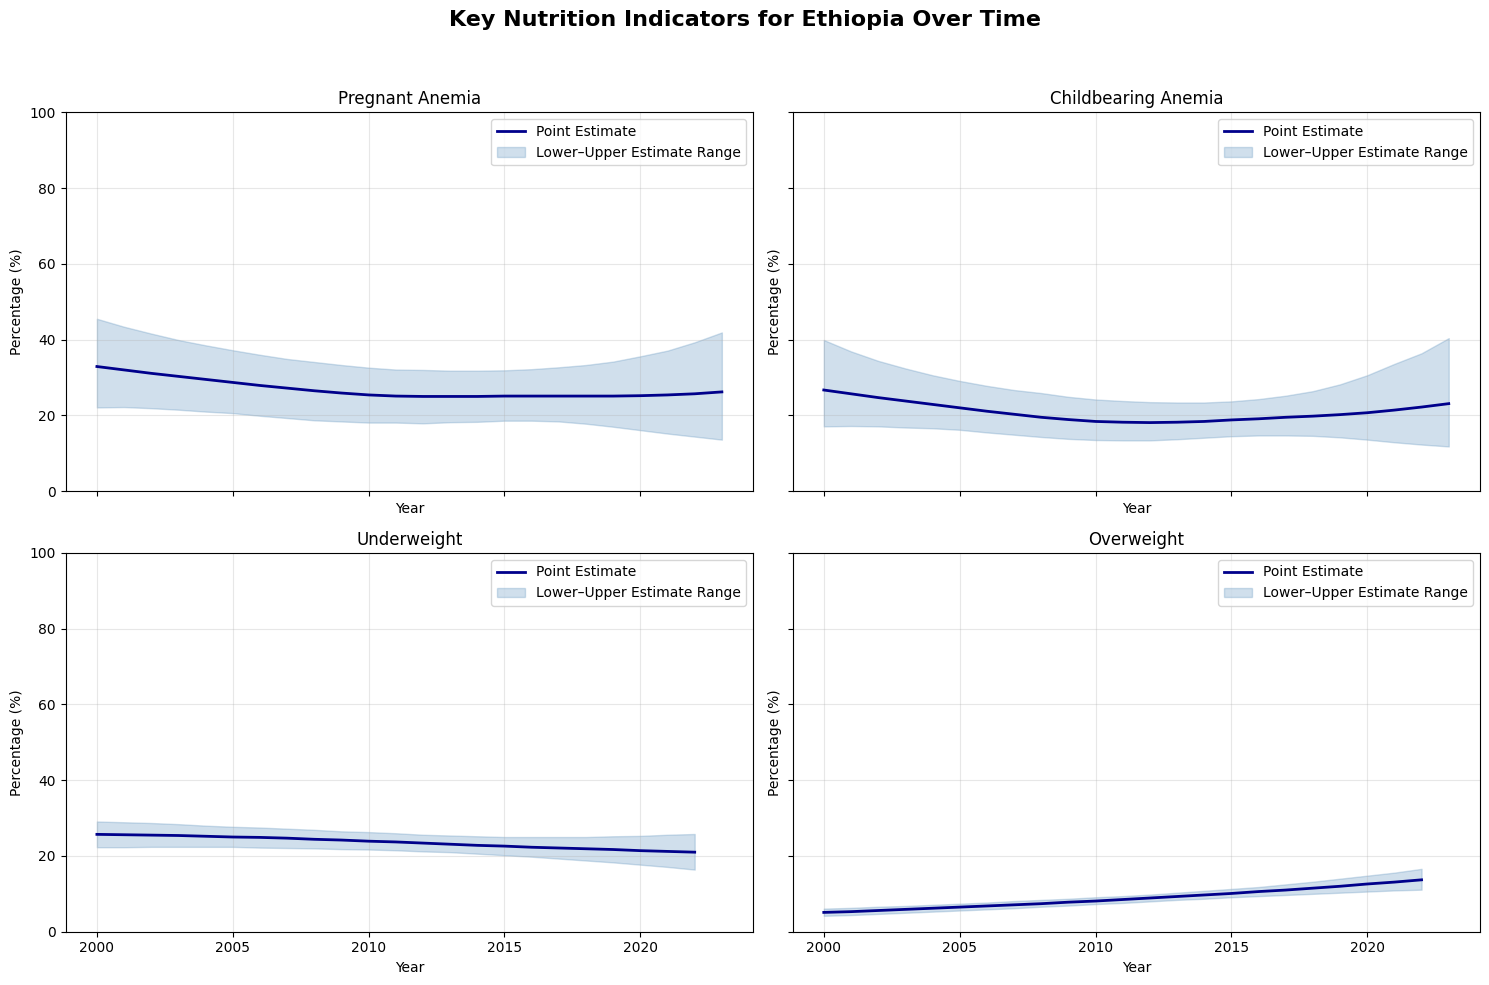

In [66]:
country_overview("Somalia")

## Country 4: Lesotho

,Country,Pregnant Anemia Score,Childbearing Anemia Score,Underweight Score,Overweight Score,Overall Concern Score
96,Lesotho,2.747423,2.757732,0.530928,2.458763,75.945017


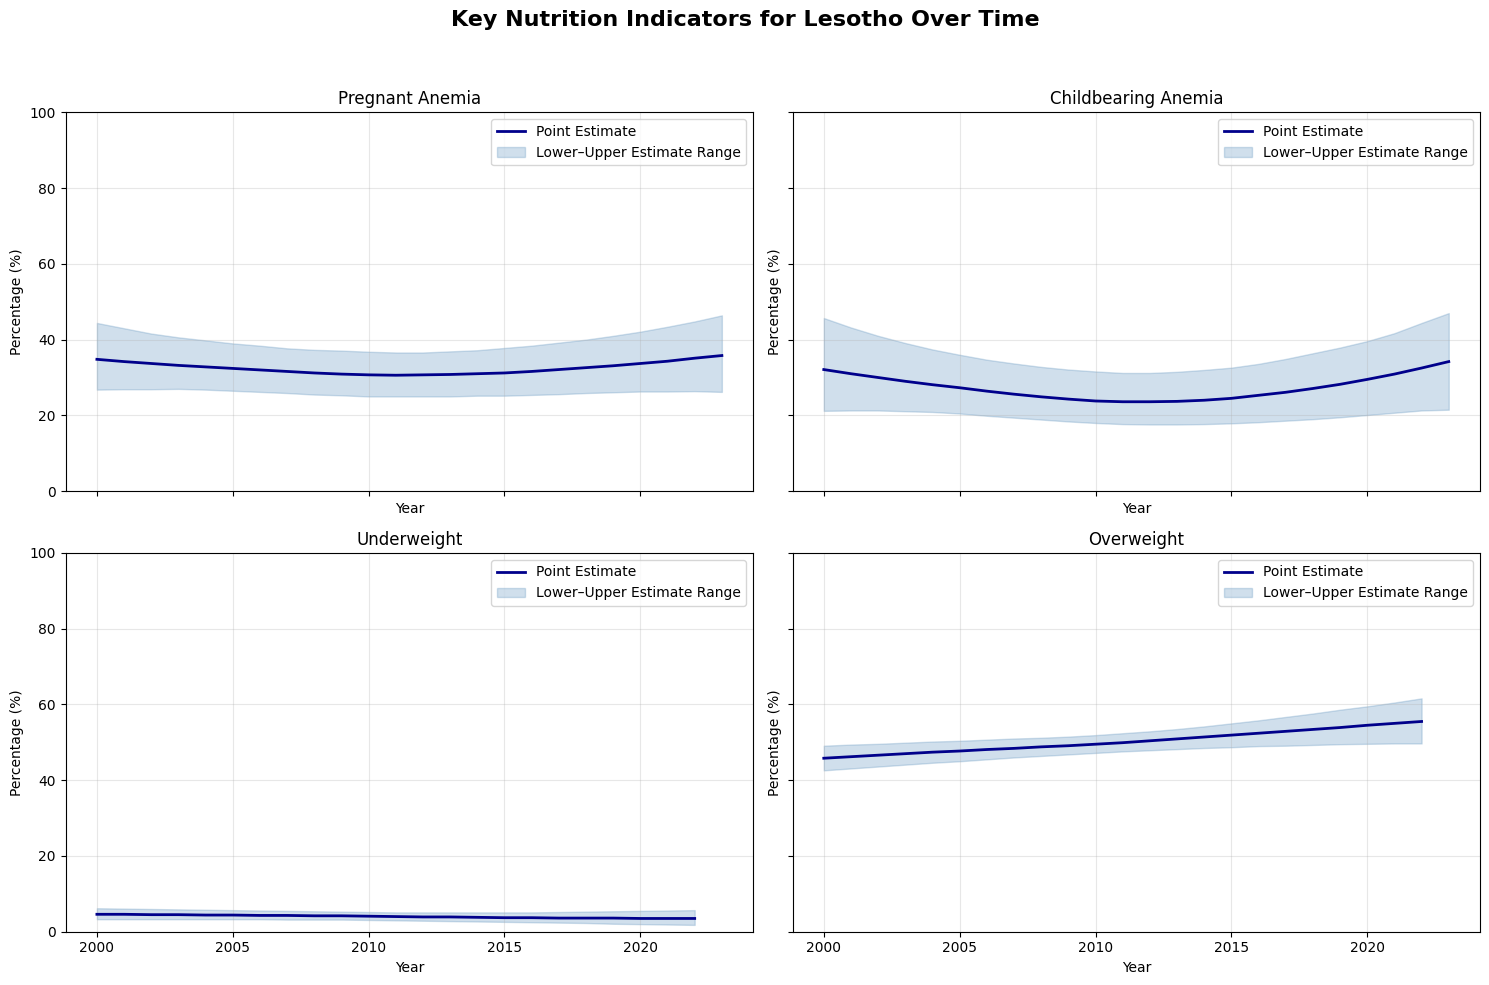

,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
96,Lesotho,35.8,34.2,3.5,55.5,1.0,2.1,-1.1,9.7,75.945017


Better Performing Similar World Bank Income Group Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
136,Philippines,24.0,12.0,10.3,37.2,-18.3,-14.5,-5.7,15.2,16.348797
75,Honduras,24.8,18.8,3.0,68.2,-3.9,-1.1,-1.8,26.2,18.384880


Better Performing Similar UN Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
144,Rwanda,23.9,16.1,6.5,27.8,-5.9,-5.0,-1.9,15.0,16.288660
59,Ethiopia,26.2,23.1,21.0,13.7,-6.7,-3.6,-4.7,8.6,23.024055


Better Performing Similar UNICEF Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
144,Rwanda,23.9,16.1,6.5,27.8,-5.9,-5.0,-1.9,15.0,16.288660
59,Ethiopia,26.2,23.1,21.0,13.7,-6.7,-3.6,-4.7,8.6,23.024055




Countries to Investigate
['Philippines', 'Honduras', 'Rwanda', 'Ethiopia']





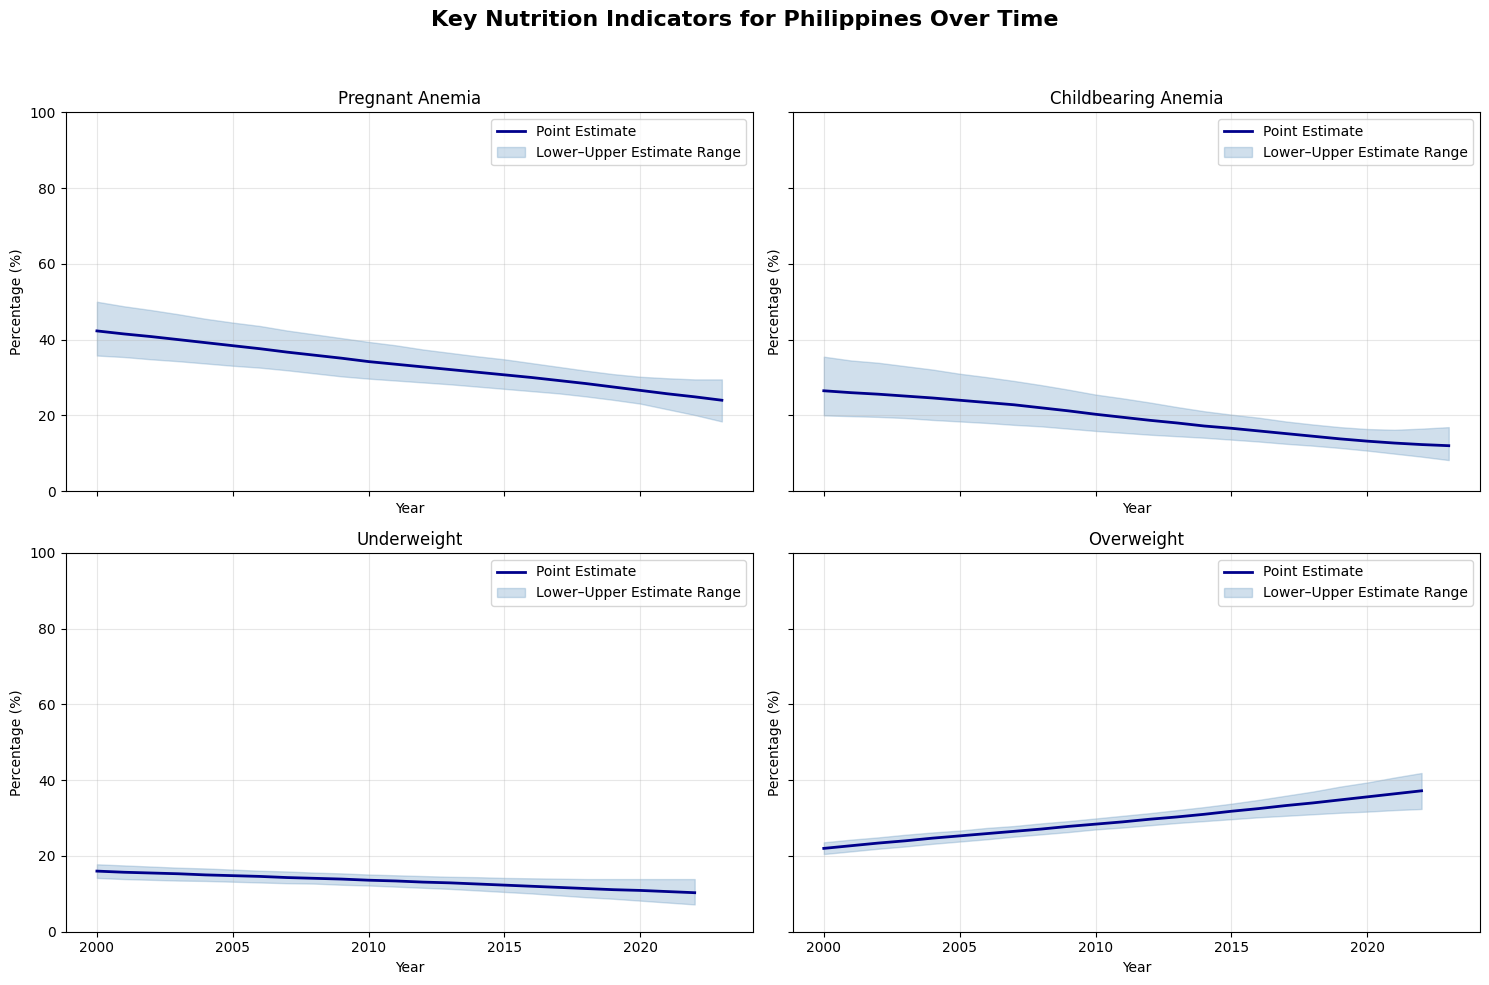

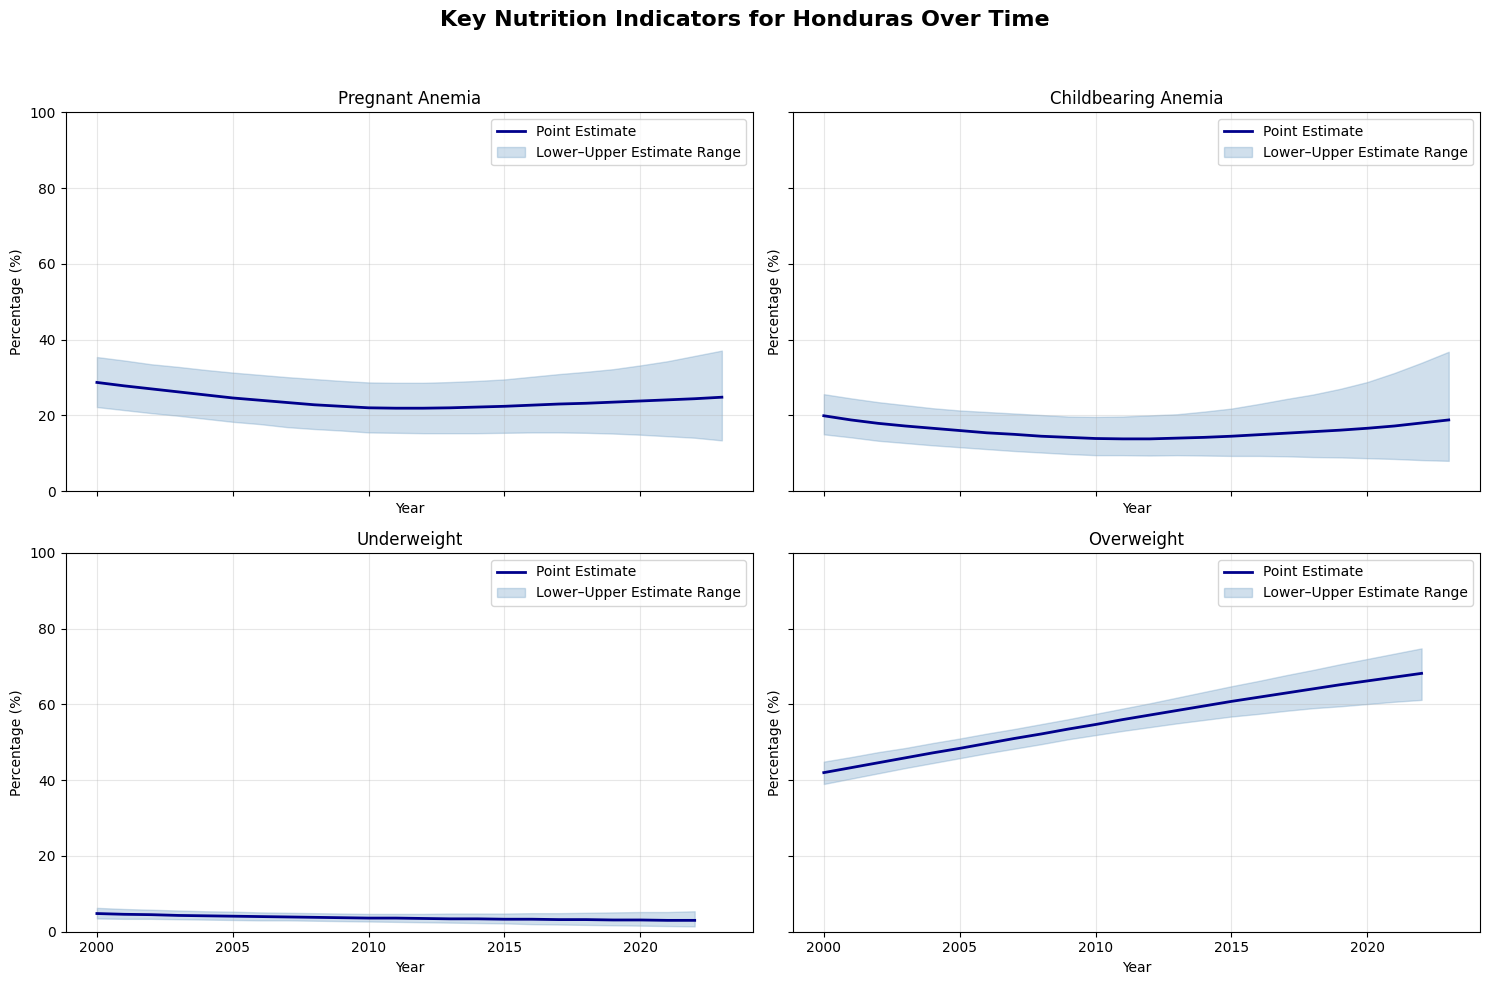

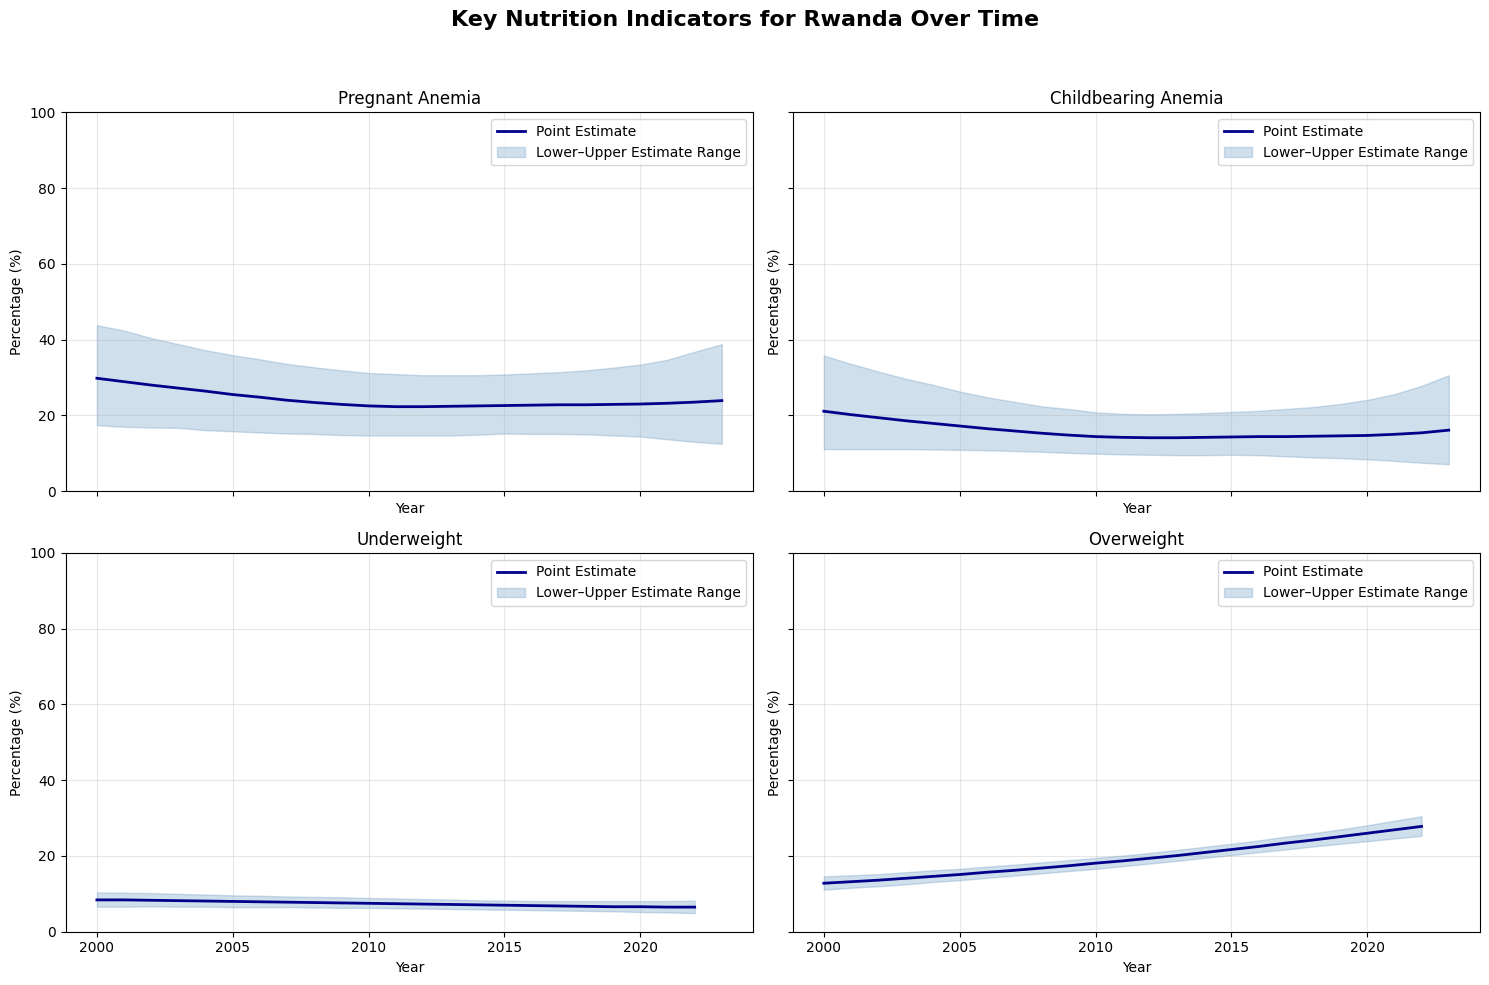

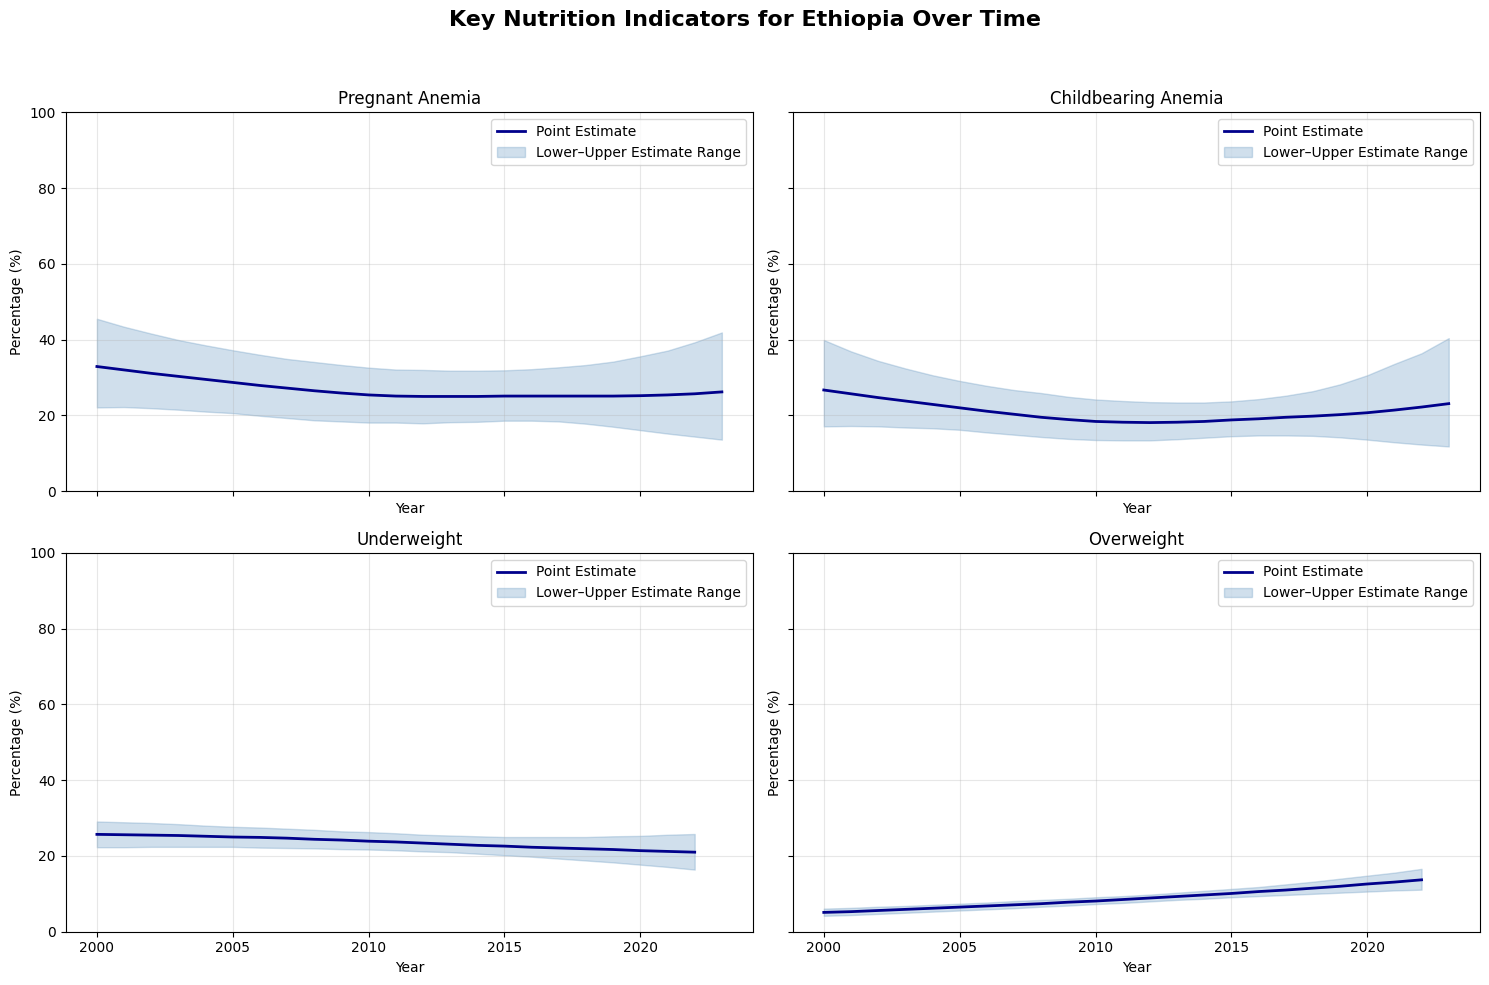

In [67]:
country_overview("Lesotho")

## Country 5: Lebanon

,Country,Pregnant Anemia Score,Childbearing Anemia Score,Underweight Score,Overweight Score,Overall Concern Score
95,Lebanon,2.690722,2.75,0.42268,2.600515,74.862543


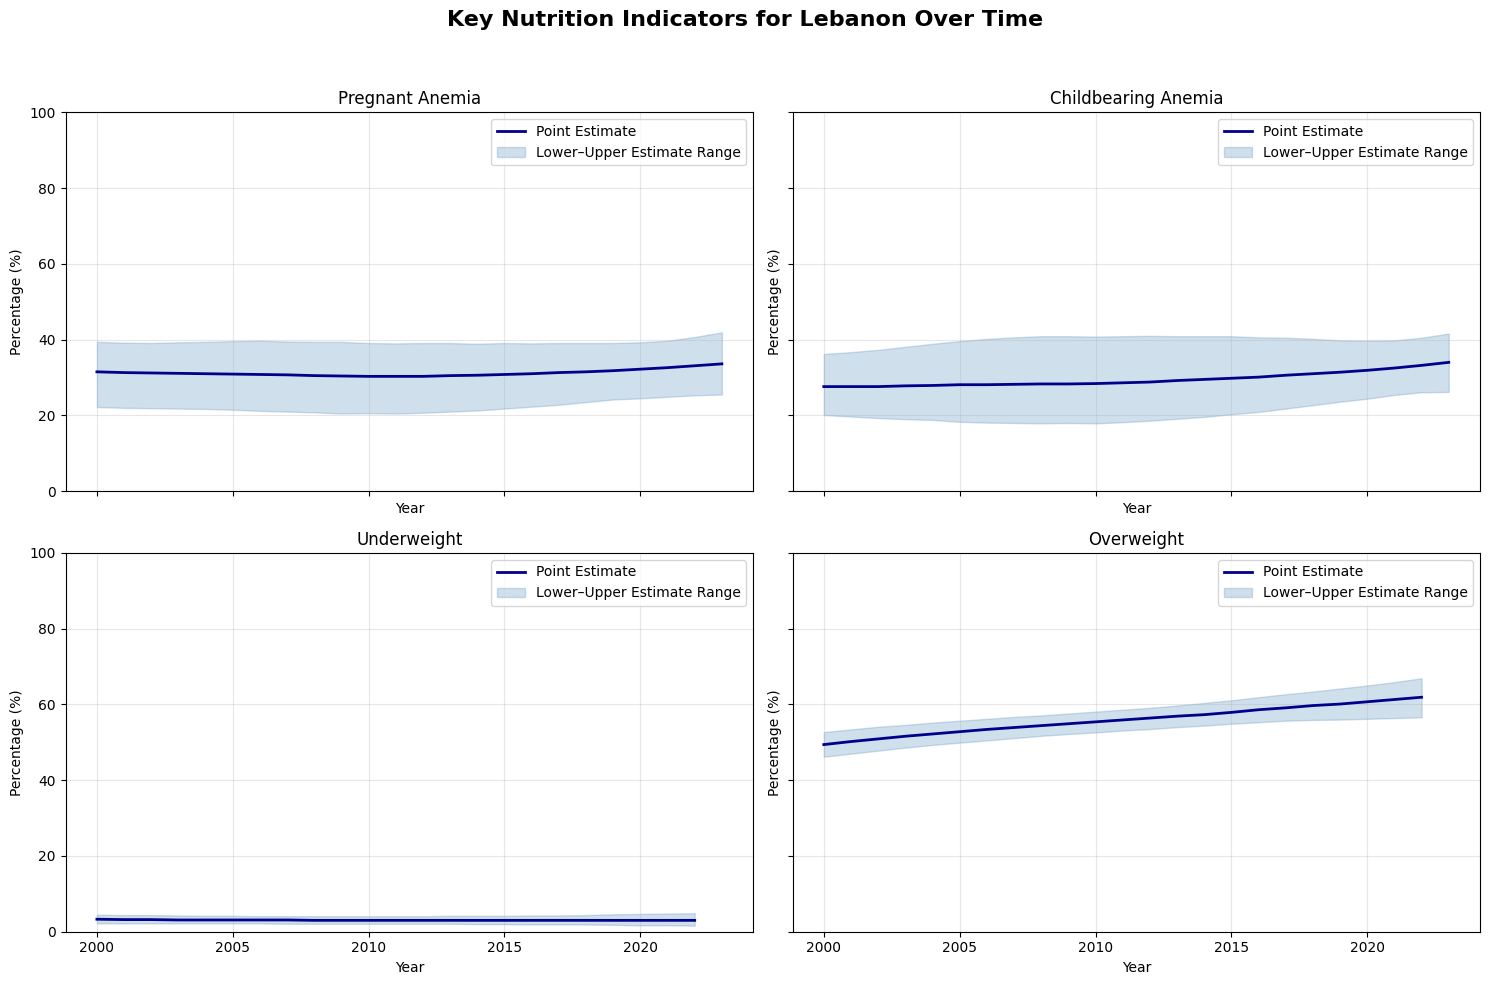

,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
95,Lebanon,33.6,34.0,3.0,61.9,2.1,6.4,-0.3,12.5,74.862543


Better Performing Similar World Bank Income Group Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
136,Philippines,24.0,12.0,10.3,37.2,-18.3,-14.5,-5.7,15.2,16.348797
75,Honduras,24.8,18.8,3.0,68.2,-3.9,-1.1,-1.8,26.2,18.384880


Better Performing Similar UN Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
35,China,14.2,15.6,5.3,34.4,-14.5,-5.0,-3.8,14.7,12.972509
140,Republic of Korea,15.9,15.7,6.2,28.8,-10.2,-1.7,0.4,3.8,14.115120


Better Performing Similar UNICEF Regions Countries


,Country,Pregnant Anemia Ending Estimate,Childbearing Anemia Ending Estimate,Underweight Ending Estimate,Overweight Ending Estimate,Pregnant Anemia Percentage Point Change,Childbearing Anemia Percentage Point Change,Underweight Percentage Point Change,Overweight Percentage Point Change,Overall Concern Score
139,Qatar,24.9,23.6,2.5,77.8,-3.9,-3.1,-0.8,14.5,20.257732
91,Kuwait,28.5,27.7,1.1,81.7,-1.0,0.1,-0.6,9.8,23.152921




Countries to Investigate
['Philippines', 'Honduras', 'China', 'Republic of Korea', 'Qatar', 'Kuwait']





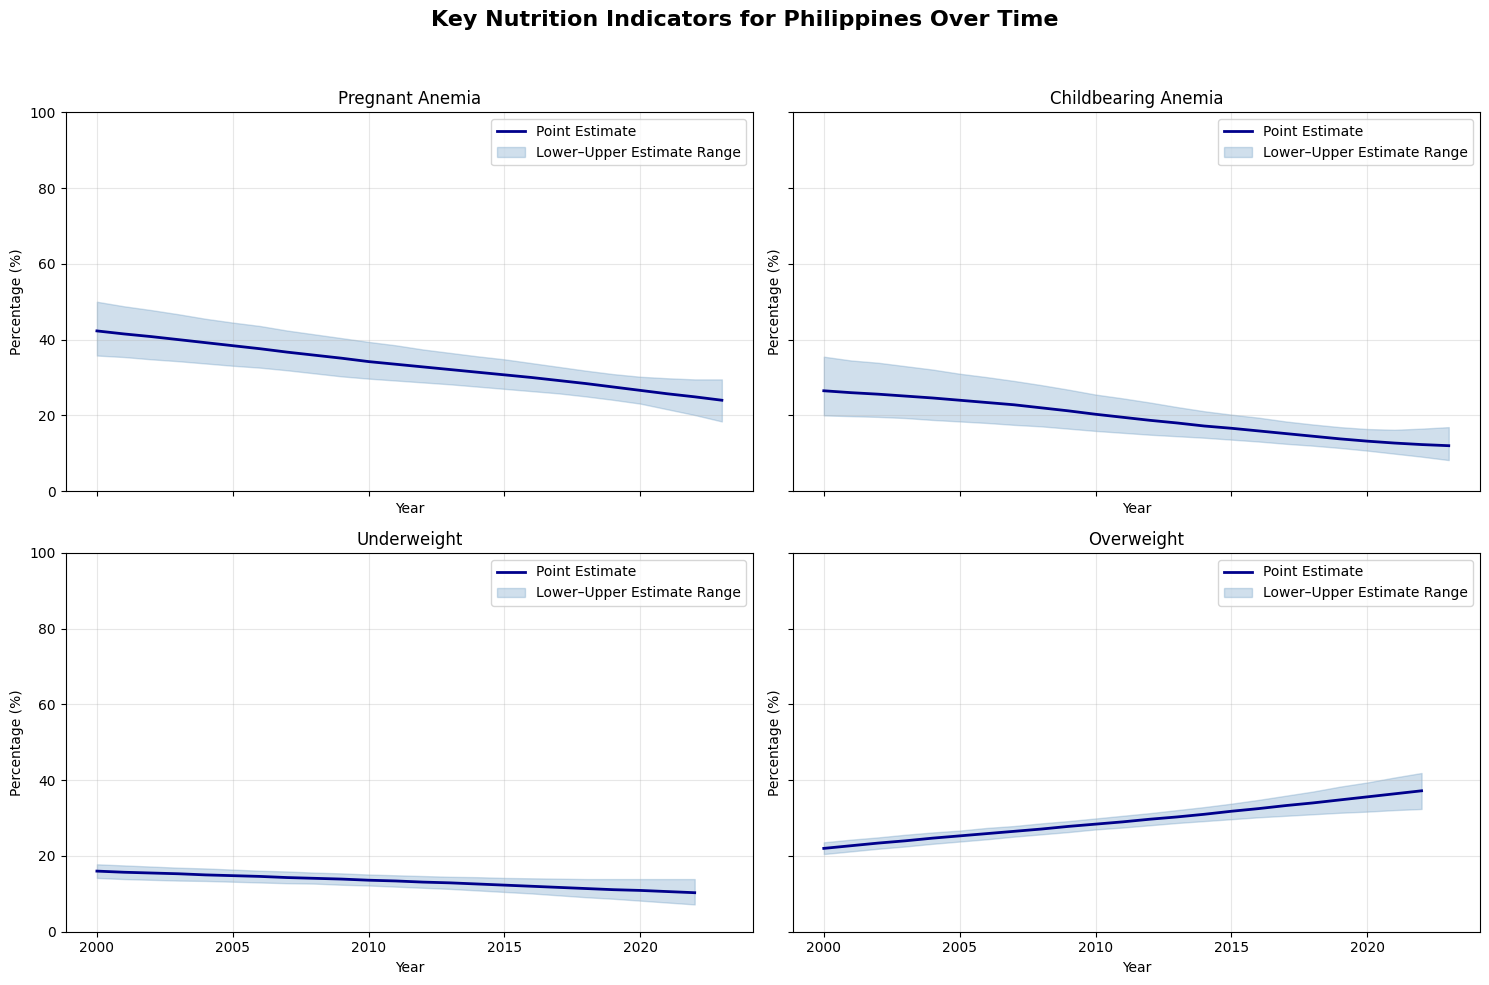

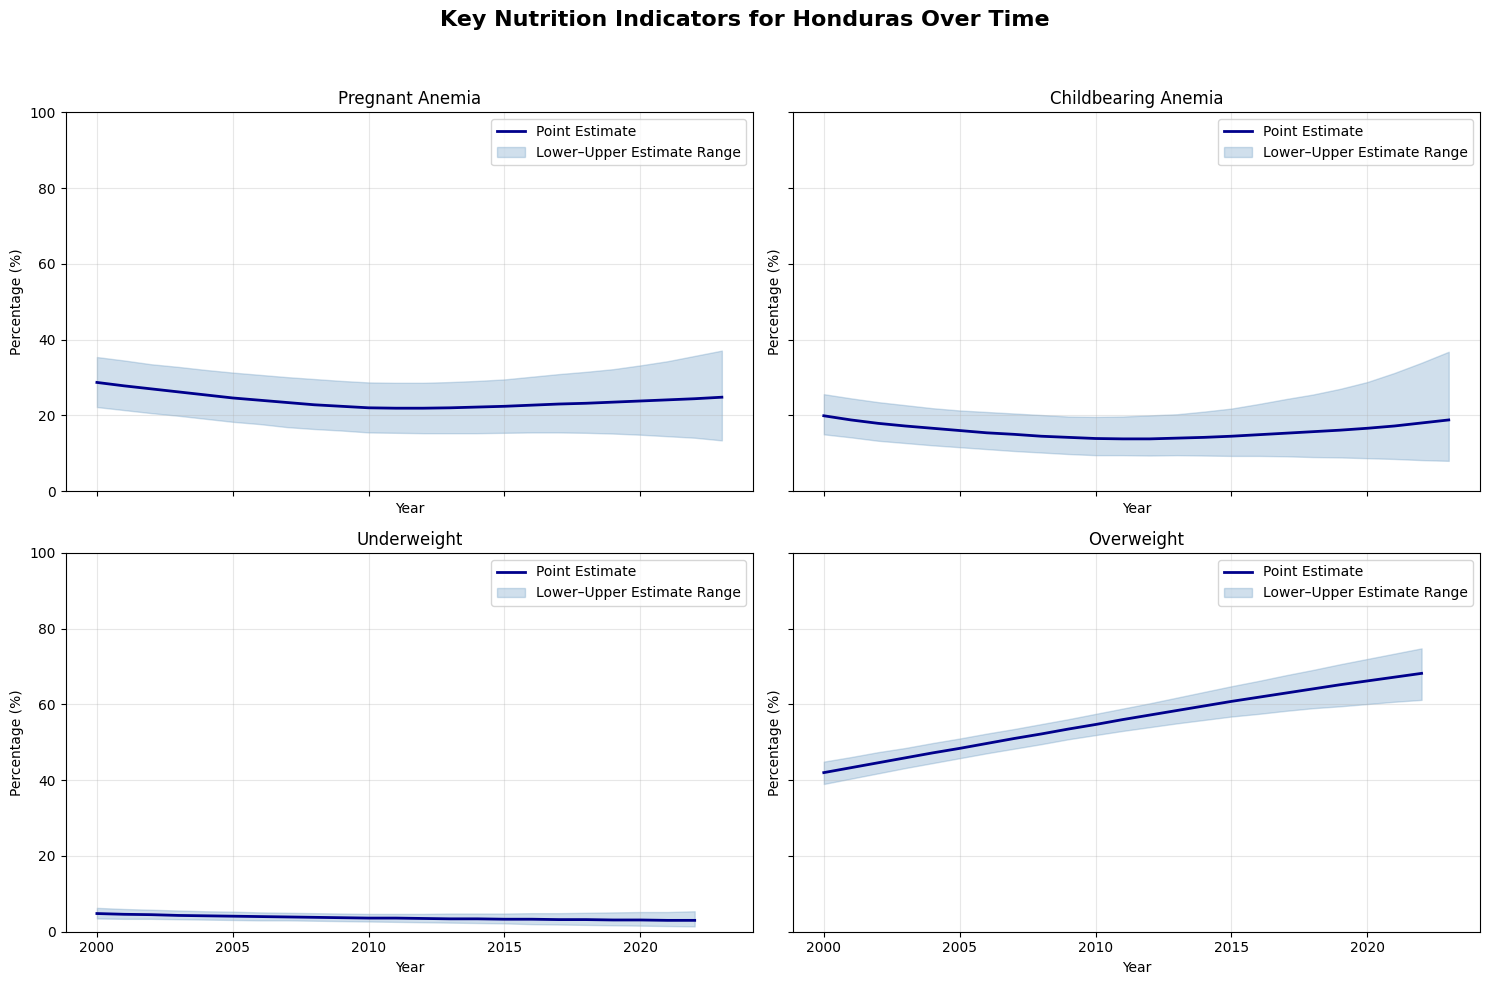

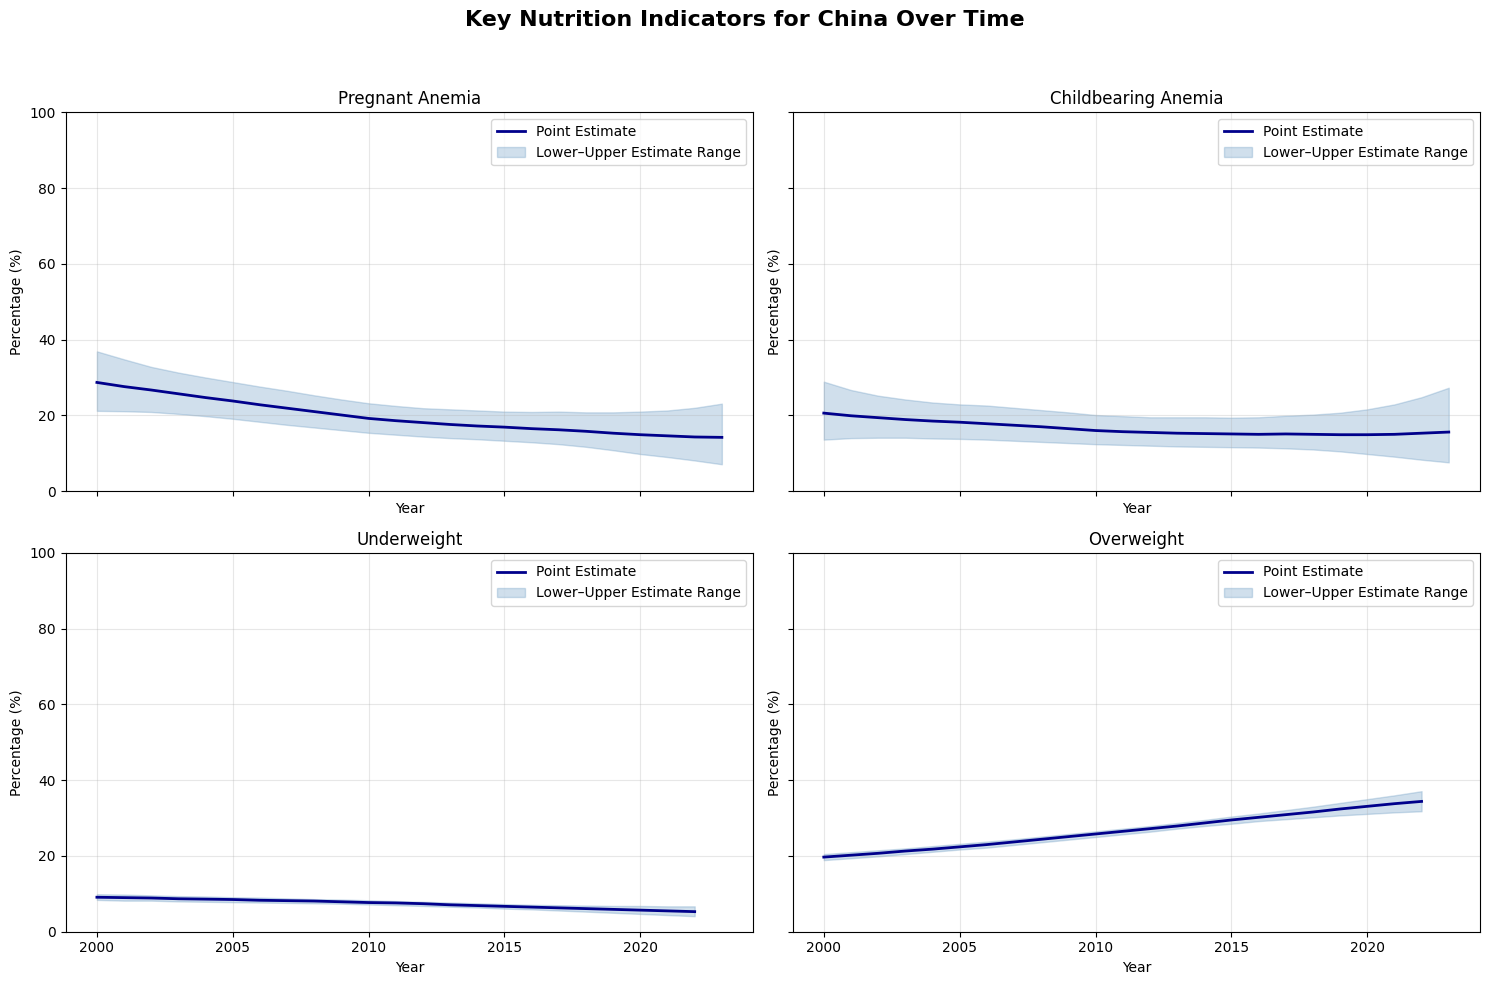

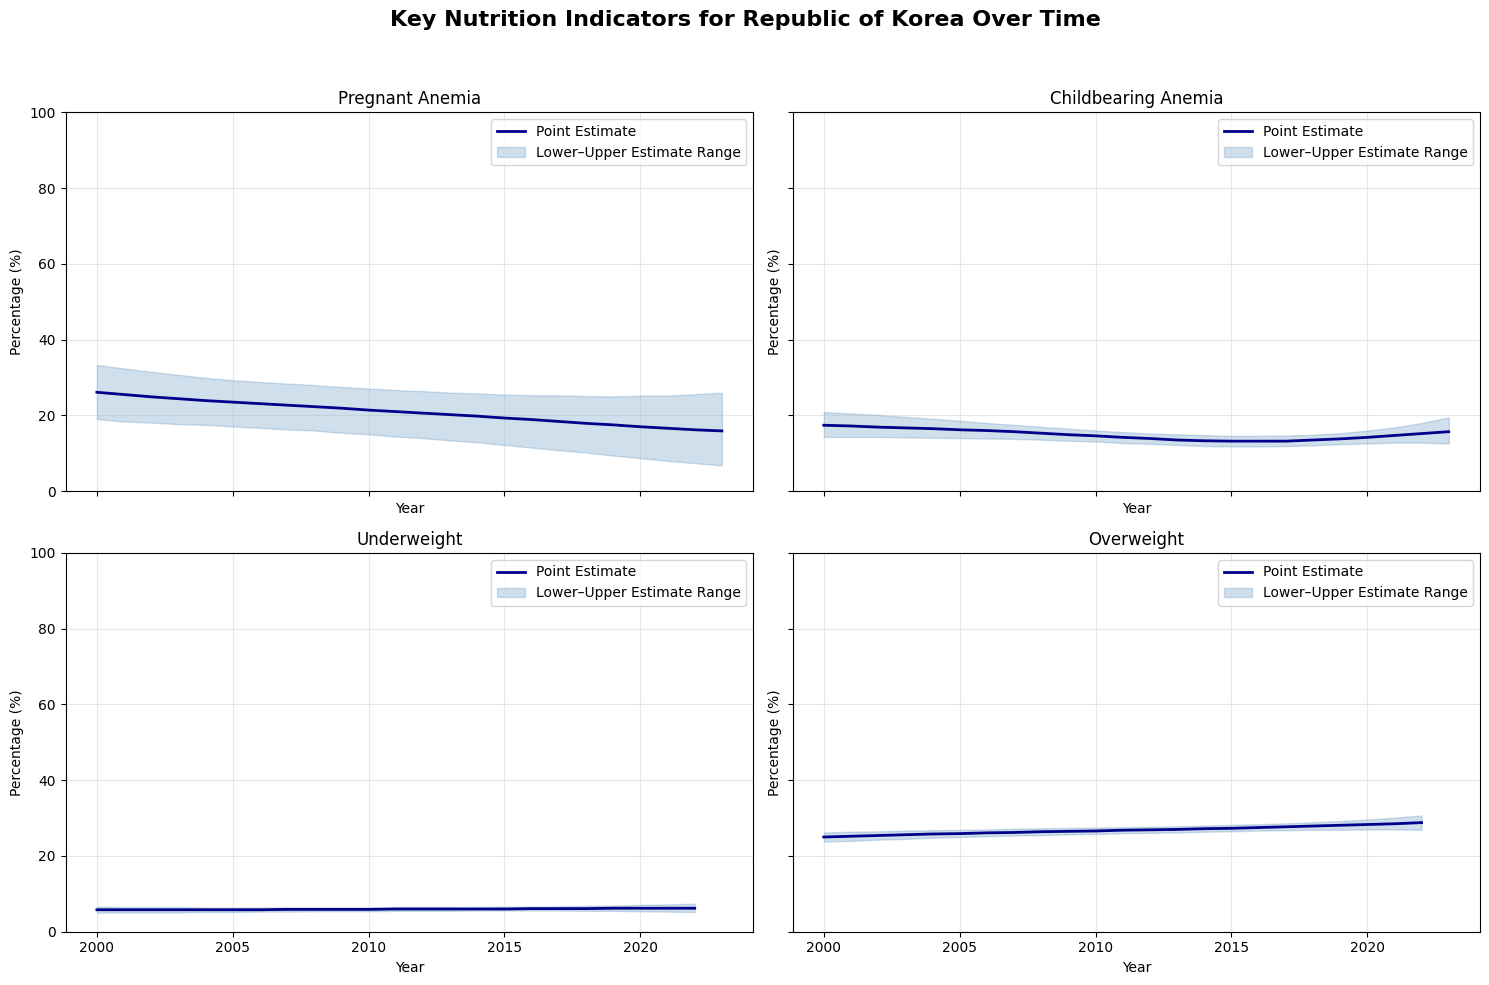

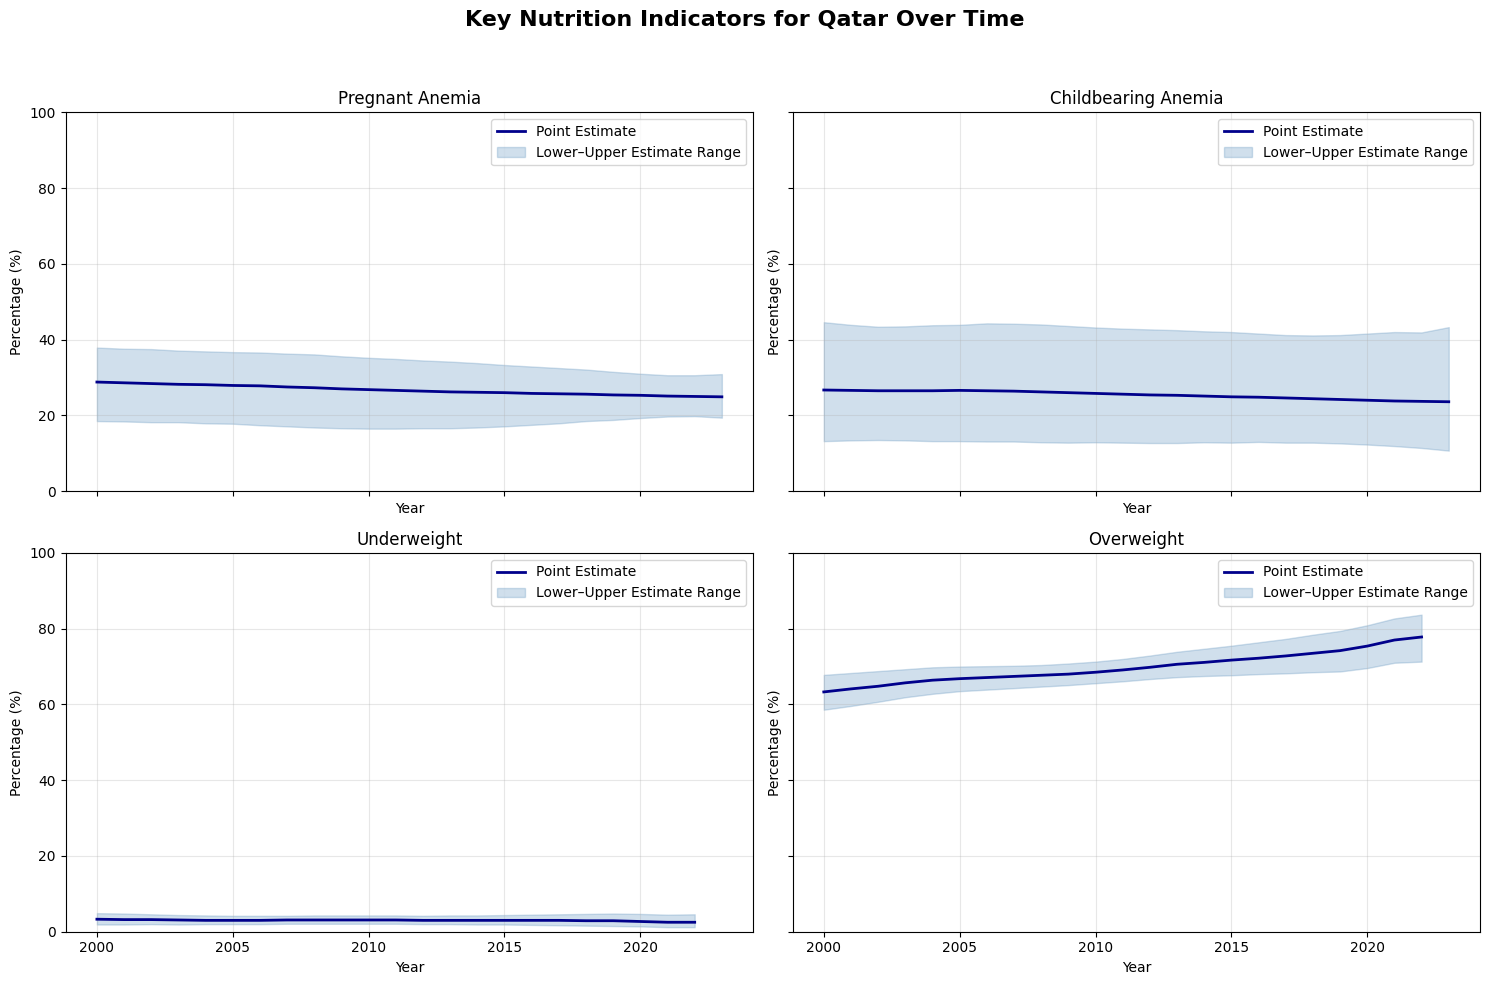

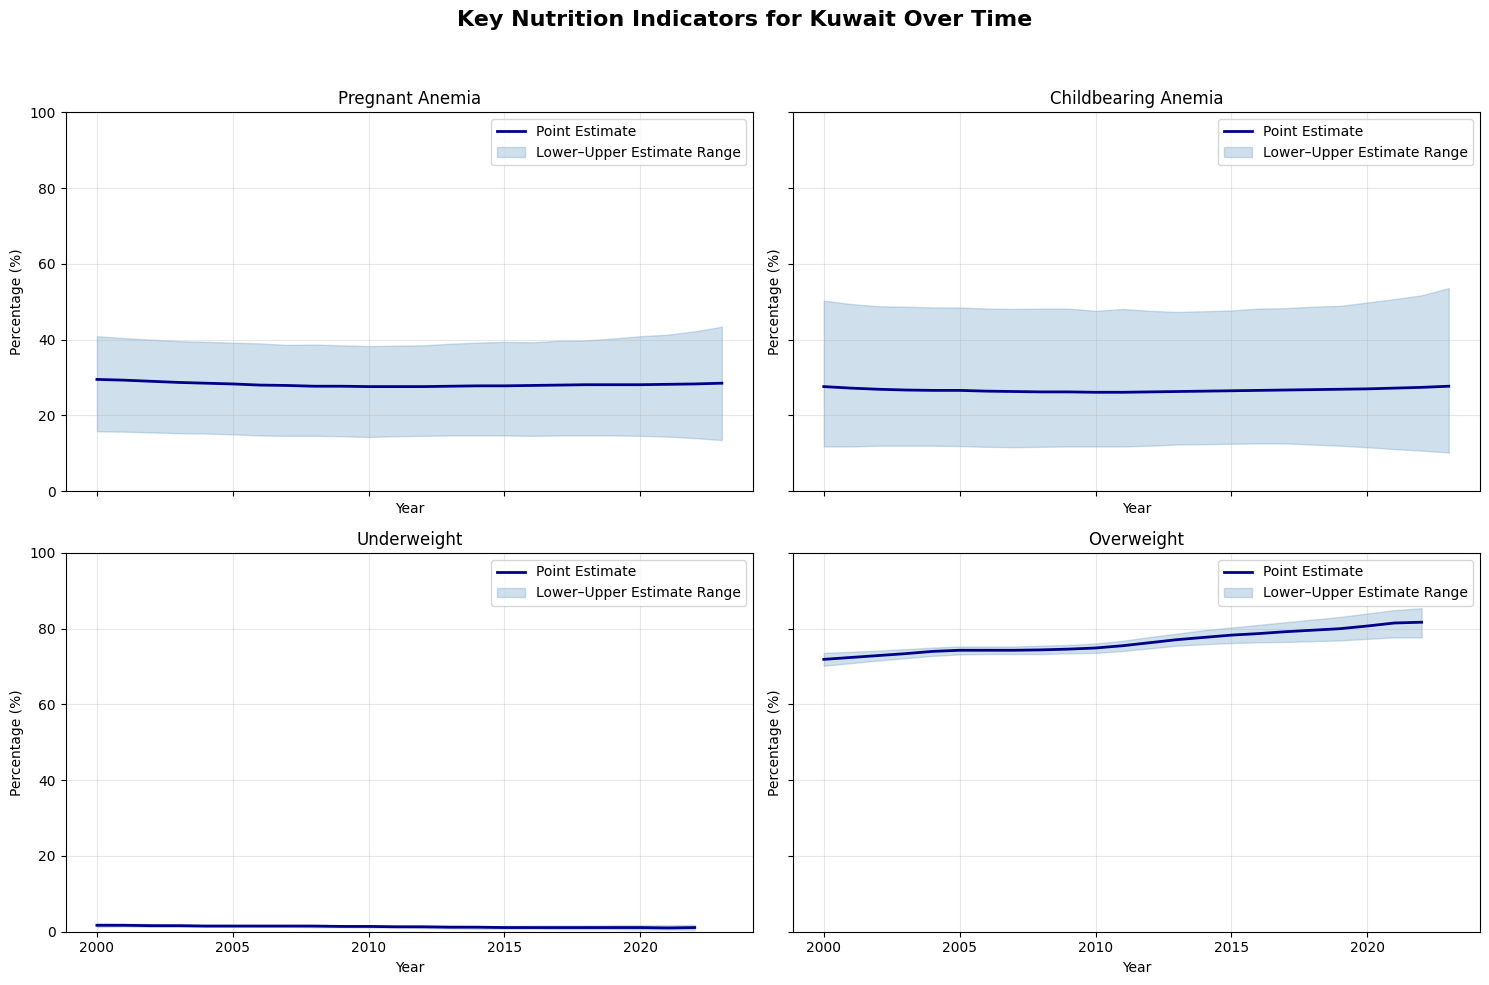

In [68]:
country_overview("Lebanon")

Most Concern Map

In [70]:
map_df = overall_concern_df.nlargest(5, "Overall Concern Score")

fig = px.choropleth(
    map_df,
    locations="Country",
    locationmode="country names",
    color="Overall Concern Score",
    hover_name="Country",
    hover_data={
        "Overall Concern Score": ":.1f",
        "Indicators Available": True
    },
    color_continuous_scale="OrRd",
    range_color=(0, 100),
    labels={
        "Overall Concern Score": "Concern Score",
        "Indicators Available": "Indicators Available"
    },
    title="Countries of Most Concern"
)

fig.update_geos(
    showframe=False,
    showcoastlines=True,
    coastlinecolor="gray",
    showland=True,
    landcolor="lightgray",
    projection_type="natural earth"
)

fig.update_layout(
    margin={"r": 20, "t": 60, "l": 20, "b": 20},
    coloraxis_colorbar={
        "title": "Concern<br>Score"
    }
)

fig.show()

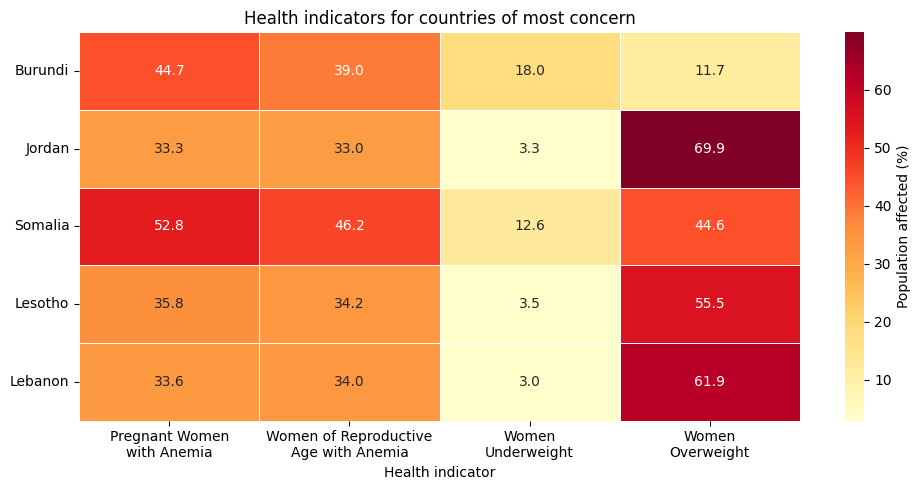

In [98]:
indicator_cols = [
    "Pregnant Anemia Ending Estimate",
    "Childbearing Anemia Ending Estimate",
    "Underweight Ending Estimate",
    "Overweight Ending Estimate"
]

plot_df = (
    map_df
    .sort_values("Overall Concern Score", ascending=False)
    .set_index("Country")[indicator_cols]
)

fig, ax =plt.subplots(figsize=(10, max(5, len(plot_df) * 0.45)))

sns.heatmap(
    plot_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Population affected (%)"},
    ax=ax
)
ax.tick_params(axis="y", labelrotation=0)

# Custom indicator labels on the x-axis
display_labels = [
    "Pregnant Women\nwith Anemia",
    "Women of Reproductive\nAge with Anemia",
    "Women\nUnderweight",
    "Women\nOverweight"
]

ax.set_xticklabels(
    display_labels,
    rotation=0,
    ha="center"
)
plt.title("Health indicators for countries of most concern")
plt.xlabel("Health indicator")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [72]:
from scipy.stats import linregress

def identify_u_shaped_regions(
    df,
    region_col="Country",
    year_col="year",
    value_col="Point Estimate",
    min_years_each_side=3,
    min_change=1.0,
    smooth_window=3
):
    # Create one observation per region and year.
    # Consider a population-weighted mean instead if one is available.
    regional = (
        df.groupby([region_col, year_col], as_index=False)[value_col]
          .mean()
          .dropna()
          .sort_values([region_col, year_col])
    )

    results = []

    for region, group in regional.groupby(region_col):
        group = group.sort_values(year_col).copy()

        # Centered rolling mean reduces sensitivity to single-year noise
        group["smoothed_value"] = (
            group[value_col]
            .rolling(
                window=smooth_window,
                center=True,
                min_periods=1
            )
            .mean()
        )

        trough_position = group["smoothed_value"].values.argmin()

        before = group.iloc[:trough_position + 1]
        after = group.iloc[trough_position:]

        # The trough must have enough observations on both sides
        if (
            len(before) < min_years_each_side or
            len(after) < min_years_each_side
        ):
            continue

        before_trend = linregress(
            before[year_col],
            before["smoothed_value"]
        )

        after_trend = linregress(
            after[year_col],
            after["smoothed_value"]
        )

        trough_value = group.iloc[trough_position]["smoothed_value"]
        decline = before.iloc[0]["smoothed_value"] - trough_value
        recovery = after.iloc[-1]["smoothed_value"] - trough_value

        is_u_shaped = (
            before_trend.slope < 0 and
            after_trend.slope > 0 and
            decline >= min_change and
            recovery >= min_change
        )

        results.append({
            region_col: region,
            "trough_year": group.iloc[trough_position][year_col],
            "trough_value": trough_value,
            "pre_trough_slope": before_trend.slope,
            "post_trough_slope": after_trend.slope,
            "decline_to_trough": decline,
            "recovery_from_trough": recovery,
            "pre_trough_p_value": before_trend.pvalue,
            "post_trough_p_value": after_trend.pvalue,
            "is_u_shaped": is_u_shaped
        })

    summary = pd.DataFrame(results)

    if summary.empty:
        return summary, regional.iloc[0:0].copy()

    u_summary = (
        summary[summary["is_u_shaped"]]
        .sort_values("recovery_from_trough", ascending=False)
        .reset_index(drop=True)
    )

    u_shaped_data = regional[
        regional[region_col].isin(u_summary[region_col])
    ].merge(
        u_summary[
            [region_col, "trough_year", "trough_value"]
        ],
        on=region_col,
        how="left"
    )

    return u_summary, u_shaped_data

In [85]:
anemia_WRA_u_sum, anemia_WRA_u_data = identify_u_shaped_regions(long_anemia_WRA_df)
print(anemia_WRA_u_sum["Country"].unique())
print("Total Countries: " + str(len(anemia_WRA_u_sum["Country"].unique())))
print(anemia_WRA_u_sum.shape)
print(anemia_WRA_u_sum["trough_year"].value_counts())
print(anemia_WRA_u_sum[anemia_WRA_u_sum["trough_year"].isin([2012,2013])]["Country"].unique())
print("U's in 2012 or 2013: " + str(len(anemia_WRA_u_sum[anemia_WRA_u_sum["trough_year"].isin([2012,2013])]["Country"].unique())))

['Burundi' 'Lesotho' 'Canada' 'Venezuela (Bolivarian Republic of)'
 'Namibia' 'Malawi' 'Bhutan' 'South Sudan' 'Madagascar' 'Honduras' 'Kenya'
 'Djibouti' 'Ethiopia' 'Albania' 'South Africa' 'Myanmar'
 'Iran (Islamic Republic of)' 'Somalia' 'Vanuatu' 'Colombia' 'Eswatini'
 'Lithuania' 'El Salvador' 'Seychelles' 'Belarus' 'Australia' 'Haiti'
 'Eritrea' 'Botswana' 'Egypt' 'Paraguay' 'Republic of Moldova' 'Comoros'
 'Saint Lucia' 'Costa Rica' 'Tuvalu' 'Papua New Guinea'
 'Trinidad and Tobago' 'Belize' 'Jamaica' 'Brunei Darussalam' 'Samoa'
 'Mali' 'Dominican Republic' 'Suriname' 'Dominica' 'Solomon Islands'
 'Peru' 'Bangladesh' 'Mexico' 'Zimbabwe' 'Cuba' 'Cook Islands' 'Uganda'
 'Saint Kitts and Nevis' 'Niger' 'Panama' 'Tonga' 'Antigua and Barbuda'
 'Liberia' 'Barbados' 'Republic of Korea' 'Grenada' 'Bahamas' 'Latvia'
 'Kiribati' 'Mauritania' 'Saint Vincent and the Grenadines' 'Ecuador'
 'Guatemala' 'Syrian Arab Republic' 'Yemen' 'Sudan'
 'United Republic of Tanzania' 'Viet Nam' 'Rwanda' 'C

What caused 20% of countries anemia rates to begin to rebound between 2012 and 2013?

In [91]:
rebounding_countries = long_anemia_WRA_df[long_anemia_WRA_df["Country"].isin(anemia_WRA_u_sum[anemia_WRA_u_sum["trough_year"].isin([2012,2013])]["Country"].unique())][["Country","UNICEF Regions", "UN Regions", "World Bank Income Groups"]].drop_duplicates(keep="first")
display(rebounding_countries['UNICEF Regions'].value_counts())
display(rebounding_countries["UN Regions"].value_counts())
display(rebounding_countries["World Bank Income Groups"].value_counts())

,count
UNICEF Regions,
LAC,22
ESA,13
EAP,3
SA,1
EECA,1


,count
UN Regions,
Latin America and the Caribbean,22
Africa,13
Asia,3
Oceania,2


,count
World Bank Income Groups,
Upper Middle Income,19
Lower Middle Income,8
High Income,6
Low Income,6
Not Classified,1


In [92]:
display(rebounding_countries[rebounding_countries["UN Regions"]== "Latin America and the Caribbean"]["World Bank Income Groups"].value_counts())

,count
World Bank Income Groups,
Upper Middle Income,15
High Income,5
Lower Middle Income,1
Not Classified,1
